# Librerías

In [40]:
!pip install optuna
!pip install shap
!pip install seaborn
!pip install geopy
!pip install tensorflow

In [41]:
# Importamos librerías a utilizar
import pandas as pd
import numpy as np
import re
import optuna
import shap
import seaborn as sns
import matplotlib.pyplot as plt
import math
import plotly.express as px
import plotly.graph_objects as go
import plotly.figure_factory as ff
import tensorflow as tf
import tensorflow.keras.backend as K
import joblib

from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.models import Sequential
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler   # u otros scalers
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc, roc_auc_score
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans
from sklearn.dummy import DummyClassifier
from scipy.stats import loguniform
from pycaret.classification import setup, compare_models, predict_model, save_model
from sklearn.model_selection import StratifiedKFold
from imblearn.combine import SMOTEENN, SMOTETomek
from pandas import DataFrame
from imblearn.over_sampling import SMOTE
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin


# Carga y visualización del dataset

El dataset se llama weatherAUS.csv y contiene información climática de Australia de los
últimos diez años, incluyendo si para el día siguiente llovió o no en la columna
‘RainTomorrow’. El objetivo del trabajo práctico es armar un ejecutable de Docker para
predecir, a las 23:59:59hs de cada día, si el día siguiente va a llover o no. Tiene alrededor de 145.460 y 23 columnas.

In [42]:
file_path= 'weatherAUS.csv'

df = pd.read_csv(file_path)

In [43]:
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

In [45]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

# 1. Clusters por región

In [46]:
ciudades = df["Location"].unique()
print(ciudades)

['Albury' 'BadgerysCreek' 'Cobar' 'CoffsHarbour' 'Moree' 'Newcastle'
 'NorahHead' 'NorfolkIsland' 'Penrith' 'Richmond' 'Sydney' 'SydneyAirport'
 'WaggaWagga' 'Williamtown' 'Wollongong' 'Canberra' 'Tuggeranong'
 'MountGinini' 'Ballarat' 'Bendigo' 'Sale' 'MelbourneAirport' 'Melbourne'
 'Mildura' 'Nhil' 'Portland' 'Watsonia' 'Dartmoor' 'Brisbane' 'Cairns'
 'GoldCoast' 'Townsville' 'Adelaide' 'MountGambier' 'Nuriootpa' 'Woomera'
 'Albany' 'Witchcliffe' 'PearceRAAF' 'PerthAirport' 'Perth' 'SalmonGums'
 'Walpole' 'Hobart' 'Launceston' 'AliceSprings' 'Darwin' 'Katherine'
 'Uluru']


Se precisa transformar algunos nombres de ciudades para poder generar los clusters correspondientes a las distintas regiones.

In [47]:
def formatear_ciudad(ciudad_sin_formato: str):
    """Función para formatear la ciudad"""
    ciudad = re.sub(r'(?<=[a-z])(?=[A-Z])', ' ', ciudad_sin_formato) + ", Australia"
    return ciudad

In [48]:
# Localizamos coordenadas para guardarlas en un diccionario en lugar de acceder online en cada ejecución
#geolocator = Nominatim(user_agent="weatherAUS") # Instanciamos el geolocalizador
#geocode = RateLimiter(geolocator.geocode, min_delay_seconds=1, max_retries=3, error_wait_seconds=2.0)
#coord = []
#for c in ciudades:
#    c_form = formatear_ciudad(c)
#    try:
#        localizacion = geocode(c_form, timeout=10)
#        if localizacion:
#            coord.append((c, localizacion.latitude, localizacion.longitude))
#        else:
#            print(f"No se encontró {c}")
#    except Exception as e:
#        print(f"Error con: {c} - {e}")

#df_coord = pd.DataFrame(coord, columns=["Location","Latitude","Longitude"])
# coordenadas_dict = df_coord.set_index('Location')[['Latitude', 'Longitude']].to_dict('index')
#print(coordenadas_dict)

In [49]:
# diccionario
coordenadas_dict = {'Albury': {'Latitude': -36.0737734, 'Longitude': 146.9135265}, 'BadgerysCreek': {'Latitude': -33.8831452, 'Longitude': 150.742466}, 'Cobar': {'Latitude': -31.9666628, 'Longitude': 145.3045054}, 'CoffsHarbour': {'Latitude': -30.2985996, 'Longitude': 153.1094116}, 'Moree': {'Latitude': -29.4617202, 'Longitude': 149.8407153}, 'Newcastle': {'Latitude': -32.9192953, 'Longitude': 151.7795348}, 'NorahHead': {'Latitude': -33.2816667, 'Longitude': 151.5677778}, 'NorfolkIsland': {'Latitude': -29.0328038, 'Longitude': 167.9483137}, 'Penrith': {'Latitude': -33.7511954, 'Longitude': 150.6941711}, 'Richmond': {'Latitude': -37.80745, 'Longitude': 144.9907213}, 'Sydney': {'Latitude': -33.8698439, 'Longitude': 151.2082848}, 'SydneyAirport': {'Latitude': -33.9498935, 'Longitude': 151.1819682}, 'WaggaWagga': {'Latitude': -35.115, 'Longitude': 147.3677778}, 'Williamtown': {'Latitude': -32.815, 'Longitude': 151.8427778}, 'Wollongong': {'Latitude': -34.4243941, 'Longitude': 150.89385}, 'Canberra': {'Latitude': -35.2975906, 'Longitude': 149.1012676}, 'Tuggeranong': {'Latitude': -35.4209771, 'Longitude': 149.0921341}, 'MountGinini': {'Latitude': -35.5297437, 'Longitude': 148.7725396}, 'Ballarat': {'Latitude': -37.5623013, 'Longitude': 143.8605645}, 'Bendigo': {'Latitude': -36.7590183, 'Longitude': 144.2826718}, 'Sale': {'Latitude': -38.1094463, 'Longitude': 147.0656717}, 'MelbourneAirport': {'Latitude': -37.6667554, 'Longitude': 144.8288501}, 'Melbourne': {'Latitude': -37.8142454, 'Longitude': 144.9631732}, 'Mildura': {'Latitude': -34.195274, 'Longitude': 142.1503146}, 'Nhil': {'Latitude': -35.4325403, 'Longitude': 141.2833862}, 'Portland': {'Latitude': -38.3456231, 'Longitude': 141.6042304}, 'Watsonia': {'Latitude': -37.7109468, 'Longitude': 145.0837808}, 'Dartmoor': {'Latitude': -37.895212, 'Longitude': 141.2679429}, 'Brisbane': {'Latitude': -27.4689623, 'Longitude': 153.0235009}, 'Cairns': {'Latitude': -16.9206657, 'Longitude': 145.7721854}, 'GoldCoast': {'Latitude': -28.0023731, 'Longitude': 153.4145987}, 'Townsville': {'Latitude': -19.2569391, 'Longitude': 146.8239537}, 'Adelaide': {'Latitude': -34.9281805, 'Longitude': 138.5999312}, 'MountGambier': {'Latitude': -37.8301386, 'Longitude': 140.7842627}, 'Nuriootpa': {'Latitude': -34.4693354, 'Longitude': 138.9939006}, 'Woomera': {'Latitude': -31.1999142, 'Longitude': 136.8253532}, 'Albany': {'Latitude': -35.0247822, 'Longitude': 117.883608}, 'Witchcliffe': {'Latitude': -34.0263348, 'Longitude': 115.1004768}, 'PearceRAAF': {'Latitude': -31.6739604, 'Longitude': 116.0175435}, 'PerthAirport': {'Latitude': -31.9415213, 'Longitude': 115.9655769}, 'Perth': {'Latitude': -31.9558967, 'Longitude': 115.8605784}, 'SalmonGums': {'Latitude': -32.9815167, 'Longitude': 121.6440785}, 'Walpole': {'Latitude': -34.9776796, 'Longitude': 116.7310063}, 'Hobart': {'Latitude': -42.8825088, 'Longitude': 147.3281233}, 'Launceston': {'Latitude': -41.4340813, 'Longitude': 147.1373496}, 'AliceSprings': {'Latitude': -23.6983884, 'Longitude': 133.8812885}, 'Darwin': {'Latitude': -12.46044, 'Longitude': 130.8410469}, 'Katherine': {'Latitude': -14.4646157, 'Longitude': 132.2635993}, 'Uluru': {'Latitude': -25.3455545, 'Longitude': 131.0369615}}

In [50]:
# DataFrame del diccionario estático
datos_coordenadas = []
for location, coords in coordenadas_dict.items():
    datos_coordenadas.append({
        'Location': location,
        'Latitude': coords['Latitude'],
        'Longitude': coords['Longitude']
    })

df_coord = pd.DataFrame(datos_coordenadas)
df_coord

,Location,Latitude,Longitude
0,Albury,-36.073773,146.913526
1,BadgerysCreek,-33.883145,150.742466
2,Cobar,-31.966663,145.304505
3,CoffsHarbour,-30.298600,153.109412
4,Moree,-29.461720,149.840715
5,Newcastle,-32.919295,151.779535
6,NorahHead,-33.281667,151.567778
7,NorfolkIsland,-29.032804,167.948314
8,Penrith,-33.751195,150.694171
9,Richmond,-37.807450,144.990721


## Método del codo

Para agrupar las ciudades en regiones se utilizará el algoritmo K-means, donde se usará el método del codo para calcular un valor adecuado de k.

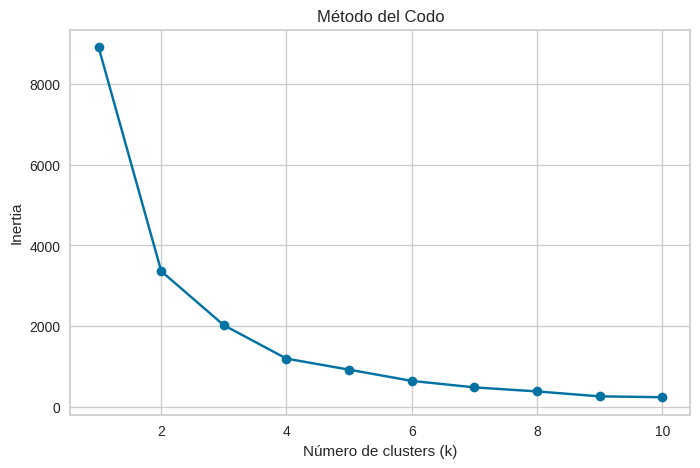

In [51]:
matriz_de_coordenadas = df_coord[['Latitude',  'Longitude']].values

inertias = []
K = range(1,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=0)
    kmeans.fit(matriz_de_coordenadas)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertias, 'bo-')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inertia')
plt.title('Método del Codo')
plt.grid(True)
plt.show()

Del gráfico del método del codo se puede observar cómo a partir de 4 segmentos, la mejora que se produce en la
distancia interna de los segmentos ya es insignificante. Este hecho debería ser
indicativo de que 4 segmentos es un valor adecuado para k. Sin embargo, dado que este método puede ser ambiguo o poco fiable, se decidió buscar una validación adicional probando distintos valores para k.

## Implementación de K-means

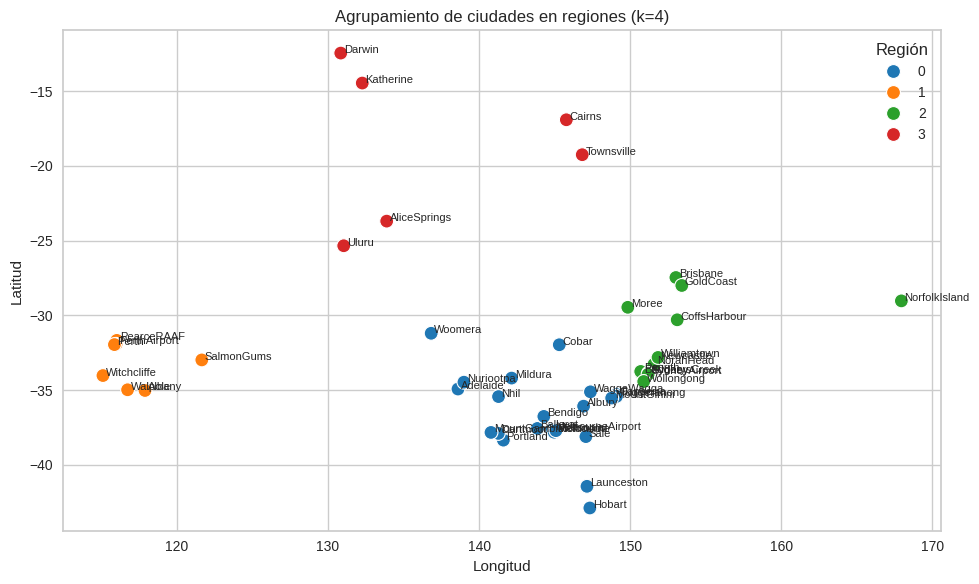

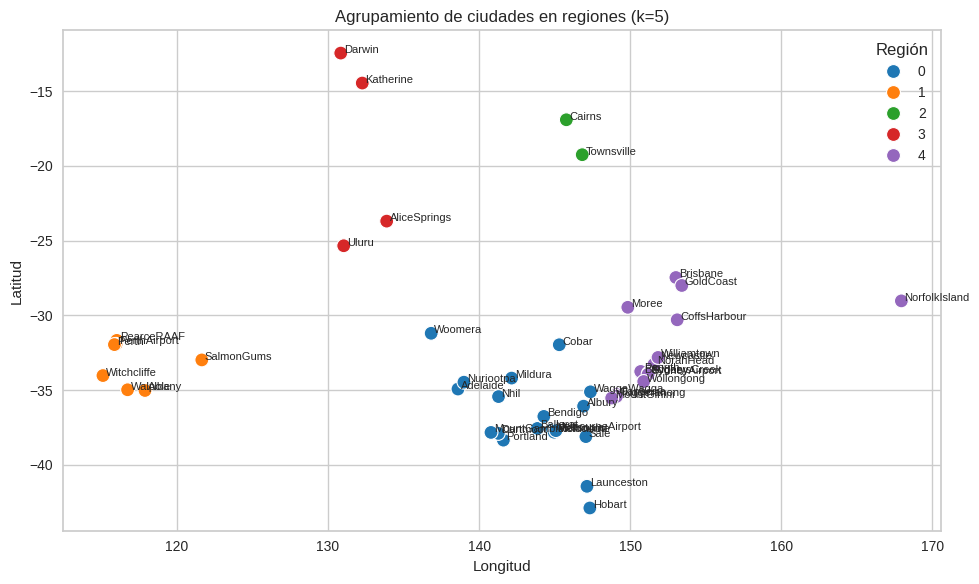

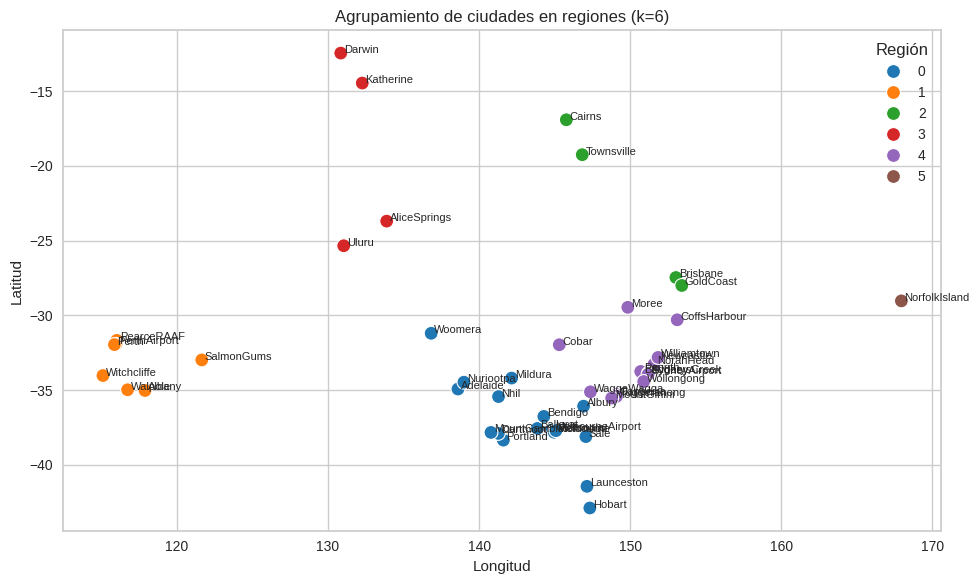

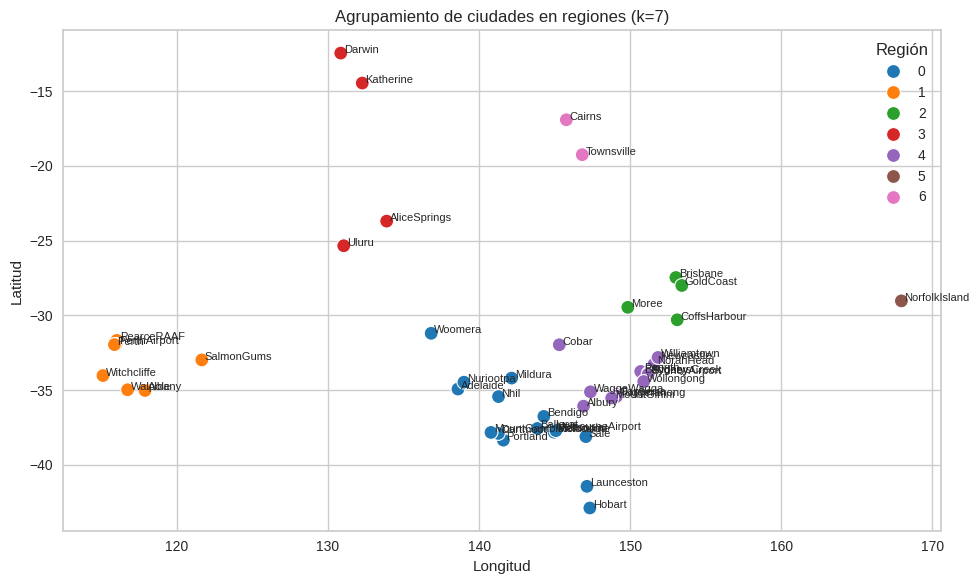

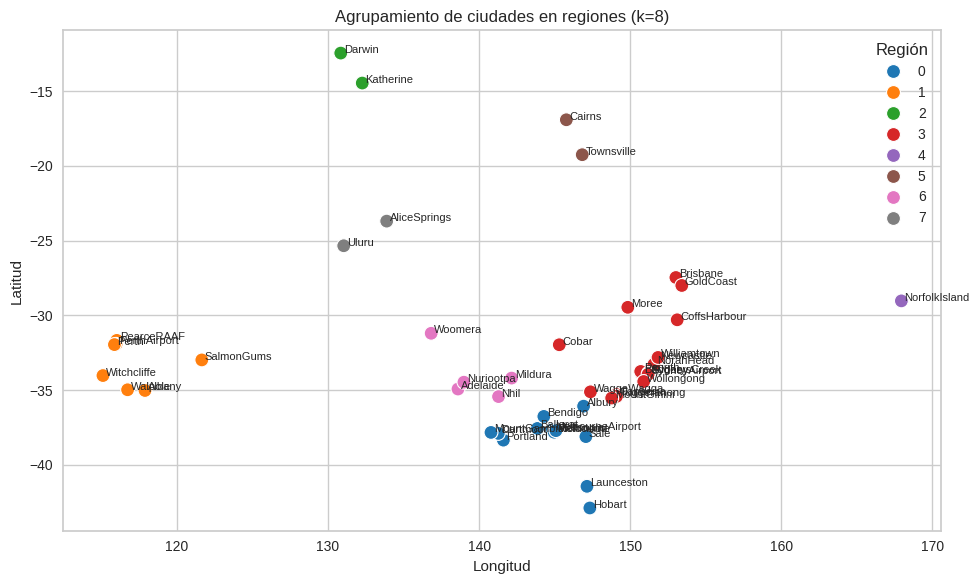

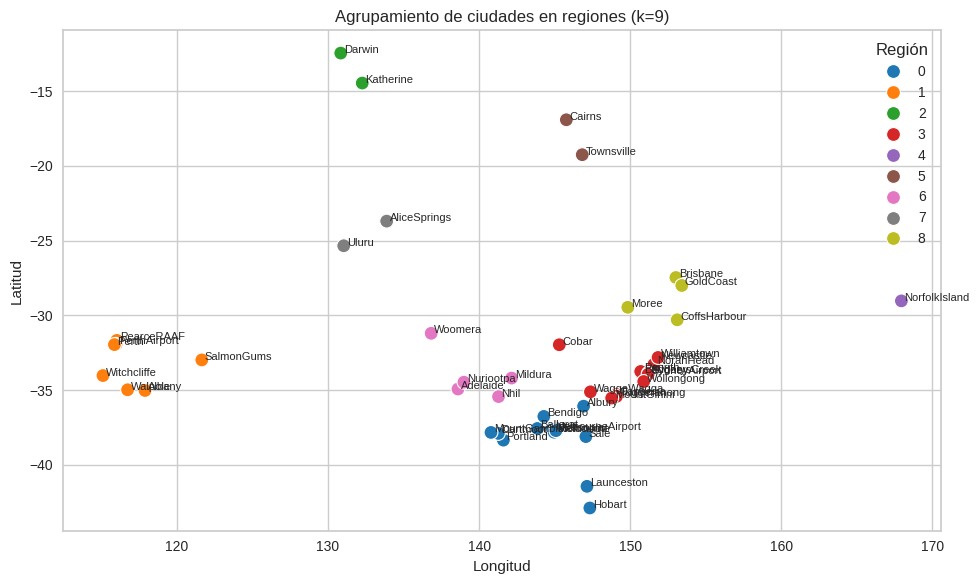

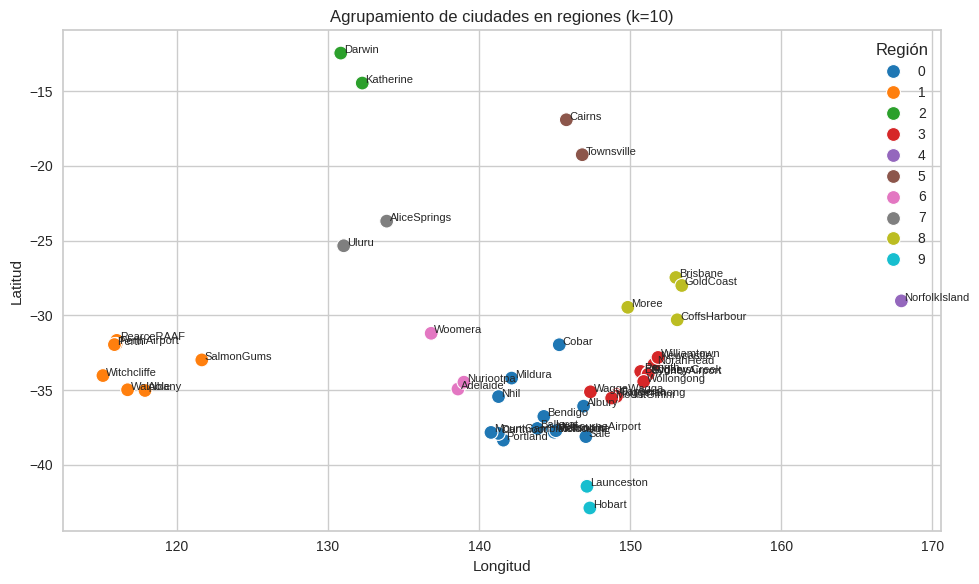

In [52]:
k_prob = [4, 5, 6, 7, 8, 9, 10]

df_coords_by_k = {}

for k in k_prob:
    df_coord_k = df_coord.copy()

    kmeans = KMeans(n_clusters=k, random_state=42)
    df_coord_k['Region'] = kmeans.fit_predict(df_coord_k[['Latitude', 'Longitude']].values)

    df_coords_by_k[k] = df_coord_k

    # plot
    plt.figure(figsize=(10, 6))
    sns.scatterplot(
        data=df_coord_k,
        x='Longitude', y='Latitude',
        hue='Region',
        palette='tab10',
        s=100
    )

    for _, row in df_coord_k.iterrows():
        plt.text(row['Longitude'] + 0.2, row['Latitude'], row['Location'], fontsize=8)

    plt.title(f'Agrupamiento de ciudades en regiones (k={k})')
    plt.xlabel('Longitud')
    plt.ylabel('Latitud')
    plt.legend(title='Región')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

Se procedió a realizar una inspección visual de las agrupaciones de ciudades en un gráfico de latitud y longitud, probando diferentes valores de k. Se buscó el valor de k que mejor alineara los clusters con las regiones geográficas y climáticas conocidas de Australia (https://www.researchgate.net/figure/Major-seasonal-rainfall-zones-of-Australia-source-Bureau-of-Meteorology-National_fig3_228535345). Se decidió elegir k=8.

In [53]:
df_coords_by_k[8]

,Location,Latitude,Longitude,Region
0,Albury,-36.073773,146.913526,0
1,BadgerysCreek,-33.883145,150.742466,3
2,Cobar,-31.966663,145.304505,3
3,CoffsHarbour,-30.298600,153.109412,3
4,Moree,-29.461720,149.840715,3
5,Newcastle,-32.919295,151.779535,3
6,NorahHead,-33.281667,151.567778,3
7,NorfolkIsland,-29.032804,167.948314,4
8,Penrith,-33.751195,150.694171,3
9,Richmond,-37.807450,144.990721,0


# 2. Análisis descriptivo de datos

## Datos faltantes

In [54]:
def check_nan_percentage(df):
    nan_cant = df.isna().sum()
    nan_porcentaje = (nan_cant / len(df)) * 100

    nan_info = pd.DataFrame({
        'Cantidad': nan_cant,
        'Porcentaje': nan_porcentaje
    })

    nan_info['Porcentaje'] = nan_info['Porcentaje'].apply(lambda x: f"{x:.2f}%")

    print(nan_info)

check_nan_percentage(df)

               Cantidad Porcentaje
Date                  0      0.00%
Location              0      0.00%
MinTemp            1485      1.02%
MaxTemp            1261      0.87%
Rainfall           3261      2.24%
Evaporation       62790     43.17%
Sunshine          69835     48.01%
WindGustDir       10326      7.10%
WindGustSpeed     10263      7.06%
WindDir9am        10566      7.26%
WindDir3pm         4228      2.91%
WindSpeed9am       1767      1.21%
WindSpeed3pm       3062      2.11%
Humidity9am        2654      1.82%
Humidity3pm        4507      3.10%
Pressure9am       15065     10.36%
Pressure3pm       15028     10.33%
Cloud9am          55888     38.42%
Cloud3pm          59358     40.81%
Temp9am            1767      1.21%
Temp3pm            3609      2.48%
RainToday          3261      2.24%
RainTomorrow       3267      2.25%


In [55]:
df = df.merge(df_coords_by_k[8][['Location', 'Region']], on="Location", how="left")
df = df.drop(columns=['Location'])

In [56]:
df['Date'] = pd.to_datetime(df['Date'])

def estacion(date):
    mes = date.month
    if mes in [12, 1, 2]:
        return 'Verano'
    elif mes in [3, 4, 5]:
        return 'Otoño'
    elif mes in [6, 7, 8]:
        return 'Invierno'
    else:
        return 'Primavera'

df['Season'] = df['Date'].apply(estacion)
df = df.drop(columns=['Date'])

Se eliminan valores nulos de la variable objetivo en el dataset.

In [57]:
df = df[df["RainTomorrow"].notna()]

Se eliminan las filas con más de la mitad de datos nulos.

In [58]:
df = df.dropna(thresh=df.shape[1] - (df.shape[1] // 2 + 1))

In [59]:
check_nan_percentage(df)

               Cantidad Porcentaje
MinTemp             373      0.26%
MaxTemp             221      0.16%
Rainfall           1281      0.90%
Evaporation       60515     42.67%
Sunshine          67479     47.58%
WindGustDir        9041      6.37%
WindGustSpeed      8981      6.33%
WindDir9am         9666      6.82%
WindDir3pm         3464      2.44%
WindSpeed9am       1051      0.74%
WindSpeed3pm       2325      1.64%
Humidity9am        1481      1.04%
Humidity3pm        3310      2.33%
Pressure9am       13689      9.65%
Pressure3pm       13662      9.63%
Cloud9am          53360     37.62%
Cloud3pm          56754     40.01%
Temp9am             617      0.44%
Temp3pm            2429      1.71%
RainToday          1281      0.90%
RainTomorrow          0      0.00%
Region                0      0.00%
Season                0      0.00%


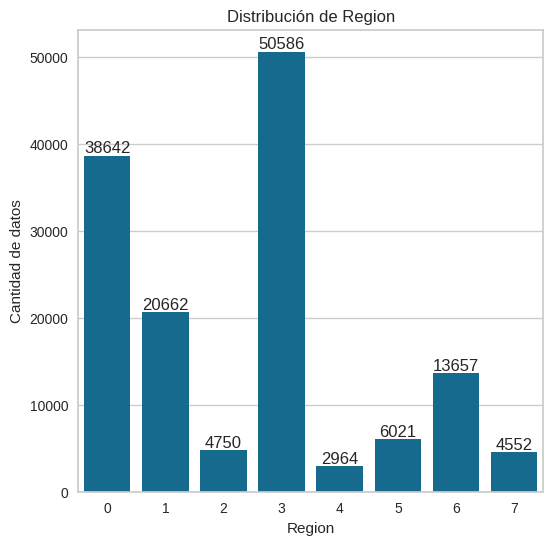

In [60]:
# Distribución de la variable Region
plt.figure(figsize=(6, 6))
ax = sns.countplot(x=df['Region'])

for container in ax.containers:
    ax.bar_label(container)

plt.title('Distribución de Region')
plt.xlabel('Region')
plt.ylabel('Cantidad de datos')
plt.show()

El gráfico revela una distribución desbalanceada de 'Region'. Las regiones 3 y 0 son las dominantes, concentrando la mayor cantidad de datos. En contraste, las regiones 2, 4 y 7 tienen una representación muy baja. Este desbalance refleja una distribución no uniforme de las observaciones climáticas en Australia, lo cual será considerado en las etapas de entrenamiento para evitar que el modelo tenga un bajo rendimiento o sesgo en la predicción de lluvia en las regiones menos representadas.

## Boxplots de cada variable

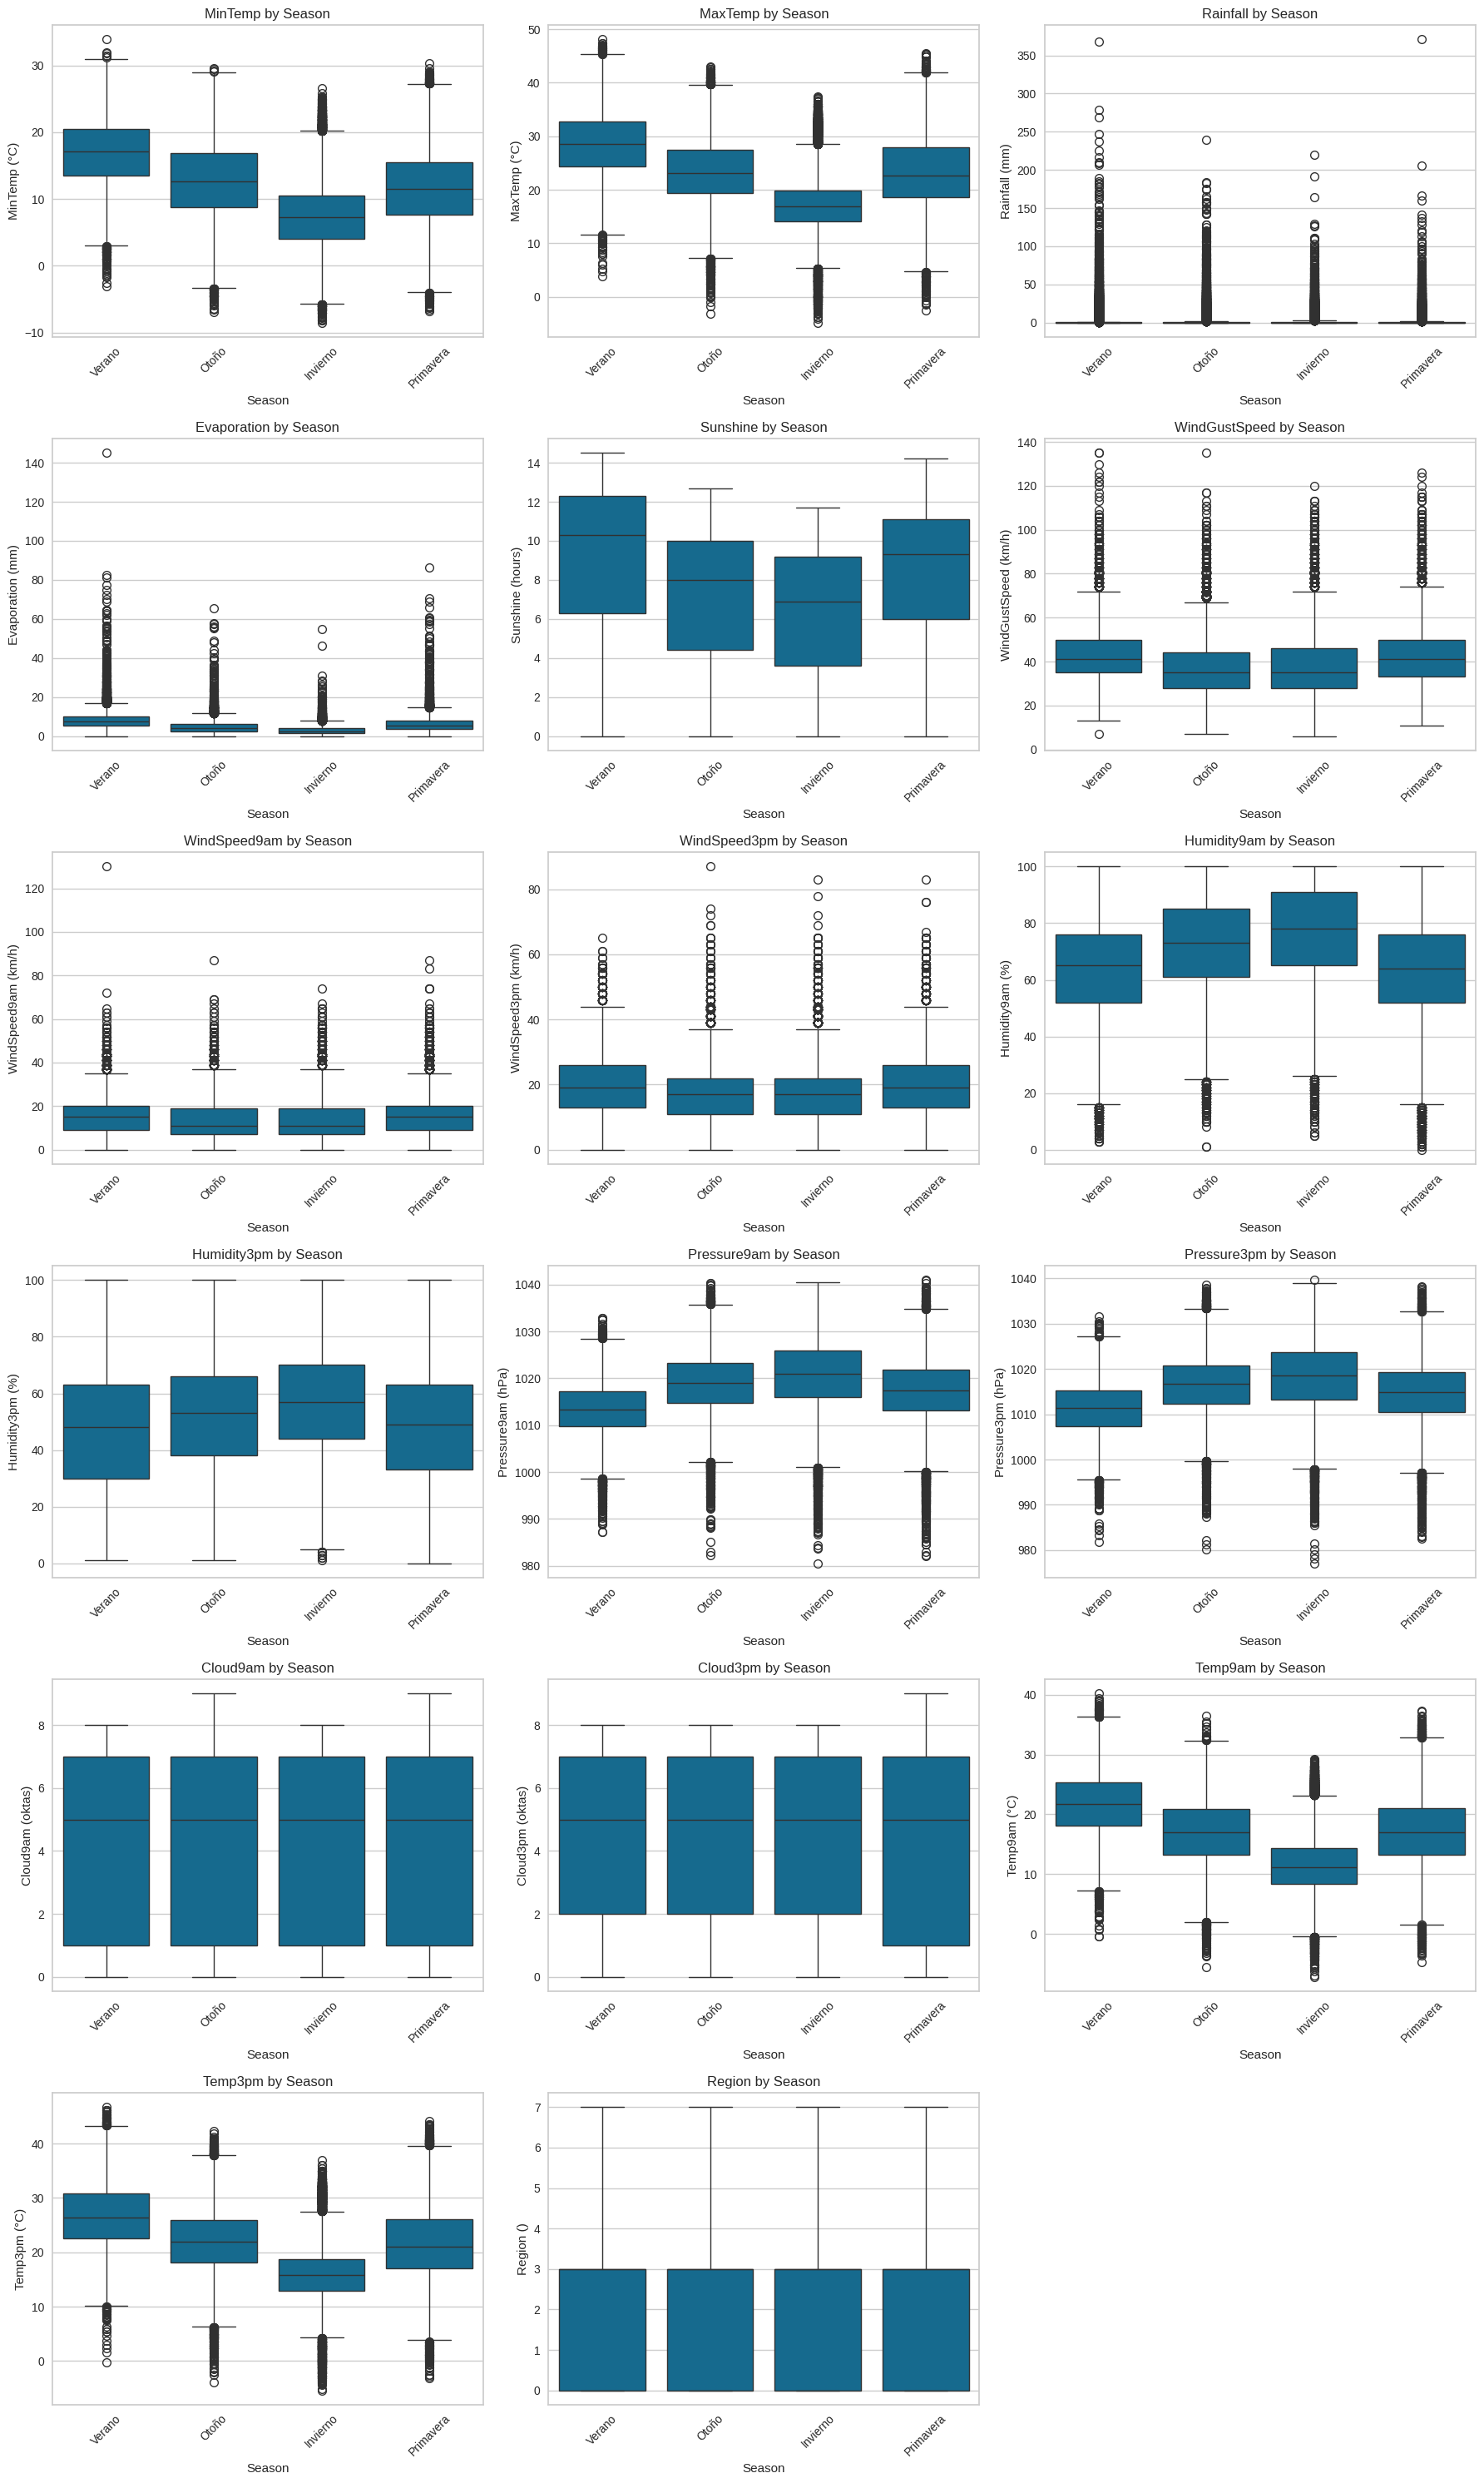

In [61]:
# Se seleccionan las columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Se agregan las unidades correspondientes
units = {
    'MinTemp': '°C',
    'MaxTemp': '°C',
    'Rainfall': 'mm',
    'Evaporation': 'mm',
    'Sunshine': 'hours',
    'WindGustSpeed': 'km/h',
    'WindSpeed9am': 'km/h',
    'WindSpeed3pm': 'km/h',
    'Humidity9am': '%',
    'Humidity3pm': '%',
    'Pressure9am': 'hPa',
    'Pressure3pm': 'hPa',
    'Cloud9am': 'oktas',
    'Cloud3pm': 'oktas',
    'Temp9am': '°C',
    'Temp3pm': '°C'
}

# Número de subplots y columnas
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / 3)

# Subplots
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Boxplot para cada columna numérica
for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, x='Season', y=col, ax=axes[i])
    axes[i].set_title(f'{col} by Season')
    axes[i].set_xlabel('Season')
    axes[i].set_ylabel(f'{col} ({units.get(col, "")})')
    axes[i].tick_params(axis='x', rotation=45)

# Ocultar subplots no utilizados
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

A partir de la observación de los boxplots para cada variable y luego de investigar sobre su rango de variación y si los outliers mostrados son valores posibles en Australia, se considerarán todos los valores como posibles.

## Matriz de correlación general y por estación


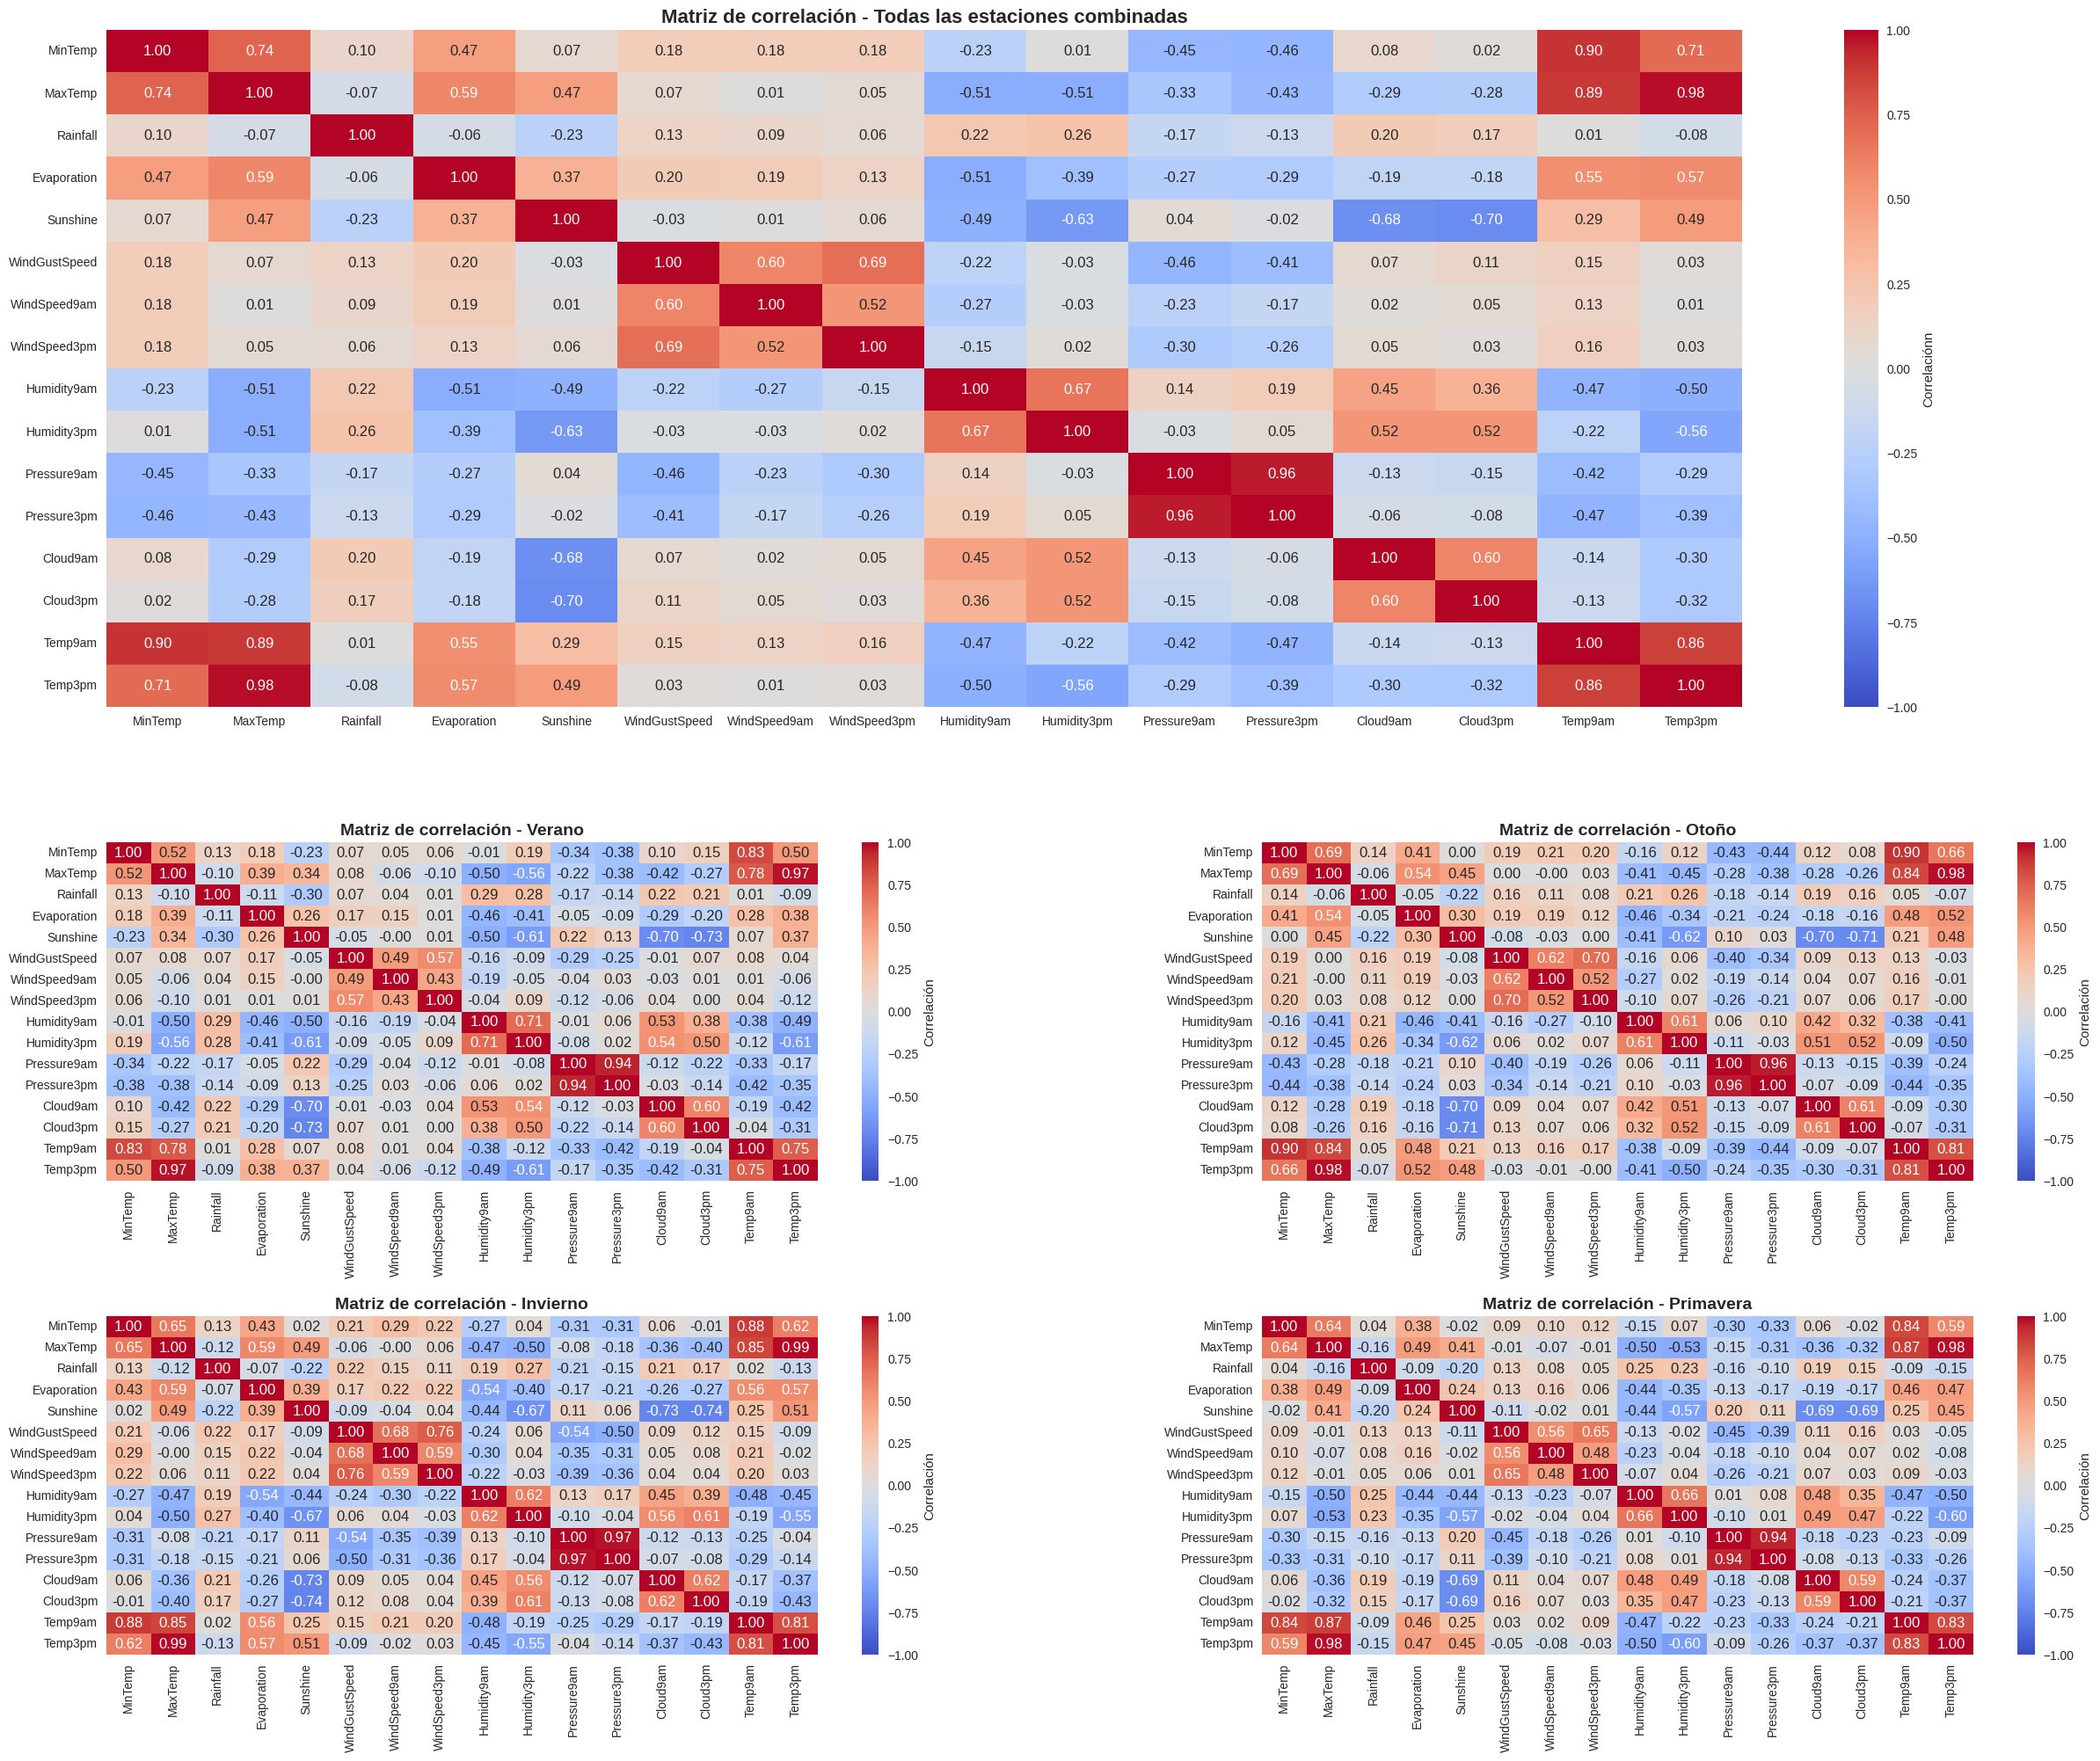

In [62]:
# Obtener columnas numéricas menos región
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'Region' in numeric_cols:
    numeric_cols.remove('Region')

# Obtener estaciones únicas
seasons = df['Season'].unique()

# Crear GridSpec para custom layout
fig = plt.figure(figsize=(30, 24))
gs = fig.add_gridspec(3, 2, height_ratios=[2, 1, 1], hspace=0.3, wspace=0.3)

# Crear matrices de correlación (sin distinción de estaciones)
ax_overall = fig.add_subplot(gs[0, :])
df_overall = df[numeric_cols]
corr_overall = df_overall.corr().round(2)

sns.heatmap(corr_overall, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', ax=ax_overall, vmin=-1, vmax=1,
            cbar_kws={'label': 'Correlaciónn'})

ax_overall.set_title('Matriz de correlación - Todas las estaciones combinadas', fontsize=16, fontweight='bold')

# Craer subplots para las matrices de correlación por estación
axes_seasons = []
for i in range(2):
    for j in range(2):
        axes_seasons.append(fig.add_subplot(gs[i+1, j]))

# Crear matrices de corrlación por estación
for i, season in enumerate(seasons):
    df_season = df[df['Season'] == season][numeric_cols]

    corr = df_season.corr().round(2)

    sns.heatmap(corr, annot=True, cmap='coolwarm', center=0,
                fmt='.2f', ax=axes_seasons[i], vmin=-1, vmax=1,
                cbar_kws={'label': 'Correlación'})

    axes_seasons[i].set_title(f'Matriz de correlación - {season}', fontsize=14, fontweight='bold')

plt.show()

Sobre la matriz de correlación principal se pueden encontrar correlaciones positivas altas entre variables de temperatura y entre variables climáticas de las 9am y las 3pm. Además se observan algunas correlaciones negativas también altas entre humedad y temperatura, y entre humedad y horas en las que hay sol.

Respecto a las matrices pequeñas divididas por estación, se puede observar que las relaciones entre las variables no son constantes a lo largo del año. Mientras que las temperaturas se mantienen altas en todas las estaciones, las variables de humedad, lluvia o nubosidad cambian de una a otra. Por ejemplo, la correlación entre Rainfall y Cloud9am es mucho más fuerte en invierno que en verano, como pasa también en el caso de Humidity3pm y Rainfall.

## Distribución de la densidad por estación

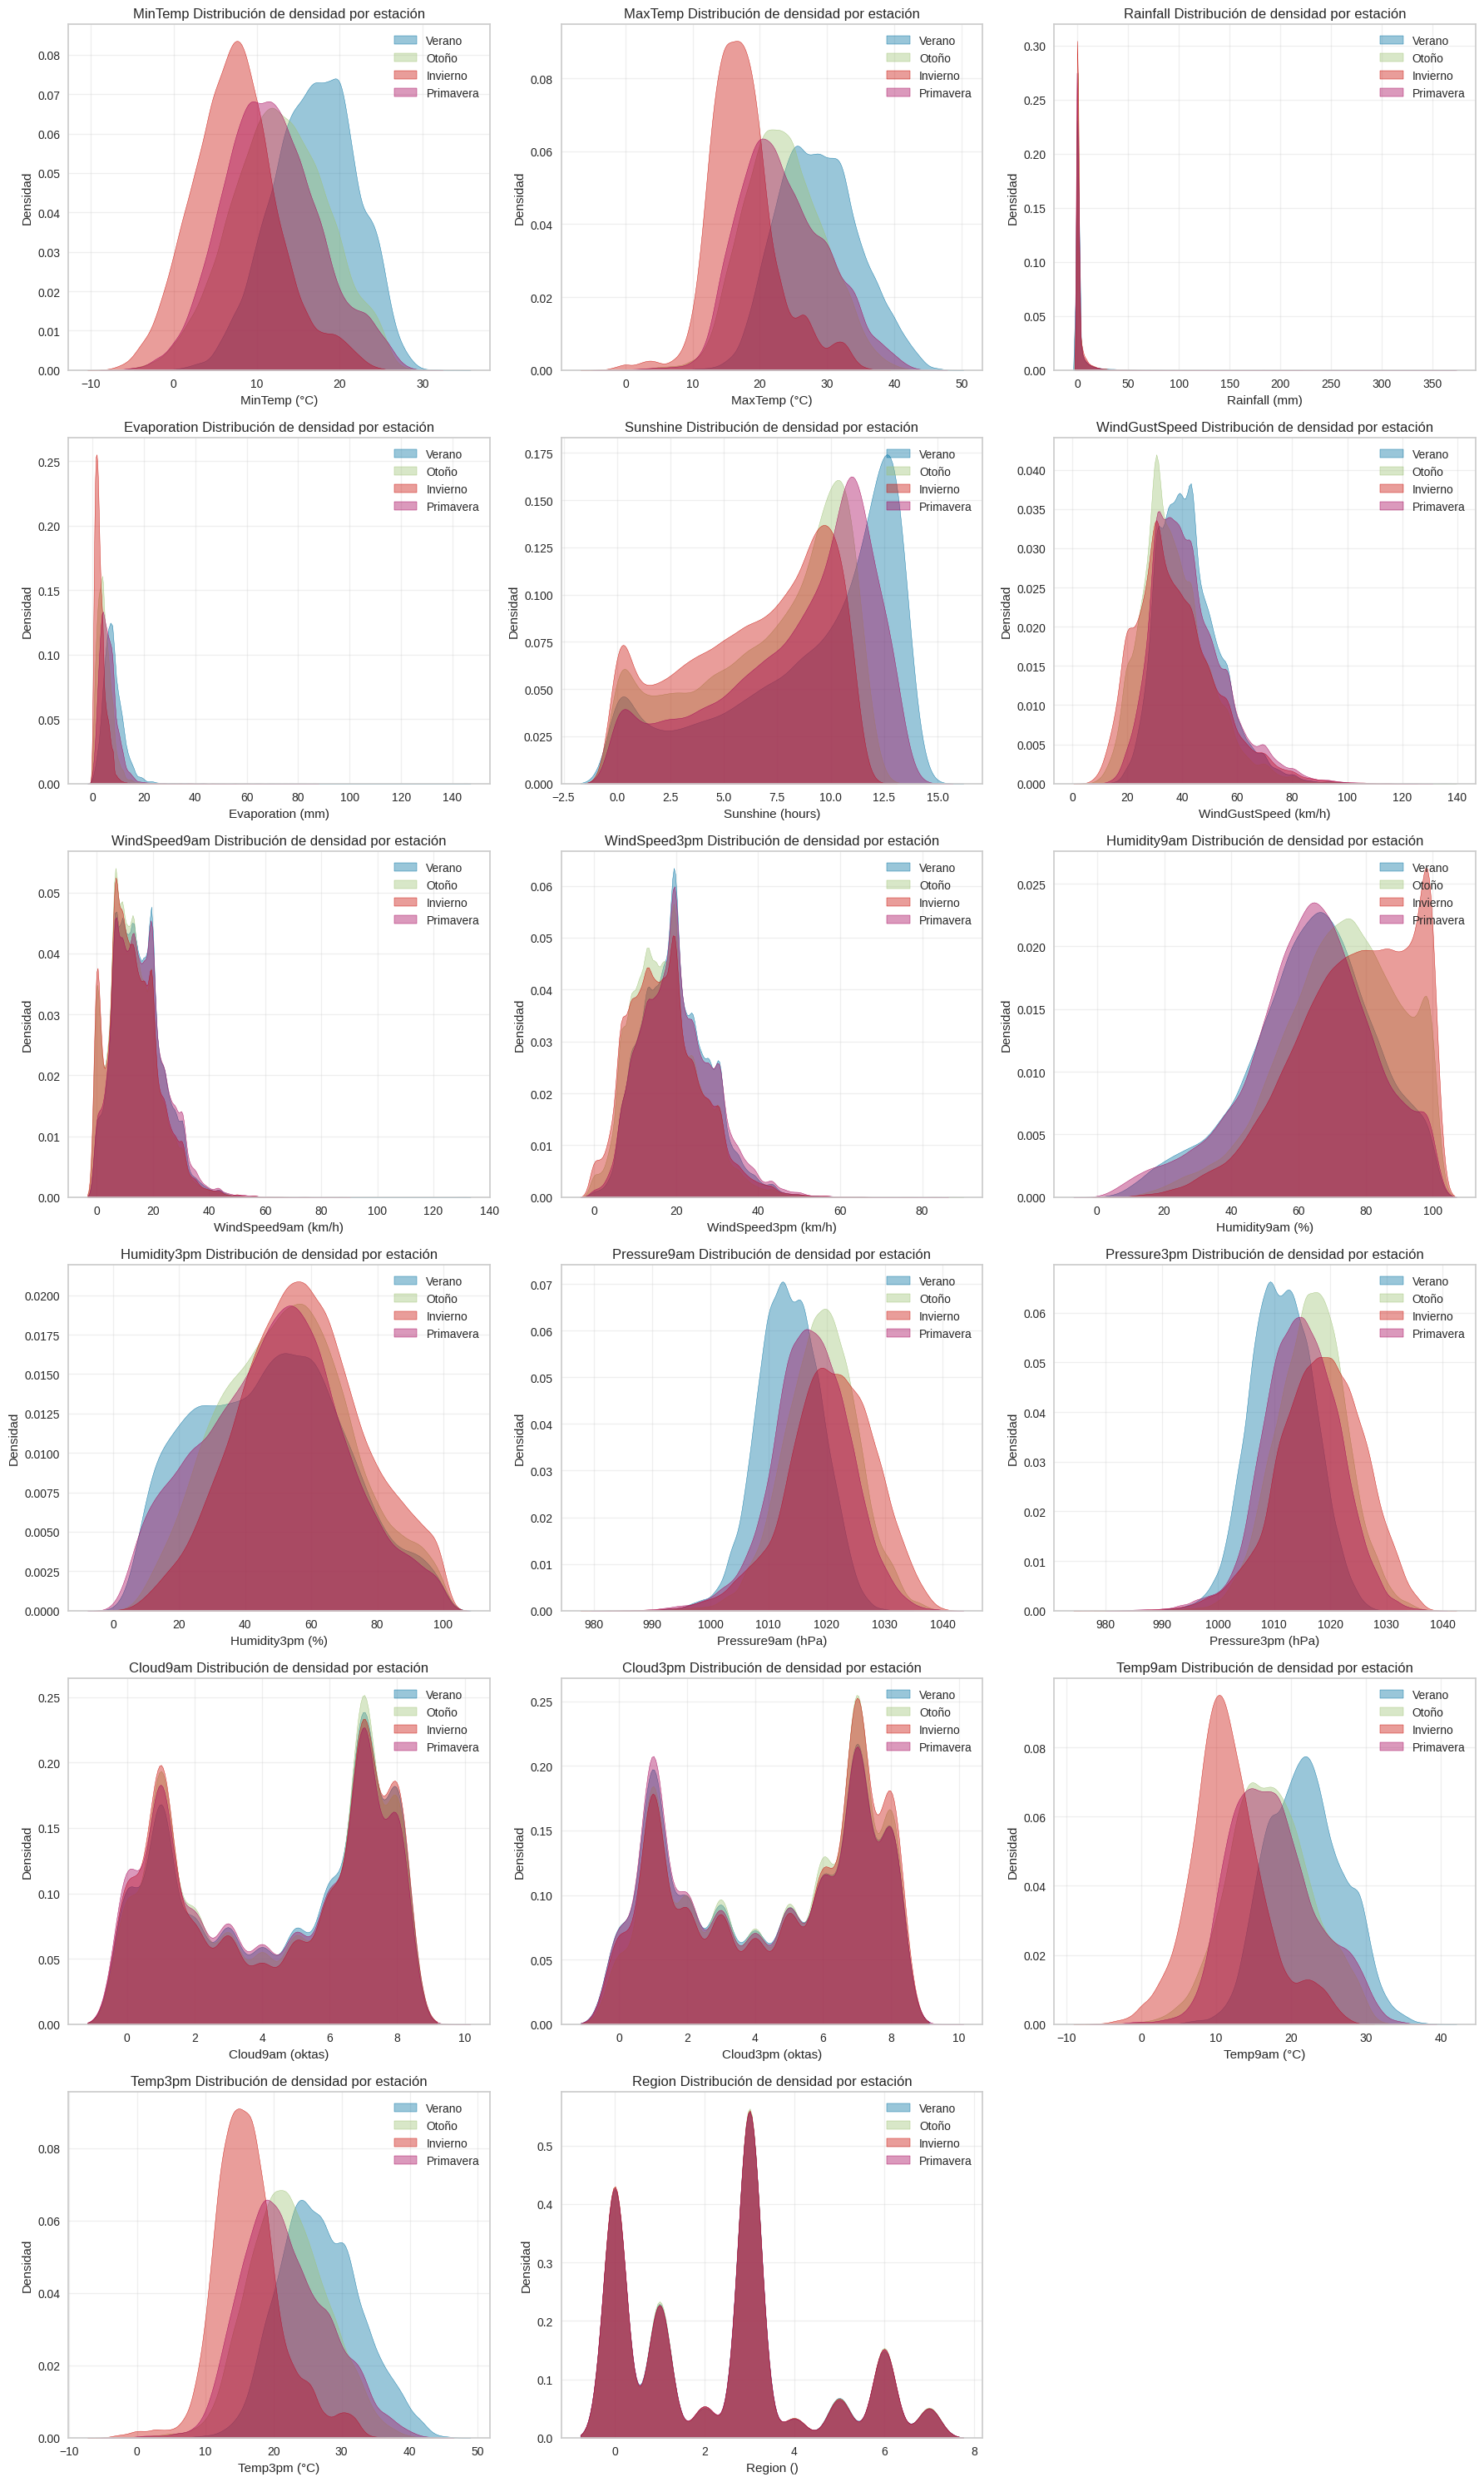

In [63]:
# Selecciona columnas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Se agregan las unidades correspondientes
units = {
    'MinTemp': '°C',
    'MaxTemp': '°C',
    'Rainfall': 'mm',
    'Evaporation': 'mm',
    'Sunshine': 'hours',
    'WindGustSpeed': 'km/h',
    'WindSpeed9am': 'km/h',
    'WindSpeed3pm': 'km/h',
    'Humidity9am': '%',
    'Humidity3pm': '%',
    'Pressure9am': 'hPa',
    'Pressure3pm': 'hPa',
    'Cloud9am': 'oktas',
    'Cloud3pm': 'oktas',
    'Temp9am': '°C',
    'Temp3pm': '°C'
}

# Número de subplots necesarios
n_cols = len(numeric_cols)
n_rows = math.ceil(n_cols / 3)

# Subplots
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5 * n_rows))
axes = axes.flatten()

# Distribución de densidad para cada variable numérica según estación
for i, col in enumerate(numeric_cols):
    for season in df['Season'].unique():
        data = df[df['Season'] == season][col].dropna() # Filter data by season and drop NaNs
        sns.kdeplot(data=data, ax=axes[i], label=season, fill=True, alpha=0.4)

    axes[i].set_title(f'{col} Distribución de densidad por estación')
    axes[i].set_xlabel(f'{col} ({units.get(col, "")})')
    axes[i].set_ylabel('Densidad')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

# Ocultar subplots no utilizados
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

Sobre las densidades se puede observar que:
- Temperatura (Temp3pm, Temp9am, MinTemp, MaxTemp): Las distribuciones están claramente separadas por estación, siendo verano la más cálida (desplazada a la derecha) e invierno la más fría (desplazada a la izquierda). Esto valida la importancia de la variable 'Season' para el modelo.

- Nubosidad (Cloud9am, Cloud3pm): La distribución es multimodal (con varios picos), especialmente notable en Cloud3pm, y muestra superposición entre las estaciones. Esto sugiere que la nubosidad es un feature complejo cuyas características no dependen únicamente de la estación.

- Lluvia (Rainfall): La distribución está sesgada a la derecha, con la gran mayoría de los valores concentrados en cero, lo cual es un indicador clave del desbalance de la variable objetivo ('RainTomorrow') y su dificultad predictiva.

- Presión (Pressure9am, Pressure3pm): Las distribuciones de presión son muy similares entre estaciones, mostrando una menor variabilidad estacional que las temperaturas, aunque la presión es ligeramente menor en verano.

## Distribución de RainTomorrow

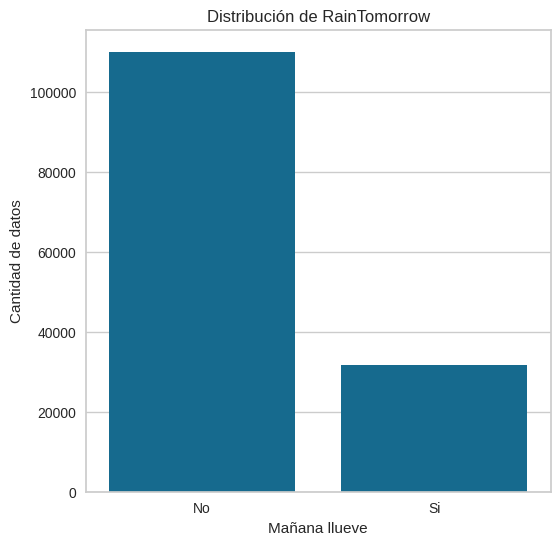

In [64]:
plt.figure(figsize=(6, 6))
sns.countplot(x=df['RainTomorrow'].map({'No': 'No', 'Yes': 'Si'}))
plt.title('Distribución de RainTomorrow')
plt.xlabel('Mañana llueve')
plt.ylabel('Cantidad de datos')
plt.show()

Este gráfico permite ver claramente que el dataset está desbalanceado y que antes de implementar una solución se deberá utilizar algún método para balancearlo.

## Boxplots según RainTomorrow

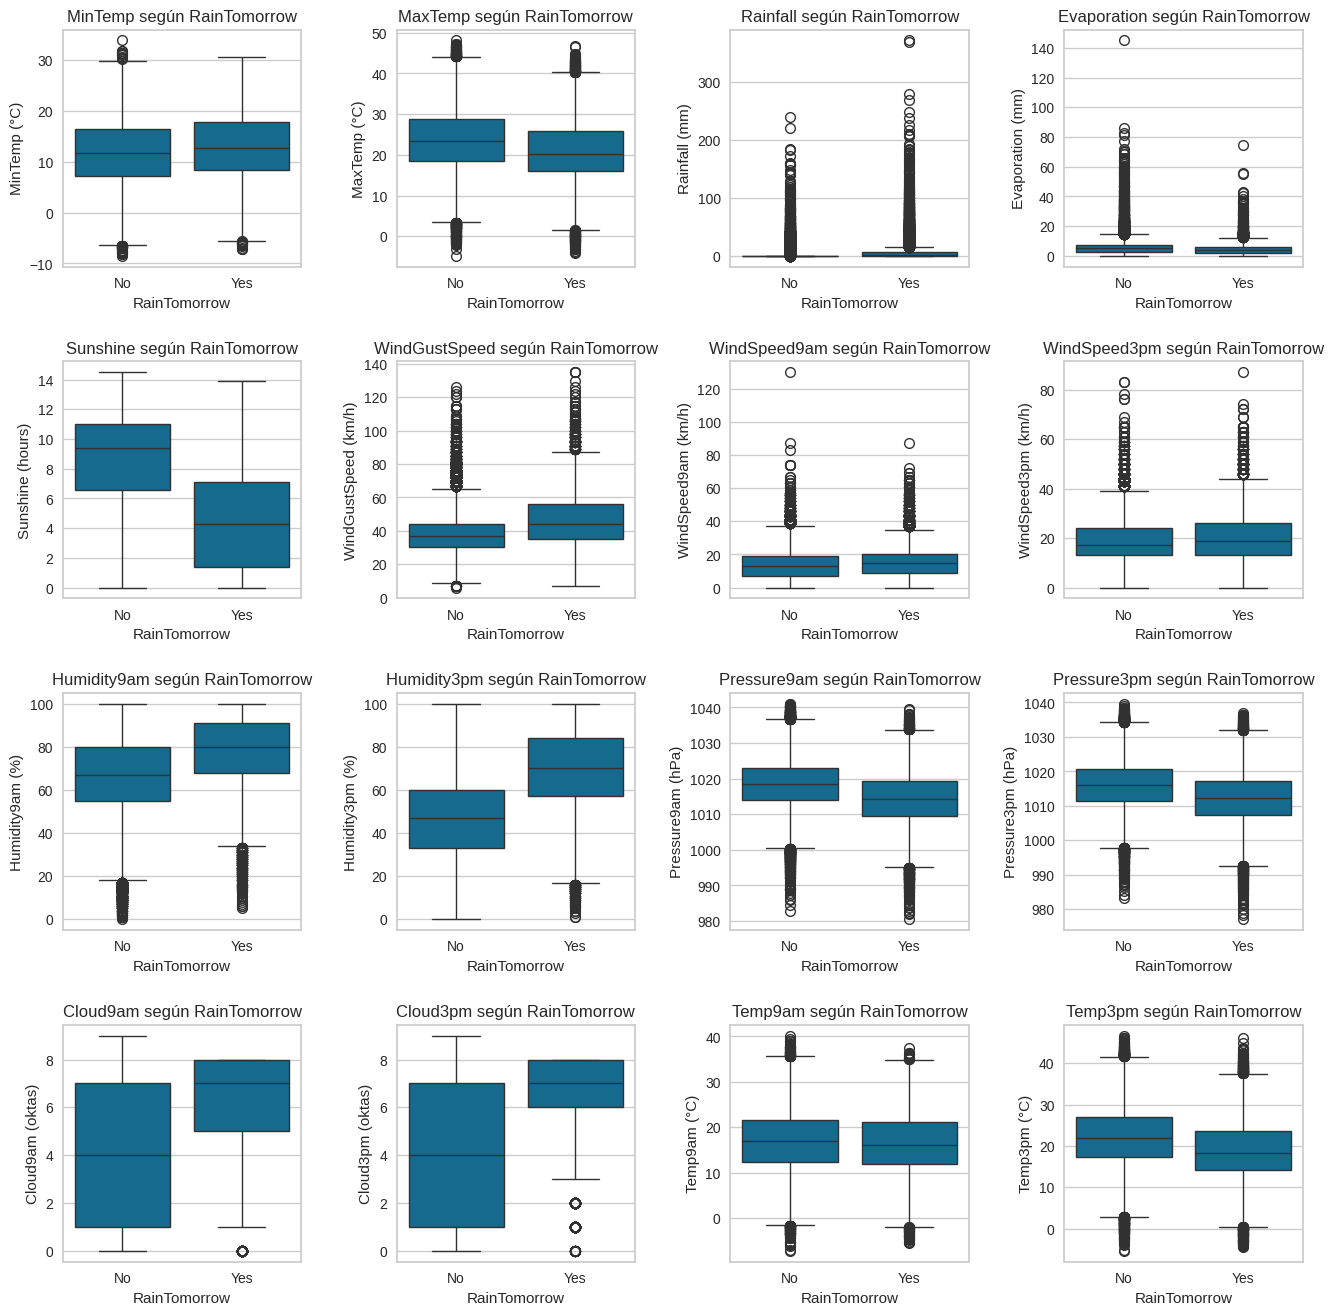

In [65]:
df_numerico = df.select_dtypes(include=['float64', 'int64'])
num_vars = len(df_numerico.columns)

# Unidades
units = {
    'MinTemp': '°C',
    'MaxTemp': '°C',
    'Rainfall': 'mm',
    'Evaporation': 'mm',
    'Sunshine': 'hours',
    'WindGustSpeed': 'km/h',
    'WindSpeed9am': 'km/h',
    'WindSpeed3pm': 'km/h',
    'Humidity9am': '%',
    'Humidity3pm': '%',
    'Pressure9am': 'hPa',
    'Pressure3pm': 'hPa',
    'Cloud9am': 'oktas',
    'Cloud3pm': 'oktas',
    'Temp9am': '°C',
    'Temp3pm': '°C',
    'Region': ''
}


fig, axes = plt.subplots(nrows=(num_vars // 4) + (num_vars % 4 > 0), ncols=4, figsize=(16, num_vars))
fig.subplots_adjust(hspace=0.4, wspace=0.4)

for i, column in enumerate(df_numerico):
    row, col_idx = divmod(i, 4)
    sns.boxplot(x='RainTomorrow', data=df, y=column, ax=axes[row, col_idx])
    axes[row, col_idx].set_title(f'{column} según RainTomorrow')
    axes[row, col_idx].set_xlabel('RainTomorrow')
    axes[row, col_idx].set_ylabel(f'{column} ({units.get(column, "")})')

for j in range(i + 1, axes.size):
    fig.delaxes(axes.flat[j])

plt.show()

Los gráficos de caja muestran que las variables clave para predecir la lluvia son aquellas con distribuciones visiblemente separadas entre los grupos 'No' y 'Yes'. Las features más distintivas son la Nubosidad (Cloud9am, Cloud3pm), la Humedad (Humidity9am, Humidity3pm), y las Horas de Sol (Sunshine). Por el contrario, las variables de Temperatura (MinTemp, MaxTemp, etc.) y Presión presentan distribuciones casi idénticas entre los dos grupos, indicando un bajo poder predictivo individual.

## Imputar valores faltantes

In [66]:
def imputar_por_region_y_estacion(df_train, df_test, cols_media, cols_mediana, cols_knn):
    df_train_imputed = df_train.copy()
    df_test_imputed = df_test.copy()

    # Diccionarios para interferencia
    all_medias_dict = {}
    all_medianas_dict = {}
    all_knn_imputers = {}

    # 1. Imputar por media: calcular estadísticas del train y aplicar a ambos
    for col in cols_media:
        # Calcular la media por Region y Season del df_train
        medias = df_train_imputed.groupby(['Region', 'Season'])[col].transform('mean')
        df_train_imputed[col] = df_train_imputed[col].fillna(medias)

        # Almacenamiento para esta columna
        all_medias_dict[col] = df_train.groupby(['Region', 'Season'])[col].mean().to_dict()

        # Aplicar las mismas medias al df_test
        df_test_imputed[col] = df_test_imputed.apply(
            lambda row: all_medias_dict[col].get((row['Region'], row['Season']), row[col])
            if pd.isna(row[col]) else row[col],
            axis=1
        )

    # 2. Imputar por mediana: calcular estadísticas del train y aplicar a ambos
    for col in cols_mediana:
        # Calcular la mediana por Region y Season del df_train
        medianas = df_train_imputed.groupby(['Region', 'Season'])[col].transform('median')
        df_train_imputed[col] = df_train_imputed[col].fillna(medianas)

        # Almacenamiento para esta columna
        all_medianas_dict[col] = df_train.groupby(['Region', 'Season'])[col].median().to_dict()

        # Aplicar las mismas medianas al df_test
        df_test_imputed[col] = df_test_imputed.apply(
            lambda row: all_medianas_dict[col].get((row['Region'], row['Season']), row[col])
            if pd.isna(row[col]) else row[col],
            axis=1
        )

    # 3. Imputar por KNN: entrenar con train, transformar ambos - Almacenar TODOS los imputadores por columna Y por grupo
    for col in cols_knn:
        all_knn_imputers[col] = {}

        for (region, season), df_region_train in df_train_imputed.groupby(['Region', 'Season']):
            # Entrenar el imputador con los datos de train
            imputador = KNNImputer(n_neighbors=5)
            imputador.fit(df_region_train[[col]])  # Ajustar a una sola columna

            # Almacenar este imputador
            all_knn_imputers[col][(region, season)] = imputador

            # Transformar train
            imputadas_train = imputador.transform(df_region_train[[col]])
            df_train_imputed.loc[df_region_train.index, col] = imputadas_train.ravel()

            # Transformar test (si existen datos para esta combinación de Region y Season)
            df_region_test = df_test_imputed[
                (df_test_imputed['Region'] == region) &
                (df_test_imputed['Season'] == season)
            ]
            if len(df_region_test) > 0:
                imputadas_test = imputador.transform(df_region_test[[col]])
                df_test_imputed.loc[df_region_test.index, col] = imputadas_test.ravel()

    return df_train_imputed, df_test_imputed, all_medias_dict, all_medianas_dict, all_knn_imputers

def imputar_categoricas_por_moda(df_train, df_test, cols_categoricas):
    """
    Imputa variables categóricas usando la moda por Region y Season.
    Aprende las modas del df_train y las aplica a ambos dataframes.

    Args:
        df_train: DataFrame de entrenamiento
        df_test: DataFrame de prueba
        cols_categoricas: Lista de columnas categóricas a imputar

    Returns:
        Tupla (df_train_imputed, df_test_imputed, all_modas_dict)
    """
    df_train_imputed = df_train.copy()
    df_test_imputed = df_test.copy()

    # Inicializar diccionario para recolectar TODAS las columnas
    all_modas_dict = {}

    for col in cols_categoricas:
        # Calcular la moda por Region y Season del df_train
        # lambda x: x.mode()[0] if not x.mode().empty else None maneja casos sin moda
        all_modas_dict[col] = df_train.groupby(['Region', 'Season'])[col].apply(
            lambda x: x.mode()[0] if not x.mode().empty else None
        ).to_dict()

        # Aplicar la moda al df_train
        df_train_imputed[col] = df_train_imputed.apply(
            lambda row: all_modas_dict[col].get((row['Region'], row['Season']), row[col])
            if pd.isna(row[col]) else row[col],
            axis=1
        )

        # Aplicar las mismas modas al df_test
        df_test_imputed[col] = df_test_imputed.apply(
            lambda row: all_modas_dict[col].get((row['Region'], row['Season']), row[col])
            if pd.isna(row[col]) else row[col],
            axis=1
        )

    return df_train_imputed, df_test_imputed, all_modas_dict

La imputación de valores faltantes se realizará con los siguientes criterior:
- Promedio ==> variables que tienen una distribución sesgada o con valores atípicos
- Mediana ==> distribución simétrica o normal
- KNN ==> distribuciones multimodales

In [67]:
cols_media = ['MinTemp', 'MaxTemp', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Temp9am', 'Temp3pm']
cols_mediana = ['WindSpeed9am', 'WindSpeed3pm', 'WindGustSpeed']
cols_knn = ['Evaporation','Rainfall', 'Cloud9am','Cloud3pm', 'Sunshine']
cols_cat = ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']

## Split en train-test

In [68]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=0)
train_df, test_df, medias_dict, medianas_dict, knn_imputers = imputar_por_region_y_estacion(train_df, test_df, cols_media, cols_mediana, cols_knn)
train_df, test_df, modas_dict = imputar_categoricas_por_moda(train_df, test_df, cols_cat)

In [69]:
train_df.isna().sum()

MinTemp          0
MaxTemp          0
Rainfall         0
Evaporation      0
Sunshine         0
WindGustDir      0
WindGustSpeed    0
WindDir9am       0
WindDir3pm       0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
Temp9am          0
Temp3pm          0
RainToday        0
RainTomorrow     0
Region           0
Season           0
dtype: int64

## Codificación de variables categóricas

In [70]:
train_df['WindGustDir'].unique()

array(['NE', 'ESE', 'SE', 'ENE', 'S', 'NNW', 'SSW', 'N', 'E', 'W', 'NW',
       'WNW', 'WSW', 'SW', 'NNE', 'SSE'], dtype=object)

Se codifican la variables 'WindGustDir', 'WindDir9am', 'WindDir3pm' de manera cíclica utilizando seno y coseno, y las variables 'Region', 'Season', 'RainToday', 'RainTomorrow' con one-hot encoding.

In [71]:
def codificar_viento_ciclico(df_train, df_test, cols_viento):
    """
    Codifica direcciones de viento de forma cíclica usando seno y coseno.

    Args:
        df_train: DataFrame de entrenamiento
        df_test: DataFrame de prueba
        cols_viento: Lista de columnas de dirección de viento a codificar

    Returns:
        Tupla (df_train_encoded, df_test_encoded)
    """
    # Orden de las direcciones de viento (16 puntos cardinales)
    direcciones = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
                    'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']

    # Crear un mapeo de dirección a ángulo (en radianes)
    # Cada dirección está separada por 360/16 = 22.5 grados
    angulos = {direccion: (i * 2 * np.pi / 16) for i, direccion in enumerate(direcciones)}

    df_train_encoded = df_train.copy()
    df_test_encoded = df_test.copy()

    for col in cols_viento:
        # Mapear direcciones a ángulos y calcular seno y coseno
        train_angulos = df_train_encoded[col].map(angulos)
        test_angulos = df_test_encoded[col].map(angulos)

        # Crear columnas de seno y coseno
        df_train_encoded[f'{col}_sin'] = train_angulos.apply(lambda x: np.sin(x) if pd.notna(x) else np.nan)
        df_train_encoded[f'{col}_cos'] = train_angulos.apply(lambda x: np.cos(x) if pd.notna(x) else np.nan)

        df_test_encoded[f'{col}_sin'] = test_angulos.apply(lambda x: np.sin(x) if pd.notna(x) else np.nan)
        df_test_encoded[f'{col}_cos'] = test_angulos.apply(lambda x: np.cos(x) if pd.notna(x) else np.nan)

        # Eliminar la columna original
        df_train_encoded = df_train_encoded.drop(columns=[col])
        df_test_encoded = df_test_encoded.drop(columns=[col])

    return df_train_encoded, df_test_encoded


def codificar_dummies(df_train, df_test, cols_dummies):
    """
    Codifica variables categóricas usando one-hot encoding (variables dummy).

    Args:
        df_train: DataFrame de entrenamiento
        df_test: DataFrame de prueba
        cols_dummies: Lista de columnas a codificar con dummies

    Returns:
        Tupla (df_train_encoded, df_test_encoded)
    """
    # Aplicar get_dummies a train
    df_train_encoded = pd.get_dummies(df_train, columns=cols_dummies, drop_first=True)

    # Aplicar get_dummies a test
    df_test_encoded = pd.get_dummies(df_test, columns=cols_dummies, drop_first=True)

    # Asegurar que test tenga las mismas columnas que train (en el mismo orden)
    # Agregar columnas faltantes en test con valores 0
    for col in df_train_encoded.columns:
        if col not in df_test_encoded.columns:
            df_test_encoded[col] = 0

    # Reordenar las columnas de test para que coincidan con train
    df_test_encoded = df_test_encoded[df_train_encoded.columns]

    return df_train_encoded, df_test_encoded

In [72]:
cols_viento = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
train_df, test_df = codificar_viento_ciclico(train_df, test_df, cols_viento)

cols_dummies = ['Region', 'Season', 'RainToday', 'RainTomorrow']
train_df, test_df = codificar_dummies(train_df, test_df, cols_dummies)

In [73]:
# Todas las columnas que NO son dummies
cols_dummies = [col for col in train_df.columns if any(x in col for x in ['Region_', 'Season_', 'RainToday_'])]
# Excluir RainTomorrow_Yes del escalado (es la variable objetivo y debe mantenerse binaria)
cols_a_estandarizar = [col for col in train_df.columns
                        if col not in cols_dummies and col != 'RainTomorrow_Yes']

scaler = StandardScaler()
train_df[cols_a_estandarizar] = scaler.fit_transform(train_df[cols_a_estandarizar])
test_df[cols_a_estandarizar] = scaler.transform(test_df[cols_a_estandarizar])



In [74]:
train_df.columns

Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'WindGustDir_sin', 'WindGustDir_cos',
       'WindDir9am_sin', 'WindDir9am_cos', 'WindDir3pm_sin', 'WindDir3pm_cos',
       'Region_1', 'Region_2', 'Region_3', 'Region_4', 'Region_5', 'Region_6',
       'Region_7', 'Season_Otoño', 'Season_Primavera', 'Season_Verano',
       'RainToday_Yes', 'RainTomorrow_Yes'],
      dtype='object')

## Aplicación de SMOTE-ENN para balanceo de clases

### Comparación entre SMOTE-ENN y SMOTE-Tomek

#### Diferencias esperadas entre los métodos:

**SMOTE-ENN:**
- Más agresivo en la limpieza
- Elimina más muestras (especialmente de la clase mayoritaria)
- Dataset final generalmente más pequeño
- Mejor para eliminar ruido y muestras ambiguas

**SMOTE-Tomek:**
- Más conservador
- Solo elimina pares en la frontera entre clases (Tomek Links)
- Dataset final generalmente más grande
- Mejor para mantener más información del dataset original

Tamaño entrenamiento: (113467, 33)
Tamaño prueba: (28367, 33)
Distribución en y_train:
RainTomorrow_Yes
False    0.775327
True     0.224673
Name: proportion, dtype: float64

Distribución en y_test:
RainTomorrow_Yes
False    0.778369
True     0.221631
Name: proportion, dtype: float64
Distribución ANTES de SMOTE-ENN:
Clase 0 (No llueve): 87974 (77.53%)
Clase 1 (Llueve): 25493 (22.47%)
Total: 113467

Distribución DESPUÉS de SMOTE-ENN:
Clase 0 (No llueve): 57815 (41.56%)
Clase 1 (Llueve): 81283 (58.44%)
Total: 139098


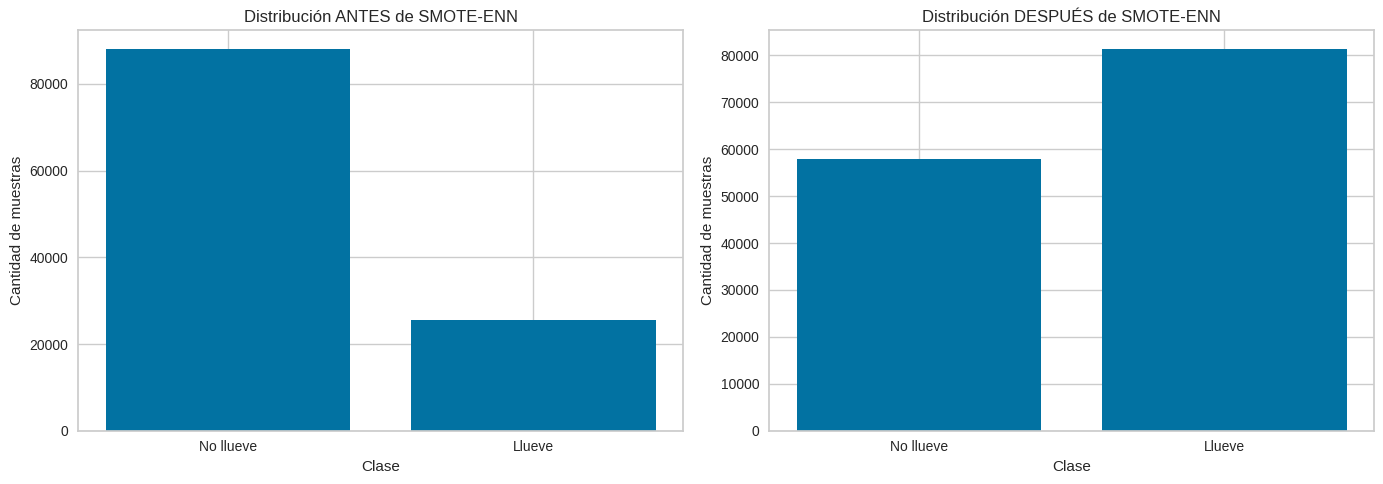

In [75]:
# Separar las variables predictoras (X) de la variable objetivo (y)
x_train = train_df.drop(columns=['RainTomorrow_Yes'])
y_train = train_df['RainTomorrow_Yes']

x_test = test_df.drop(columns=['RainTomorrow_Yes'])
y_test = test_df['RainTomorrow_Yes']

# Reporte rápido
print("Tamaño entrenamiento:", x_train.shape)
print("Tamaño prueba:", x_test.shape)
print("Distribución en y_train:")
print(y_train.value_counts(normalize=True))
print("\nDistribución en y_test:")
print(y_test.value_counts(normalize=True))

# Verificar distribución antes de SMOTE-ENN
print("Distribución ANTES de SMOTE-ENN:")
print(f"Clase 0 (No llueve): {(y_train == 0).sum()} ({(y_train == 0).sum() / len(y_train) * 100:.2f}%)")
print(f"Clase 1 (Llueve): {(y_train == 1).sum()} ({(y_train == 1).sum() / len(y_train) * 100:.2f}%)")
print(f"Total: {len(y_train)}")

# Aplicar SMOTE-ENN solo al conjunto de entrenamiento
smote_enn = SMOTEENN(random_state=0)
x_train_resampled_enn, y_train_resampled_enn = smote_enn.fit_resample(x_train, y_train)

# Verificar distribución después de SMOTE-ENN
print("\nDistribución DESPUÉS de SMOTE-ENN:")
print(f"Clase 0 (No llueve): {(y_train_resampled_enn == 0).sum()} ({(y_train_resampled_enn == 0).sum() / len(y_train_resampled_enn) * 100:.2f}%)")
print(f"Clase 1 (Llueve): {(y_train_resampled_enn == 1).sum()} ({(y_train_resampled_enn == 1).sum() / len(y_train_resampled_enn) * 100:.2f}%)")
print(f"Total: {len(y_train_resampled_enn)}")

# Visualizar la distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes de SMOTE-ENN
axes[0].bar(['No llueve', 'Llueve'], [((y_train == 0).sum()), ((y_train == 1).sum())])
axes[0].set_title('Distribución ANTES de SMOTE-ENN')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].set_xlabel('Clase')

# Después de SMOTE-ENN
axes[1].bar(['No llueve', 'Llueve'], [((y_train_resampled_enn == 0).sum()), ((y_train_resampled_enn == 1).sum())])
axes[1].set_title('Distribución DESPUÉS de SMOTE-ENN')
axes[1].set_ylabel('Cantidad de muestras')
axes[1].set_xlabel('Clase')

plt.tight_layout()
plt.show()

In [76]:
# CREAR CONJUNTO DE VALIDACIÓN (ANTES DE SMOTE)
# Este conjunto de validación se usa para optimización de umbrales

print("\n" + "="*60)
print("CREANDO CONJUNTO DE VALIDACIÓN")
print("="*60)

# Split: 80% train_full, 20% validation
x_train_full, x_valid, y_train_full, y_valid = train_test_split(
    x_train, y_train, test_size=0.2, random_state=0, stratify=y_train
)

print(f"\nTamaño train_full: {x_train_full.shape}")
print(f"    Tamaño validation: {x_valid.shape}")
print(f"    Tamaño test (sin cambios): {x_test.shape}")

print(f"\nDistribución en train_full:")
print(f"    Clase 0 (No llueve): {(y_train_full == 0).sum()} ({(y_train_full == 0).sum() / len(y_train_full) * 100:.2f}%)")
print(f"    Clase 1 (Llueve): {(y_train_full == 1).sum()} ({(y_train_full == 1).sum() / len(y_train_full) * 100:.2f}%)")

print(f"\nDistribución en validation:")
print(f"    Clase 0 (No llueve): {(y_valid == 0).sum()} ({(y_valid == 0).sum() / len(y_valid) * 100:.2f}%)")
print(f"    Clase 1 (Llueve): {(y_valid == 1).sum()} ({(y_valid == 1).sum() / len(y_valid) * 100:.2f}%)")



CREANDO CONJUNTO DE VALIDACIÓN

Tamaño train_full: (90773, 33)
    Tamaño validation: (22694, 33)
    Tamaño test (sin cambios): (28367, 33)

Distribución en train_full:
    Clase 0 (No llueve): 70379 (77.53%)
    Clase 1 (Llueve): 20394 (22.47%)

Distribución en validation:
    Clase 0 (No llueve): 17595 (77.53%)
    Clase 1 (Llueve): 5099 (22.47%)


Distribución DESPUÉS de SMOTE-Tomek:
Clase 0 (No llueve): 70192 (50.00%)
Clase 1 (Llueve): 70192 (50.00%)
Total: 140384


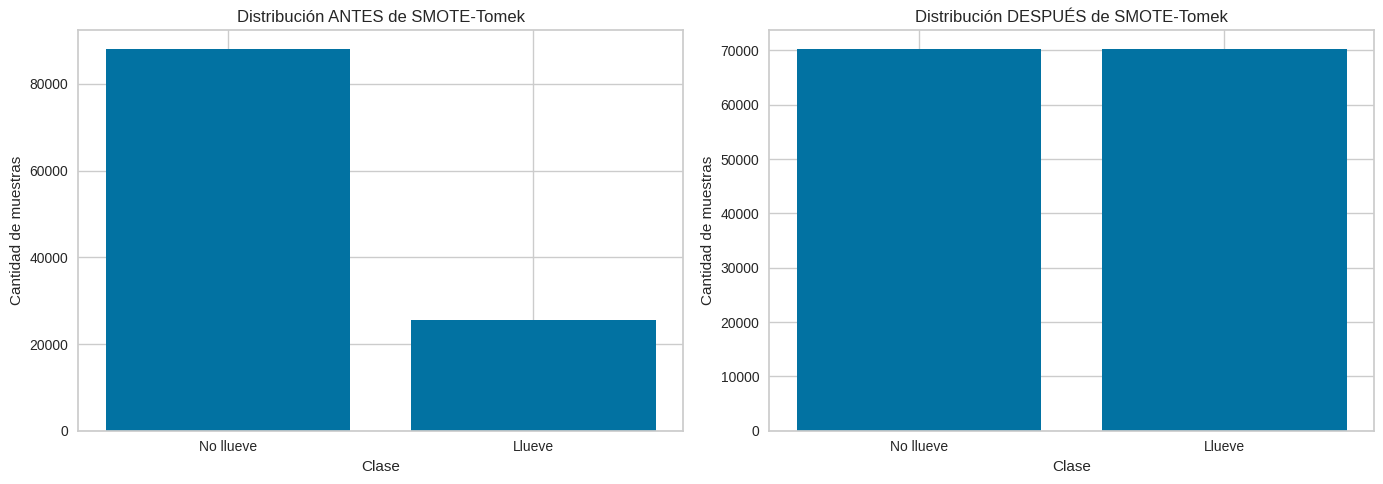

In [77]:
# Aplicar SMOTE-Tomek solo al conjunto de entrenamiento
smote_tomek = SMOTETomek(random_state=0)
x_train_resampled_tomek, y_train_resampled_tomek = smote_tomek.fit_resample(x_train_full, y_train_full)

# Verificar distribución después de SMOTE-Tomek
print("Distribución DESPUÉS de SMOTE-Tomek:")
print(f"Clase 0 (No llueve): {(y_train_resampled_tomek == 0).sum()} ({(y_train_resampled_tomek == 0).sum() / len(y_train_resampled_tomek) * 100:.2f}%)")
print(f"Clase 1 (Llueve): {(y_train_resampled_tomek == 1).sum()} ({(y_train_resampled_tomek == 1).sum() / len(y_train_resampled_tomek) * 100:.2f}%)")
print(f"Total: {len(y_train_resampled_tomek)}")

# Visualizar la distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Antes de SMOTE-Tomek
axes[0].bar(['No llueve', 'Llueve'], [((y_train == 0).sum()), ((y_train == 1).sum())])
axes[0].set_title('Distribución ANTES de SMOTE-Tomek')
axes[0].set_ylabel('Cantidad de muestras')
axes[0].set_xlabel('Clase')

# Después de SMOTE-Tomek
axes[1].bar(['No llueve', 'Llueve'], [((y_train_resampled_tomek == 0).sum()), ((y_train_resampled_tomek == 1).sum())])
axes[1].set_title('Distribución DESPUÉS de SMOTE-Tomek')
axes[1].set_ylabel('Cantidad de muestras')
axes[1].set_xlabel('Clase')

plt.tight_layout()
plt.show()

# 3. Regresión logística

In [78]:
# x_train, y_train
# x_train_resampled_enn, y_train_resampled_enn
# x_train_resampled_tomek, y_train_resampled_tomek

model_l2 = LogisticRegression()
model_l2.fit(x_train, y_train)

y_pred_l2 = model_l2.predict(x_test)

y_pred_l2 = model_l2.predict(x_test)
y_proba_l2 = model_l2.predict_proba(x_test)[:, 1]
f1_l2 = f1_score(y_test, y_pred_l2)

print(f"F1-score (L2 default): {f1_l2:.2f}")

F1-score (L2 default): 0.58


In [79]:
# x_train, y_train
# x_train_resampled_enn, y_train_resampled_enn
# x_train_resampled_tomek, y_train_resampled_tomek

model_l2 = LogisticRegression()
model_l2.fit(x_train, y_train)

y_pred_l2 = model_l2.predict(x_test)
f1_l2 = f1_score(y_test, y_pred_l2)

model_enn = LogisticRegression()
model_enn.fit(x_train_resampled_enn, y_train_resampled_enn)

y_pred_enn = model_enn.predict(x_test)
f1_enn = f1_score(y_test, y_pred_enn)

model_tomek = LogisticRegression()
model_tomek.fit(x_train_resampled_tomek, y_train_resampled_tomek)

y_pred_tomek = model_tomek.predict(x_test)
f1_tomek = f1_score(y_test, y_pred_tomek)

print(f"F1-score (L2 default): {f1_l2:.2f}")
print(f"F1-score (SMOTE-ENN): {f1_enn:.2f}")
print(f"F1-score (SMOTE-Tomek): {f1_tomek:.2f}")


F1-score (L2 default): 0.58
F1-score (SMOTE-ENN): 0.59
F1-score (SMOTE-Tomek): 0.62


Vemos que con un balanceo hecho a partir de SMOTE-Tomek, no sólo el valor de F1-score mejora, si no que las clases quedan cada una con $50\%$ del total de los datos. Con esto, sumado al hecho de que Tomek nos deja un dataset más grande y más fiel al original, se decidió continuar trabajando con este.

In [80]:
y_proba = model_tomek.predict_proba(x_test)[:, 1]

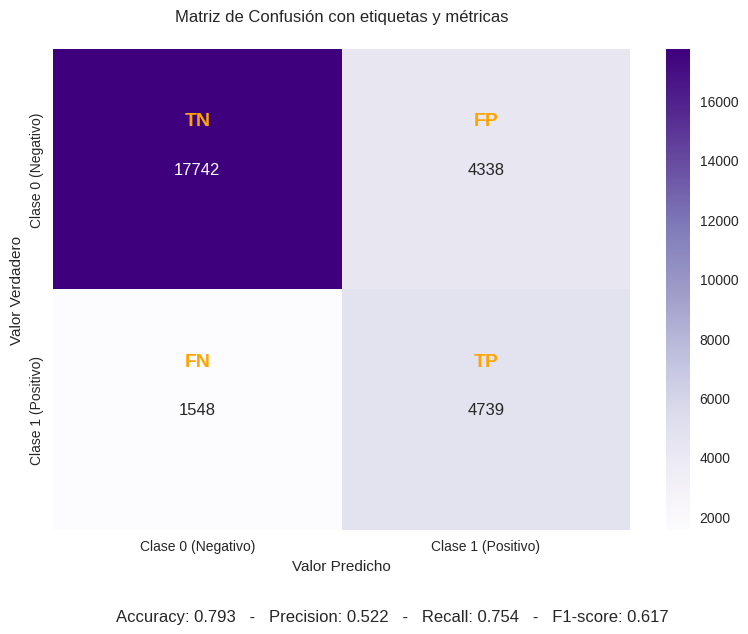

In [81]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_tomek)

# Calcular métricas
accuracy = accuracy_score(y_test, y_pred_tomek)
precision = precision_score(y_test, y_pred_tomek)
recall = recall_score(y_test, y_pred_tomek)
f1 = f1_score(y_test, y_pred_tomek)

# Crear la figura
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Clase 0 (Negativo)', 'Clase 1 (Positivo)'],
            yticklabels=['Clase 0 (Negativo)', 'Clase 1 (Positivo)'])

plt.ylabel('Valor Verdadero')
plt.xlabel('Valor Predicho')
plt.title('Matriz de Confusión con etiquetas y métricas', pad=20)

# Anotaciones TN, FP, FN, TP (coordenadas ajustadas al centro de cada celda)
plt.text(0.5, 0.3, 'TN', ha='center', va='center', color='orange', fontsize=14, fontweight='bold')
plt.text(1.5, 0.3, 'FP', ha='center', va='center', color='orange', fontsize=14, fontweight='bold')
plt.text(0.5, 1.3, 'FN', ha='center', va='center', color='orange', fontsize=14, fontweight='bold')
plt.text(1.5, 1.3, 'TP', ha='center', va='center', color='orange', fontsize=14, fontweight='bold')

# Mostrar métricas debajo del gráfico
plt.figtext(0.5, -0.05,
            f'Accuracy: {accuracy:.3f}   -   Precision: {precision:.3f}   -   Recall: {recall:.3f}   -   F1-score: {f1:.3f}',
            wrap=True, horizontalalignment='center', fontsize=12)

plt.tight_layout()
plt.show()

- Falsos Negativos (FN = 1.548): Son los días en que el modelo predijo 'No lloverá', pero sí llovió. Representan un error que lleva a las personas a no prepararse para la lluvia. Por lo tanto, en el contexto de predicción de lluvia, es considerado el error más costoso, ya que falla cuando más se necesita.

- Falsos Positivos (FP = 4.338): Son los días en que el modelo predijo 'Lloverá', pero no llovió. Llevan a las personas a prepararse innecesariamente, por lo que puede ser un error molesto pero menos grabe que un falso negativo. Sin embargo, la alta cantidad de falsos positivos contribuye a la baja Precision (Precision=0,522).

In [82]:
# OPTIMIZACIÓN DE UMBRAL EN CONJUNTO DE VALIDACIÓN

print("\n" + "="*60)
print("OPTIMIZANDO UMBRAL EN CONJUNTO DE VALIDACIÓN")
print("="*60)

# Generar probabilidades en VALIDACIÓN
y_proba_valid = model_tomek.predict_proba(x_valid)[:, 1]

# Generar thresholds desde la curva ROC de VALIDACIÓN
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, y_proba_valid)

# Encontrar umbral óptimo usando VALIDACIÓN
f1_scores_valid = []
for thresh in thresholds_valid:
    y_pred_thresh = (y_proba_valid >= thresh).astype(int)
    f1_scores_valid.append(f1_score(y_valid, y_pred_thresh))  # Usa y_valid

optimal_idx = np.argmax(f1_scores_valid)
optimal_threshold = thresholds_valid[optimal_idx]
best_f1_valid = f1_scores_valid[optimal_idx]

print(f"\nÓptimo umbral (maximizando F1 en validación): {optimal_threshold:.4f}")
print(f"F1-score en validación con umbral óptimo: {best_f1_valid:.4f}")

# Evalua en TEST con el umbral encontrado en validación
print("\n" + "="*60)
print("EVALUACIÓN EN CONJUNTO DE TEST")
print("="*60)

y_proba_test = model_tomek.predict_proba(x_test)[:, 1]
y_pred_optimal_test = (y_proba_test >= optimal_threshold).astype(int)
y_pred_05_test = (y_proba_test >= 0.5).astype(int)

print(f"\nMétricas en TEST con umbral 0.5:")
print(f"  F1-score: {f1_score(y_test, y_pred_05_test):.4f}")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_05_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_05_test):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_05_test):.4f}")

print(f"\nMétricas en TEST con umbral óptimo ({optimal_threshold:.4f}):")
print(f"  F1-score: {f1_score(y_test, y_pred_optimal_test):.4f}")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_optimal_test):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_optimal_test):.4f}")
print(f"  Recall: {recall_score(y_test, y_pred_optimal_test):.4f}")


OPTIMIZANDO UMBRAL EN CONJUNTO DE VALIDACIÓN

Óptimo umbral (maximizando F1 en validación): 0.5999
F1-score en validación con umbral óptimo: 0.6311

EVALUACIÓN EN CONJUNTO DE TEST

Métricas en TEST con umbral 0.5:
  F1-score: 0.6169
  Accuracy: 0.7925
  Precision: 0.5221
  Recall: 0.7538

Métricas en TEST con umbral óptimo (0.5999):
  F1-score: 0.6202
  Accuracy: 0.8177
  Precision: 0.5761
  Recall: 0.6715


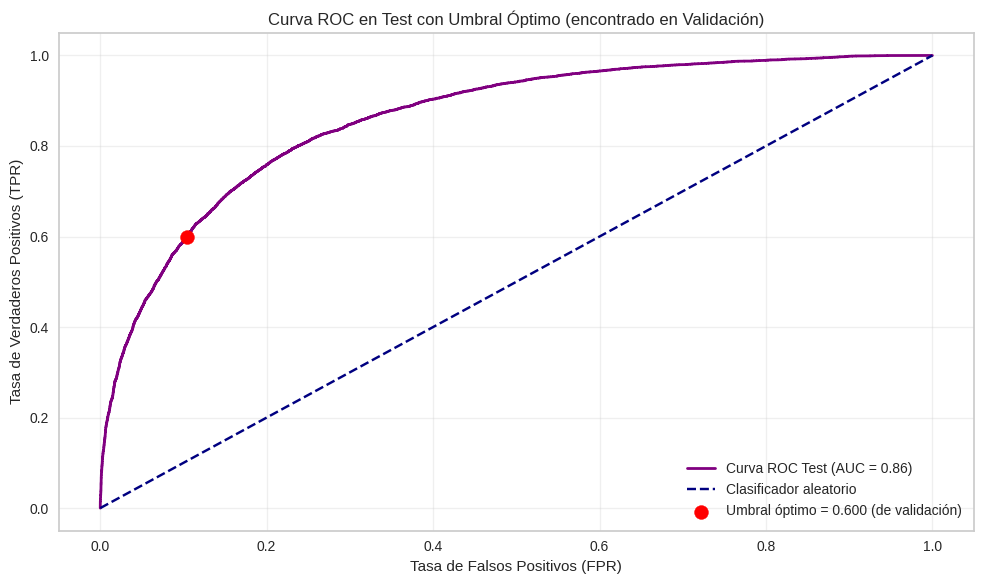

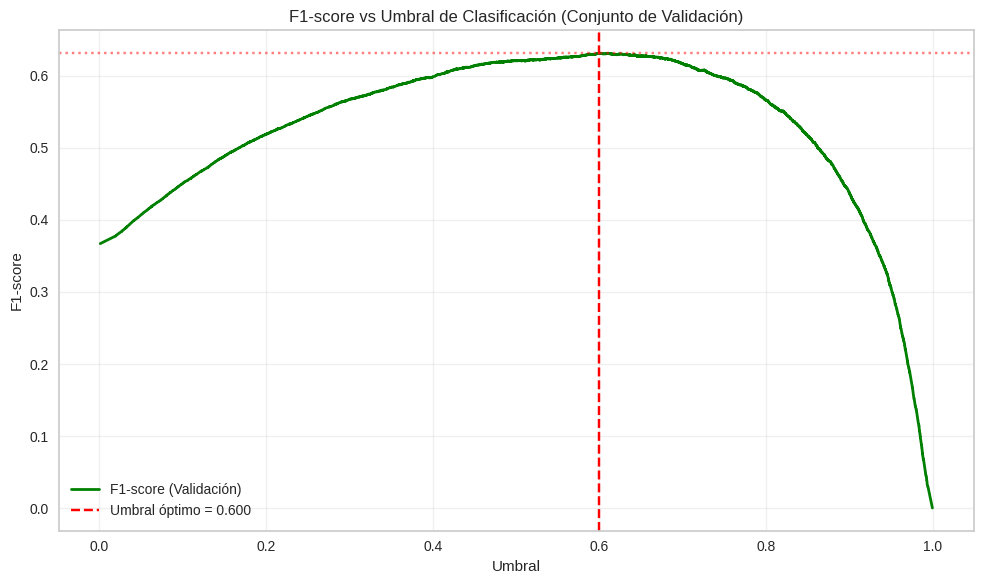

In [83]:
# VISUALIZACIÓN: CURVA ROC CON UMBRAL ÓPTIMO

# Curva ROC en TEST (para visualización final)
fpr_test, tpr_test, _ = roc_curve(y_test, y_proba_test)
roc_auc_test = roc_auc_score(y_test, y_proba_test)

plt.figure(figsize=(10, 6))
plt.plot(fpr_test, tpr_test, label=f'Curva ROC Test (AUC = {roc_auc_test:.2f})',
         color='purple', lw=2)
plt.plot([0, 1], [0, 1], color='navy', linestyle='--', label='Clasificador aleatorio')

# Encontrar el punto en la curva de TEST que corresponde al umbral óptimo
# (Nota: este umbral fue encontrado en validación, no en test)
idx_test = np.argmin(np.abs(thresholds_valid - optimal_threshold))
if idx_test < len(fpr_test):
    plt.scatter(fpr_test[idx_test], tpr_test[idx_test],
                color='red', s=100, zorder=5,
                label=f'Umbral óptimo = {optimal_threshold:.3f} (de validación)')

plt.xlabel('Tasa de Falsos Positivos (FPR)')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)')
plt.title('Curva ROC en Test con Umbral Óptimo (encontrado en Validación)')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# VISUALIZACIÓN: F1-SCORE VS UMBRAL (en validación)
plt.figure(figsize=(10, 6))
plt.plot(thresholds_valid, f1_scores_valid, label='F1-score (Validación)',
         color='green', lw=2)
plt.axvline(optimal_threshold, color='red', linestyle='--',
            label=f'Umbral óptimo = {optimal_threshold:.3f}')
plt.axhline(best_f1_valid, color='red', linestyle=':', alpha=0.5)
plt.xlabel('Umbral')
plt.ylabel('F1-score')
plt.title('F1-score vs Umbral de Clasificación (Conjunto de Validación)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


La Curva ROC muestra un AUC de $0.86$, lo que indica que el modelo es capaz de distinguir bien entre las clases. Observando el gráfico F1-score vs. Umbral, se determinó que el valor que maximiza el F1-score es $Umbral = 0,6$, logrando un $F1-score = 0,6202$. La mejora en F1-score se debe a un aumento de Precision (de $0,5221$ a $0,5761$) a expensas de una pérdida de Recall (de $0,7538$ a $0,6715$). En resumen, el umbral $0,6$ es mejor si el objetivo es maximizar el balance general.

El AUC de $0,86$ y el F1-score de $0,6$ indican que la Regresión Logística ha conseguido un buen fitting inicial. Sin embargo, dada la alta cantidad de Falsos Positivos ($FP=4.338$) y la todavía moderada Precision ($Precision=0.5761$ con umbral óptimo), es evidente que existe margen de mejora.

# 4. Modelo base

In [84]:
x_train = x_train_resampled_tomek.copy()
y_train = y_train_resampled_tomek.copy()

In [85]:
x_train_save = x_train_resampled_tomek.copy()
y_train_save = y_train_resampled_tomek.copy()

Se implementa el modelo DummyClassifier

In [86]:
# Modelo dummy base
model_dummy_base = DummyClassifier(strategy='stratified', random_state=0)
model_dummy_base.fit(x_train, y_train)

# Predicciones
y_pred_dummy_base = model_dummy_base.predict(x_test)
y_proba_dummy_base = model_dummy_base.predict_proba(x_test)[:, 1]

# Métricas
accuracy = accuracy_score(y_test, y_pred_dummy_base)
roc_auc_dummy = roc_auc_score(y_test, y_proba_dummy_base)
f1_dummy = f1_score(y_test, y_pred_dummy_base)

# Reporte
print("\nReporte de Clasificación:")
print(classification_report(y_test, y_pred_dummy_base))
print(f"ROC AUC: {roc_auc_dummy:.2f}")
print(f"F1-score: {f1_dummy:.2f}")


Reporte de Clasificación:
              precision    recall  f1-score   support

       False       0.77      0.49      0.60     22080
        True       0.22      0.49      0.30      6287

    accuracy                           0.49     28367
   macro avg       0.50      0.49      0.45     28367
weighted avg       0.65      0.49      0.54     28367

ROC AUC: 0.49
F1-score: 0.30


## Matriz de confusión

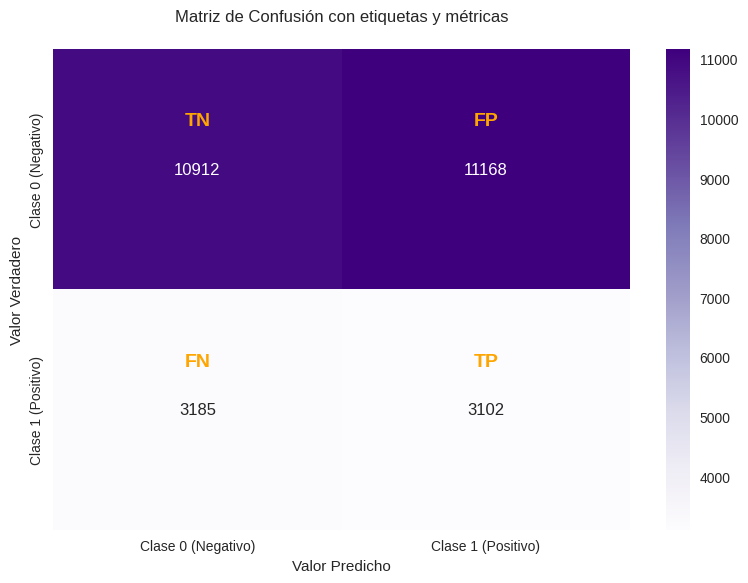

In [87]:
# Calcular matriz de confusión
cm = confusion_matrix(y_test, y_pred_dummy_base)

# Crear la figura
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Clase 0 (Negativo)', 'Clase 1 (Positivo)'],
            yticklabels=['Clase 0 (Negativo)', 'Clase 1 (Positivo)'])

plt.ylabel('Valor Verdadero')
plt.xlabel('Valor Predicho')
plt.title('Matriz de Confusión con etiquetas y métricas', pad=20)

# Anotaciones TN, FP, FN, TP (coordenadas ajustadas al centro de cada celda)
plt.text(0.5, 0.3, 'TN', ha='center', va='center', color='orange', fontsize=14, fontweight='bold')
plt.text(1.5, 0.3, 'FP', ha='center', va='center', color='orange', fontsize=14, fontweight='bold')
plt.text(0.5, 1.3, 'FN', ha='center', va='center', color='orange', fontsize=14, fontweight='bold')
plt.text(1.5, 1.3, 'TP', ha='center', va='center', color='orange', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [88]:
# Análisis básico
tn, fp, fn, tp = cm.ravel()
print(f"Falsos Positivos: {fp} - El modelo predijo '1' cuando era '0'")
print(f"Falsos Negativos: {fn} - El modelo predijo '0' cuando era '1'")

Falsos Positivos: 11168 - El modelo predijo '1' cuando era '0'
Falsos Negativos: 3185 - El modelo predijo '0' cuando era '1'


- Falsos Negativos (FN = 3.185): Son los días en que el modelo predijo 'No lloverá', pero sí llovió. En el contexto de predicción de lluvia, este es el error más costoso.

- Falsos Positivos (FP = 11.168): Son los días en que el modelo predijo 'Lloverá', pero no llovió. Este error es menos costoso que el FN, pero la alta cantidad de FPs contribuye a la baja Precision (Precision=0,22).

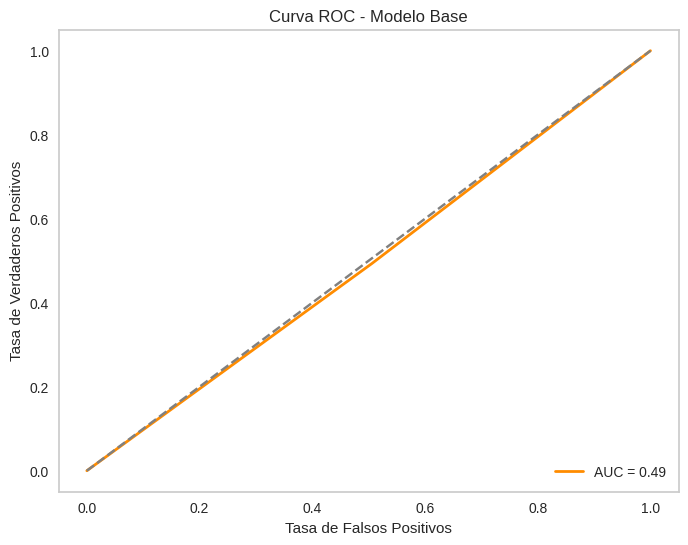

In [89]:
# Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_proba_dummy_base)
roc_auc = roc_auc_score(y_test, y_proba_dummy_base)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}', color='darkorange', lw=2)
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Modelo Base')
plt.legend(loc='lower right')
plt.grid()
plt.show()

In [90]:
# DUMMY CLASSIFIER: OPTIMIZACIÓN DE UMBRAL EN VALIDACIÓN

# Generar probabilidades en VALIDACIÓN
y_proba_dummy_valid = model_dummy_base.predict_proba(x_valid)[:, 1]

# Optimizar umbral en validación
thresholds = np.arange(0, 1.01, 0.01)
f1_scores_valid = [f1_score(y_valid, (y_proba_dummy_valid >= t).astype(int))
                   for t in thresholds]  # Usa y_valid

best_thresh = thresholds[np.argmax(f1_scores_valid)]
best_f1_valid = max(f1_scores_valid)

print(f"Mejor umbral (en validación): {best_thresh:.2f}")
print(f"F1-score en validación: {best_f1_valid:.2f}")

# Evaluar en TEST con umbral de validación
y_proba_dummy_test = model_dummy_base.predict_proba(x_test)[:, 1]
y_pred_dummy_test = (y_proba_dummy_test >= best_thresh).astype(int)

print(f"\nF1-score en TEST con umbral óptimo: {f1_score(y_test, y_pred_dummy_test):.2f}")

Mejor umbral (en validación): 0.00
F1-score en validación: 0.37

F1-score en TEST con umbral óptimo: 0.36


In [52]:
# Comparación de modelos
def evaluar_modelo(nombre, y_test, y_pred, y_proba):
    """
    Función para evaluar un modelo.
    :param nombre: Nombre del modelo.
    :param y_true: Etiquetas verdaderas.
    :param y_pred: Etiquetas predichas.
    :param y_proba: Probabilidades de pertenencia a la clase positiva.
    """
    print(f"\n=== {nombre} ===")
    print(classification_report(y_test, y_pred))
    print(f"ROC AUC  :  {roc_auc_score(y_test, y_proba):.2f}")

evaluar_modelo("Modelo Base", y_test, y_pred_dummy_base, y_proba_dummy_base)
evaluar_modelo("Regresión Logística", y_test, y_pred_tomek, y_proba)


=== Modelo Base ===
              precision    recall  f1-score   support

       False       0.77      0.49      0.60     22080
        True       0.22      0.49      0.30      6287

    accuracy                           0.49     28367
   macro avg       0.50      0.49      0.45     28367
weighted avg       0.65      0.49      0.54     28367

ROC AUC  :  0.49

=== Regresión Logística ===
              precision    recall  f1-score   support

       False       0.92      0.80      0.86     22080
        True       0.52      0.75      0.62      6287

    accuracy                           0.79     28367
   macro avg       0.72      0.78      0.74     28367
weighted avg       0.83      0.79      0.80     28367

ROC AUC  :  0.86


Como se puede visualizar arriba, el modelo base obtiene un accuracy del $49$% y un ROC AUC de $0,49$, lo que se traduce en que clasfica de forma aleatoria.

Por el contrario, el modelo de regresión logística aumenta el accuracy a $79$% y alcanza un ROC AUC de $0,86$, indicando que cuenta con una capacidad significativa para discriminar entre las clases.

Esto confirma que el modelo de regresión logística es mucho más efictivo que el modelo base para identificar las distintas clases.

# 5. Optimización de hiperparámetros

## Grid search / Random forest / Optuna

In [53]:
scores = ["precision", "recall"]

def print_dataframe(filtered_cv_results):
    ### print de los resultados de cross validation
    for mean_precision, std_precision, mean_recall, std_recall, params in zip(
        filtered_cv_results["mean_test_precision"],
        filtered_cv_results["std_test_precision"],
        filtered_cv_results["mean_test_recall"],
        filtered_cv_results["std_test_recall"],
        filtered_cv_results["params"],
    ):
        print(
            f"precision: {mean_precision:0.3f} (±{std_precision:0.03f}),"
            f" recall: {mean_recall:0.3f} (±{std_recall:0.03f}),"
            f" for {params}"
        )
    print()


def refit_strategy(cv_results):
    """Define la estrategia para seleccionar el mejor estimador.

    La estrategia definida aquí es filtrar todos los resultados por debajo de un umbral
    de precisión de 0.7, clasificar los restantes por recall y
    mantener todos los modelos dentro de una desviación estándar del mejor por recall.
    Una vez que estos modelos son seleccionados, podemos escoger el modelo más rápido para predecir.

    Parámetros
    ----------
    cv_results : dict of numpy (masked) ndarrays
        Resultados de la validación cruzada (CV) tal como los devuelve `GridSearchCV`.

    Devuelve
    -------
    best_index : int
        El índice del mejor estimador tal como aparece en `cv_results`.
    """
    # Imprimir la información sobre grid-search para los diferentes scores
    precision_threshold = 0.7

    cv_results_ = pd.DataFrame(cv_results)
    print("Todos los resultados de gridSearch:")
    print_dataframe(cv_results_)

    # Filtrar todos los resultados por debajo del umbral
    high_precision_cv_results = cv_results_[
        cv_results_["mean_test_precision"] > precision_threshold
    ]

    print(f"Modelos con una precisión mayor que {precision_threshold}:")
    print_dataframe(high_precision_cv_results)

    high_precision_cv_results = high_precision_cv_results[
        [
            "mean_score_time",
            "mean_test_recall",
            "std_test_recall",
            "mean_test_precision",
            "std_test_precision",
            "rank_test_recall",
            "rank_test_precision",
            "params",
        ]
    ]

    # Seleccionar los modelos más eficientes/de mayor rendimiento en términos de recall
    # (dentro de 1 sigma del mejor).
    best_recall_std = high_precision_cv_results["mean_test_recall"].std()
    best_recall = high_precision_cv_results["mean_test_recall"].max()
    best_recall_threshold = best_recall - best_recall_std

    high_recall_cv_results = high_precision_cv_results[
        high_precision_cv_results["mean_test_recall"] > best_recall_threshold
    ]
    print(
            "De los modelos de alta precisión seleccionados previamente, mantenemos todos los\n"
            "modelos dentro de una desviación estándar del modelo de recall más alto:"
    )
    print_dataframe(high_recall_cv_results)

    # De los mejores candidatos, seleccionamos el modelo más rápido para predecir
    fastest_top_recall_high_precision_index = high_recall_cv_results[
        "mean_score_time"
    ].idxmin()

    print(
        "\nEl modelo final seleccionado es el más rápido para predecir de entre el subconjunto\n"
        "de mejores modelos seleccionados previamente con base en la precisión y el recall.\n"
        "Su tiempo de scoring es:\n\n"
        f"{high_recall_cv_results.loc[fastest_top_recall_high_precision_index]}"
    )

    return fastest_top_recall_high_precision_index


La optimización de los siguientes hiperparámetros se realiza con el fin de mitigar el desbalance de clases (class_weight), controlar la complejidad del modelo (C) y asegurar que el algoritmo de optimización converja de manera eficiente (solver y max_iter). Al probar un rango logarítmico para C, buscamos el punto óptimo entre un modelo simple (alta regularización) y un modelo complejo (baja regularización).

In [54]:
# Grid

tuned_parameters = [
    {"class_weight": [None, 'balanced'], "C": [0.1, 1, 10, 100], "solver": ['newton-cg'], "max_iter": [200, 500]}
]

grid_search = GridSearchCV(
    LogisticRegression(), tuned_parameters, scoring=scores, refit=refit_strategy
)
grid_search.fit(x_train, y_train)



Todos los resultados de gridSearch:
precision: 0.802 (±0.005), recall: 0.787 (±0.025), for {'C': 0.1, 'class_weight': None, 'max_iter': 200, 'solver': 'newton-cg'}
precision: 0.802 (±0.005), recall: 0.787 (±0.025), for {'C': 0.1, 'class_weight': None, 'max_iter': 500, 'solver': 'newton-cg'}
precision: 0.802 (±0.005), recall: 0.787 (±0.025), for {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 200, 'solver': 'newton-cg'}
precision: 0.802 (±0.005), recall: 0.787 (±0.025), for {'C': 0.1, 'class_weight': 'balanced', 'max_iter': 500, 'solver': 'newton-cg'}
precision: 0.802 (±0.006), recall: 0.787 (±0.025), for {'C': 1, 'class_weight': None, 'max_iter': 200, 'solver': 'newton-cg'}
precision: 0.802 (±0.006), recall: 0.787 (±0.025), for {'C': 1, 'class_weight': None, 'max_iter': 500, 'solver': 'newton-cg'}
precision: 0.802 (±0.005), recall: 0.787 (±0.025), for {'C': 1, 'class_weight': 'balanced', 'max_iter': 200, 'solver': 'newton-cg'}
precision: 0.802 (±0.005), recall: 0.787 (±0.025), for {

GridSearchCV(estimator=LogisticRegression(),
             param_grid=[{'C': [0.1, 1, 10, 100],
                          'class_weight': [None, 'balanced'],
                          'max_iter': [200, 500], 'solver': ['newton-cg']}],
             refit=<function refit_strategy at 0x73ec3dfd7f60>,
             scoring=['precision', 'recall'])

In [55]:
grid_search.best_params_

{'C': 10, 'class_weight': 'balanced', 'max_iter': 200, 'solver': 'newton-cg'}

In [56]:
y_pred_grid = grid_search.predict(x_test)
print(classification_report(y_test, y_pred_grid))

              precision    recall  f1-score   support

       False       0.92      0.80      0.86     22080
        True       0.52      0.75      0.62      6287

    accuracy                           0.79     28367
   macro avg       0.72      0.78      0.74     28367
weighted avg       0.83      0.79      0.80     28367



In [57]:
param_dist = {
    'C': loguniform(1e-3, 1e3),
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'],
    'max_iter': [100, 250, 500],
    'class_weight': ['balanced'],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

random_search = RandomizedSearchCV(
    LogisticRegression(),
    param_distributions=param_dist,
    n_iter=10,
    cv=cv,
    scoring='f1',
    n_jobs=1,
    random_state=42,
    verbose=1
)

random_search.fit(x_train, y_train)

print("Mejor resultado - RandomizedSearch:")
print(random_search.best_params_)
print(f"F1 score: {random_search.best_score_:.2f}")

Fitting 5 folds for each of 10 candidates, totalling 50 fits
Mejor resultado - RandomizedSearch:
{'C': 51.41096648805744, 'class_weight': 'balanced', 'max_iter': 500, 'penalty': 'l2', 'solver': 'liblinear'}
F1 score: 0.80


In [58]:
random_search.fit(x_train, y_train)
best_random_params = random_search.best_params_
best_random_model = LogisticRegression(**best_random_params, random_state=0)
best_random_model.fit(x_train, y_train)

# Evaluar en conjunto test
y_pred_random = best_random_model.predict(x_test)
print(classification_report(y_test, y_pred_random))

Fitting 5 folds for each of 10 candidates, totalling 50 fits
              precision    recall  f1-score   support

       False       0.92      0.80      0.86     22080
        True       0.52      0.75      0.62      6287

    accuracy                           0.79     28367
   macro avg       0.72      0.78      0.74     28367
weighted avg       0.83      0.79      0.80     28367



In [59]:
def objective(trial):
    C = trial.suggest_float('C', 0.1, 100, log=True)
    solver = trial.suggest_categorical('solver', ['newton-cg', 'lbfgs', 'liblinear'])
    max_iter = trial.suggest_int('max_iter', 200, 1000)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    params = {
        'C': C,
        'solver': solver,
        'max_iter': max_iter,
        'class_weight': class_weight,
        'random_state': 0
    }

    # Entrenar con datos SMOTE
    model = LogisticRegression(**params)
    model.fit(x_train_resampled_tomek, y_train_resampled_tomek)

    # EVALUAR EN VALIDACIÓN
    y_pred_valid = model.predict(x_valid)
    f1 = f1_score(y_valid, y_pred_valid)

    return f1

# Optimización
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=100)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor F1-score en VALIDACIÓN:", study.best_value)

# Entrenar modelo final con mejores parámetros
best_model = LogisticRegression(**study.best_params)
best_model.fit(x_train_resampled_tomek, y_train_resampled_tomek)

# Evaluar en TEST
y_pred_test = best_model.predict(x_test)
print(f"\nF1-score en TEST: {f1_score(y_test, y_pred_test):.4f}")
print("✓ Hiperparámetros optimizados en validación, evaluados en test")

[I 2025-11-29 18:13:41,683] A new study created in memory with name: no-name-68ecf189-ae13-44c3-96b7-d105ecb8dd01
[I 2025-11-29 18:13:43,305] Trial 0 finished with value: 0.6204497654101279 and parameters: {'C': 85.30366453946428, 'solver': 'lbfgs', 'max_iter': 791, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6204497654101279.
[I 2025-11-29 18:13:45,180] Trial 1 finished with value: 0.6206729213846651 and parameters: {'C': 17.5345966631006, 'solver': 'newton-cg', 'max_iter': 689, 'class_weight': 'balanced'}. Best is trial 1 with value: 0.6206729213846651.
[I 2025-11-29 18:13:47,462] Trial 2 finished with value: 0.6206729213846651 and parameters: {'C': 0.8103762874101508, 'solver': 'liblinear', 'max_iter': 297, 'class_weight': None}. Best is trial 1 with value: 0.6206729213846651.
[I 2025-11-29 18:13:48,862] Trial 3 finished with value: 0.6204497654101279 and parameters: {'C': 17.802117108642545, 'solver': 'lbfgs', 'max_iter': 490, 'class_weight': None}. Best is trial 1 w

Mejores hiperparámetros: {'C': 0.9709863599346092, 'solver': 'lbfgs', 'max_iter': 572, 'class_weight': None}
Mejor F1-score en VALIDACIÓN: 0.6208960051754812

F1-score en TEST: 0.6171
✓ Hiperparámetros optimizados en validación, evaluados en test


In [60]:
study = optuna.create_study(direction='maximize')  # Maximizar F1 (en lugar de minimizar MSE)
study.optimize(objective, n_trials=10)
best_optuna_params = study.best_params
best_optuna_model = LogisticRegression(**best_optuna_params, random_state=0)
best_optuna_model.fit(x_train, y_train)

[I 2025-11-29 18:16:31,764] A new study created in memory with name: no-name-fc64318f-73e1-4316-b112-68694e575b8c
[I 2025-11-29 18:16:32,832] Trial 0 finished with value: 0.6206952303961196 and parameters: {'C': 0.135664388820201, 'solver': 'newton-cg', 'max_iter': 875, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.6206952303961196.
[I 2025-11-29 18:16:34,140] Trial 1 finished with value: 0.6205613524225512 and parameters: {'C': 4.127095073503868, 'solver': 'newton-cg', 'max_iter': 407, 'class_weight': None}. Best is trial 0 with value: 0.6206952303961196.
[I 2025-11-29 18:16:35,631] Trial 2 finished with value: 0.6207231254549866 and parameters: {'C': 8.647263512372927, 'solver': 'liblinear', 'max_iter': 569, 'class_weight': None}. Best is trial 2 with value: 0.6207231254549866.
[I 2025-11-29 18:16:37,003] Trial 3 finished with value: 0.6206673668901995 and parameters: {'C': 0.10100756018968864, 'solver': 'liblinear', 'max_iter': 648, 'class_weight': None}. Best is trial 

LogisticRegression(C=8.647263512372927, max_iter=569, random_state=0,
                   solver='liblinear')

In [61]:
# Evaluar en test set
y_pred_optuna = best_optuna_model.predict(x_test)
print(classification_report(y_test, y_pred_optuna))

              precision    recall  f1-score   support

       False       0.92      0.80      0.86     22080
        True       0.52      0.75      0.62      6287

    accuracy                           0.79     28367
   macro avg       0.72      0.78      0.74     28367
weighted avg       0.83      0.79      0.80     28367



In [62]:
best_optuna_params

{'C': 8.647263512372927,
 'solver': 'liblinear',
 'max_iter': 569,
 'class_weight': None}

In [63]:
grid_f1 = f1_score(y_test, grid_search.predict(x_test))
random_f1 = f1_score(y_test, y_pred_random)
optuna_f1 = f1_score(y_test, y_pred_optuna)

print("Grid Search F1:", grid_f1)
print("Random Search F1:", random_f1)
print("Optuna F1:", optuna_f1)


Grid Search F1: 0.6167469722620132
Random Search F1: 0.6167567215676063
Optuna F1: 0.6167567215676063


Lo que se puede decir de estos resultados es que, los tres métodos ofrecen un rendimiento casi idéntico en términos de la métrica F1, siendo esta métrica de alrededor del 61,6%.

# 6. Explicabilidad - SHAP

In [64]:
feature_names=x_test.columns.values
feature_names

array(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am',
       'Cloud3pm', 'Temp9am', 'Temp3pm', 'WindGustDir_sin',
       'WindGustDir_cos', 'WindDir9am_sin', 'WindDir9am_cos',
       'WindDir3pm_sin', 'WindDir3pm_cos', 'Region_1', 'Region_2',
       'Region_3', 'Region_4', 'Region_5', 'Region_6', 'Region_7',
       'Season_Otoño', 'Season_Primavera', 'Season_Verano',
       'RainToday_Yes'], dtype=object)

In [65]:
# Crea un objeto explainer SHAP
explainer = shap.LinearExplainer(model_tomek, x_train, feature_names=feature_names)
shap_values = explainer.shap_values(x_test)
idx=0

## Interpretabilidad local

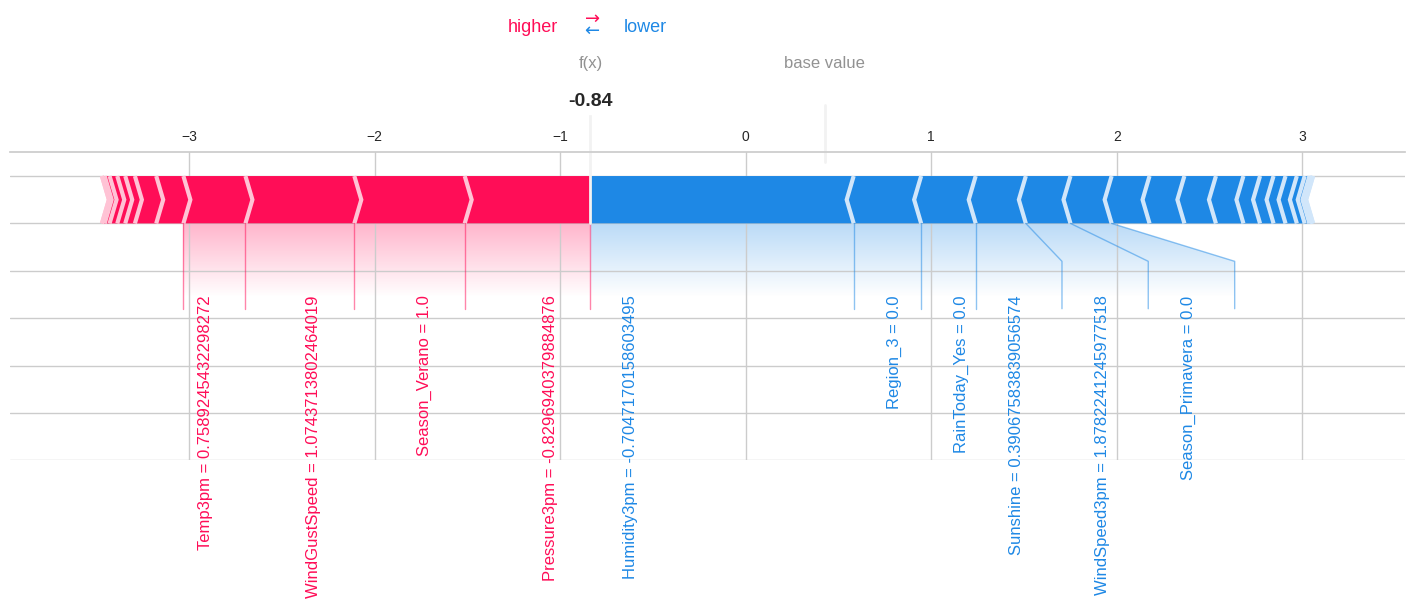

In [66]:
shap.force_plot(explainer.expected_value, shap_values[idx],
                x_test.iloc[idx], feature_names=feature_names,
                matplotlib=True, figsize=(18, 4), text_rotation=90)

Variables que disminuyen la predicción de lluvia (en rojo):
  - Season_Verano: Es el factor más fuerte que reduce la probabilidad de lluvia ($\approx -1.07$).
  - WindGustSpeed (Velocidad de Ráfaga de Viento): Fuerte contribución a "NO LLUVE" ($\approx -1.07$).
  - Pressure3pm (Presión a las 3 pm): También empuja significativamente hacia el tiempo seco ($\approx -0.83$).

Variables que aumentan la predicción de lluvia (en azul):
  - Cloud3pm: Una alta nubosidad en la tarde es un predictor natural de lluvia.
  - Pressure9am: La presión a las 9 am tiene un valor que el modelo asocia con una mayor probabilidad de precipitación.
  - WindSpeed3pm (Velocidad del Viento a las 3 pm): Este es el factor que más empuja a favor de la lluvia ($\approx +1.88$).
  - Region_3: Este factor contribuye fuertemente a la probabilidad de lluvia ($\approx +1.88$).

In [67]:
explanation = shap.Explanation(values=shap_values[idx],
                                base_values=explainer.expected_value,
                                feature_names=feature_names)

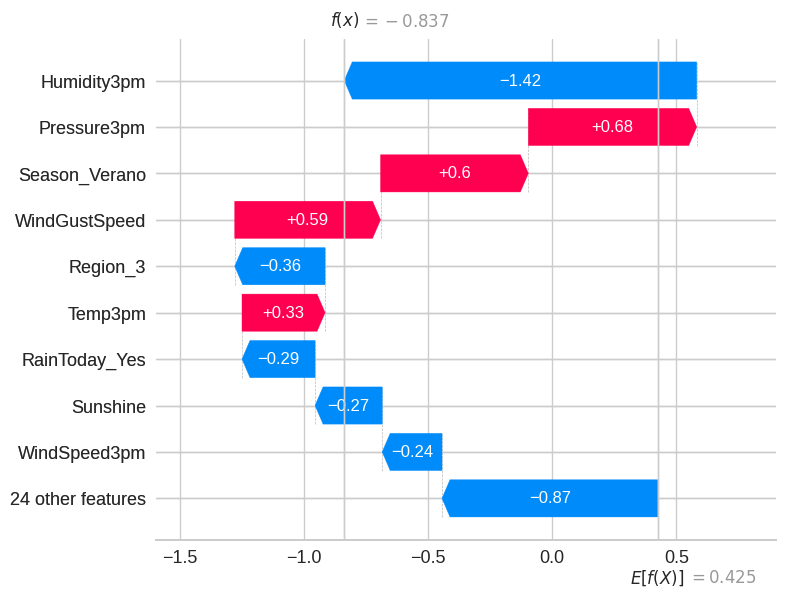

In [68]:
shap.plots.waterfall(explanation)

Variables que aumentan la predicción de lluvia:
  - Pressure3pm ($\mathbf{+1.16}$): Esta es la característica más fuerte que intenta contrarrestar la tendencia y empuja hacia "LLUVE".
  - WindGustSpeed ($\mathbf{+0.74}$): La velocidad de ráfaga de viento también es un fuerte impulsor hacia la predicción de lluvia.
  - Season_Verano ($\mathbf{+0.43}$): Curiosamente, estar en verano contribuye a una mayor probabilidad de lluvia en este día (podría ser una interacción o que el modelo interprete el valor específico de "Verano" de una manera particular para esta instancia).
  - Temp3pm ($\mathbf{+0.23}$): La temperatura en la tarde contribuye ligeramente a la predicción de lluvia.

Valores que disminuyen la predicción de lluvia:
  - Humidity3pm ($\mathbf{-1.24}$): Es el factor más fuerte que impulsa la predicción a "No Llueve".
  - Cloud3pm ($\mathbf{-0.53}$): La nubosidad a las 3 PM también contribuye significativamente a una predicción de tiempo seco.
  - Pressure9am ($\mathbf{-0.49}$): La presión de la mañana empuja la predicción hacia la sequía.
  - WindSpeed3pm ($\mathbf{-0.34}$): La velocidad del viento en la tarde contribuye ligeramente a "No Llueve".
  - Region_3 ($\mathbf{-0.28}$): El valor de la característica de la región también contribuye negativamente.

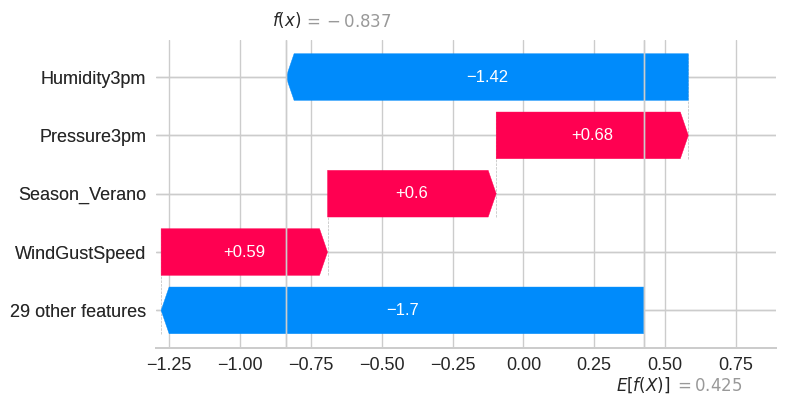

In [69]:
shap.plots.waterfall(explanation, max_display=5)

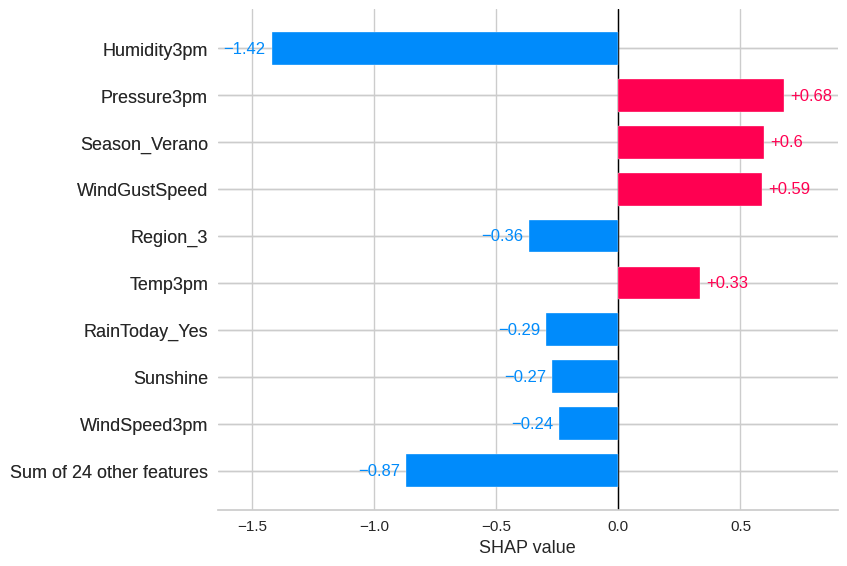

In [70]:
shap.plots.bar(explanation)

En resumen, Humidity3pm es la variable que más afecta negativamente a la predicción de lluvia, sugiriendo que al haber baja humedad a las 3pm, el modelo predice menos lluvia. Y, por el contrario, Pressure3pm es la variable que más afectó positivamente la predicción.

## Interpretabilidad global

In [71]:
explanation = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    feature_names=feature_names
)

In [72]:
print(type(shap_values))
print(np.array(shap_values).shape)
print(np.array(explainer.expected_value).shape)

<class 'numpy.ndarray'>
(28367, 33)
()


In [73]:
base_values = np.repeat(explainer.expected_value, shap_values.shape[0])

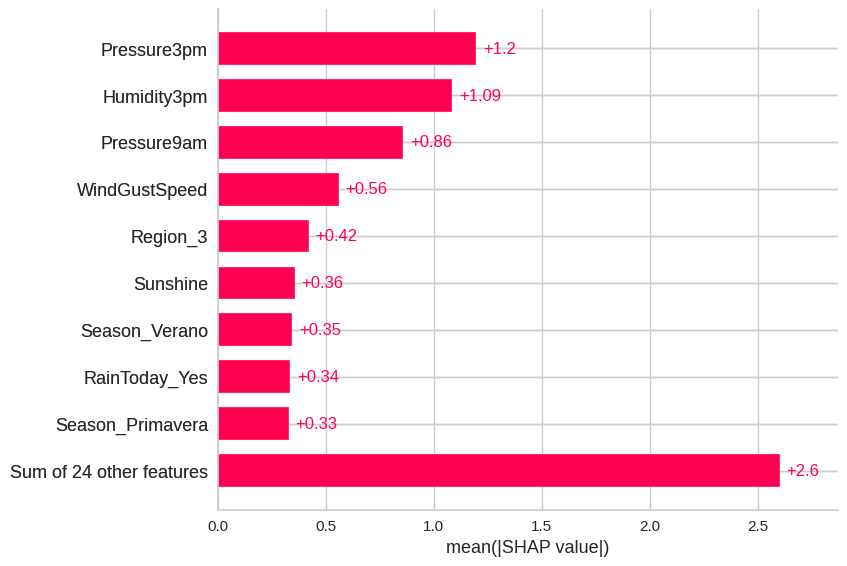

In [74]:
shap.plots.bar(explanation)

Las variables más destacadas en el gráfico de la importancia promedio de cada variable en todas las predicciones del modelo son:
  - Pressure3pm: es la más influyente, indica que la presión en la tarde tiene gran impacto en la predicción.
  - Humidity3pm: también aporta significativamente al resultado, por poco igualando la variable anterior.

In [75]:
# Valores SHAP: debe ser un array float64
shap_values_fixed = np.array(shap_values, dtype=np.float64)

# Para un explainer lineal que devuelve un solo array, el expected_value suele ser un escalar.
# Si fuera un array de 2 elementos ([0.5, 0.7]), seleccionamos el que corresponde a la Clase 1.
# Por simplicidad, tomaremos el primer elemento o el valor tal cual.
if isinstance(explainer.expected_value, np.ndarray) and explainer.expected_value.ndim > 0:
    base_value_fixed = explainer.expected_value[1] if len(explainer.expected_value) > 1 else explainer.expected_value[0]
else:
    base_value_fixed = explainer.expected_value

# base_value_fixed debe ser float
base_value_fixed = float(base_value_fixed)

In [76]:
# Explanation con los valores corregidos
explanation_fixed = shap.Explanation(
    values=shap_values_fixed,
    base_values=base_value_fixed,
    feature_names=feature_names
)

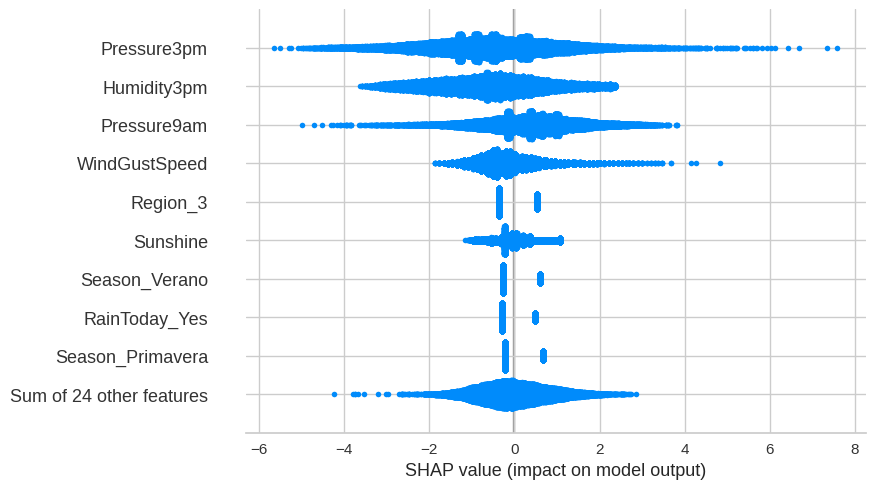

In [77]:
# Graficar el beeswarm
shap.plots.beeswarm(explanation_fixed)

A partir del gráfico anterior, podemos decir que el modelo está principalmente influenciado por la presión, la humedad y el viento.

# 7. AutoML

In [78]:
df_auto_ml = df.copy()

In [79]:
setup(data=df_auto_ml,
      target='RainTomorrow',
      train_size=0.8,
      normalize=True,
      session_id=42)

,Description,Value
0,Session id,42
1,Target,RainTomorrow
2,Target type,Binary
3,Target mapping,"No: 0, Yes: 1"
4,Original data shape,"(141834, 23)"
5,Transformed data shape,"(141834, 71)"
6,Transformed train set shape,"(113467, 71)"
7,Transformed test set shape,"(28367, 71)"
8,Numeric features,17
9,Categorical features,5


Interpretación

- Transformaciones realizadas
  - Los datos se expandieron a 71 columnas por el procesamiento
  - Conjunto de entrenamiento: 113.467 filas, 71 columnas
  - Conjunto de prueba: 28.367 filas, 71 columnas

- Features
  - 17 variables numéricas
  - 5 variables categóricas
  - 60.2% de las filas tenían valores faltantes

- Preprocesamiento implementado
  - Imputación numérica: media
  - Imputación categórica: moda
  - Normalización: con z-score (media 0, desviación estándar 1)
  - Balanceo de clases: activado con SMOTE (fix_imbalance=True)

- Validación cruzada
  - Tipo de validación: StratifiedKFold con 10 folds

In [80]:
best_model = compare_models()
print(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.8572,0.8877,0.8572,0.8493,0.8484,0.5440,0.5553,109.9310
rf,Random Forest Classifier,0.8559,0.8851,0.8559,0.8484,0.8443,0.5278,0.5456,6.6980
et,Extra Trees Classifier,0.8533,0.8841,0.8533,0.8457,0.8402,0.5135,0.5345,7.8270
gbc,Gradient Boosting Classifier,0.8490,0.8739,0.8490,0.8398,0.8380,0.5102,0.5245,9.5970
lr,Logistic Regression,0.8435,0.8664,0.8435,0.8333,0.8326,0.4944,0.5073,1.1200
lda,Linear Discriminant Analysis,0.8432,0.8645,0.8432,0.8331,0.8335,0.4995,0.5097,1.2290
ada,Ada Boost Classifier,0.8429,0.8632,0.8429,0.8325,0.8319,0.4924,0.5052,2.7280
ridge,Ridge Classifier,0.8414,0.8645,0.8414,0.8314,0.8257,0.4672,0.4906,0.5940
svm,SVM - Linear Kernel,0.8379,0.8543,0.8379,0.8273,0.8270,0.4787,0.4908,0.9660
knn,K Neighbors Classifier,0.8052,0.7508,0.8052,0.7835,0.7817,0.3284,0.3521,6.0180


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=42, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


In [81]:
predictions = predict_model(best_model)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8563,0.8880,0.8563,0.8483,0.8467,0.5381,0.5507


In [82]:
y_pred_auto_ml = predictions['prediction_label']
y_test_automl = predictions['RainTomorrow']

f1_automl = f1_score(y_test_automl, y_pred_auto_ml, pos_label='Yes')
print(f"F1-score con AutoML: {f1_automl:.2f}")

F1-score con AutoML: 0.62


Comparación de modelos

1. Desempeño Predictivo y Capacidad Discriminatoria

Los resultados demuestran que los algoritmos basados en técnicas de ensemble y boosting dominan el rendimiento. El modelo Light Gradient Boosting Machine (lightgbm) se estableció como el de mejor desempeño, registrando la $\mathbf{Accuracy}$ más alta ($\mathbf{85.72\%}$) y el $\mathbf{AUC}$ más favorable ($\mathbf{0.8877}$). Esta métrica de AUC valida la sólida capacidad discriminatoria del modelo para diferenciar entre las clases positiva y negativa.

2. Eficiencia Computacional y Escalabilidad

La eficiencia de cálculo fue un factor crítico. El análisis reveló una marcada diferencia en el tiempo de entrenamiento (TT):
  - LightGBM no solo lideró en rendimiento, sino que también demostró una eficiencia superior, completando su entrenamiento en solo $\mathbf{6.16}$ segundos.
  - En contraste, otros modelos de alto rendimiento, como Random Forest, requirieron tiempos de procesamiento significativamente mayores (cercanos a los $\mathbf{94}$ segundos), lo que los hace menos escalables y eficientes en la iteración del proyecto.

3. Conclusión

El modelo Light Gradient Boosting Machine ($\mathbf{lightgbm}$) es formalmente seleccionado como el modelo candidato principal. Su elección se fundamenta
en su capacidad para ofrecer el rendimiento predictivo más alto (liderando en $\mathbf{Accuracy}$ y $\mathbf{AUC}$) mientras mantiene la máxima eficiencia computacional de su grupo.

# 8. Red neuronal

## Red neuronal

Creamos una clase para generar la red neuronal. Luego, utilizamos Optuna para poder obtener los mejores parámetros posibles para la misma.

In [83]:
class NeuralNetworkBinary:
    def __init__(self, epochs=100, batch_size=32, learning_rate=0.001,
                    dropout_rate=0.3, use_class_weight=True):
        """
        Red Neuronal para clasificación binaria con soporte para datos desbalanceados (imbalanced data)

        Parámetros:
        -----------
        epochs : int, por defecto=100
            Número de épocas de entrenamiento
        batch_size : int, por defecto=32
            Tamaño del lote (batch) para el entrenamiento
        learning_rate : float, por defecto=0.001
            Tasa de aprendizaje (learning rate) para el optimizador Adam
        dropout_rate : float, por defecto=0.3
            Tasa de Dropout para la regularización (0 = sin dropout, 0.5 = 50% de dropout)
        use_class_weight : bool, por defecto=True
            Si se deben aplicar pesos de clase (class weights) para manejar datos desbalanceados
        """
        self.epochs = epochs
        self.batch_size = batch_size
        self.learning_rate = learning_rate
        self.dropout_rate = dropout_rate
        self.use_class_weight = use_class_weight
        self.model = None
        self.class_weight = None
        self.threshold = 0.5

    def build_model(self, input_shape):
        """
        Construye una arquitectura de red neuronal optimizada para la clasificación binaria con 33 características (features)

        Arquitectura:
        - Capa de entrada (33 características)
        - Capa oculta 1: 64 neuronas con ReLU + Dropout
        - Capa oculta 2: 32 neuronas con ReLU + Dropout
        - Capa oculta 3: 16 neuronas con ReLU
        - Capa de salida: 1 neurona con activación Sigmoide (sigmoid activation)

        Parámetros:
        -----------
        input_shape : int
            Número de características de entrada (33 para el dataset del clima)
        """
        model = tf.keras.models.Sequential([
            tf.keras.layers.Dense(64, activation='relu', input_shape=(input_shape,)),
            tf.keras.layers.Dropout(self.dropout_rate),
            tf.keras.layers.Dense(32, activation='relu'),
            tf.keras.layers.Dropout(self.dropout_rate),
            tf.keras.layers.Dense(16, activation='relu'),
            tf.keras.layers.Dense(1, activation='sigmoid')  # Clasificaión binaria
        ])

        optimizer = tf.keras.optimizers.Adam(learning_rate=self.learning_rate)

        # Entropía cruzada binaria para clasificación binaria
        # Rastrea múltiples métricas relevantes para clasificación desbalanceada
        model.compile(
            optimizer=optimizer,
            loss='binary_crossentropy',
            metrics=[
                'accuracy',
                tf.keras.metrics.Precision(name='precision'),
                tf.keras.metrics.Recall(name='recall'),
                tf.keras.metrics.AUC(name='auc')
            ]
        )

        self.model = model
        print("Modelo construido exitosamente!")
        self.model.summary()

    def calculate_class_weight(self, y_train):
        """
        Calcula los pesos de clase para un dataset desbalanceado
        Da más importancia a la clase minoritaria (lluvia en este caso)

        Parámetros:
        -----------
        y_train : array-like
            Etiquetas de entrenamiento (0 o 1)

        Retorna:
        --------
        dict : Pesos de clase {0: weight_0, 1: weight_1}
        """
        classes = np.unique(y_train)
        weights = compute_class_weight('balanced', classes=classes, y=y_train)
        self.class_weight = dict(zip(classes, weights))
        return self.class_weight

    def train(self, X_train, y_train, X_valid, y_valid):
        """
        Entrena el modelo con pesos de clase opcionales y detención temprana (early stopping)

        Parámetros:
        -----------
        X_train : array-like, shape (n_muestras, 33)
            Características de entrenamiento (ya escaladas)
        y_train : array-like, shape (n_muestras,)
            Etiquetas de entrenamiento (0 o 1, NO codificadas 'one-hot')
        X_valid : array-like, shape (n_muestras, 33)
            Características de validación
        y_valid : array-like, shape (n_muestras,)
            Etiquetas de validación

        Retorna:
        --------
        tupla : (training_loss_history, validation_loss_history)
        """
        # Cacula pesos de clase si es necesario
        class_weight = None
        if self.use_class_weight:
            class_weight = self.calculate_class_weight(y_train)
            print(f"Usando pesos de clase: {class_weight}")

        # Early stopping para prevenir el sobreajuste
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor='val_loss',
            patience=10,
            restore_best_weights=True,
            verbose=1
        )

        # Opcional: Reducción de la tasa de aprendizaje en plateau
        reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=5,
            min_lr=1e-7,
            verbose=1
        )

        print("\nComenzando entrenamiento...")
        history = self.model.fit(
            X_train, y_train,
            validation_data=(X_valid, y_valid),
            epochs=self.epochs,
            batch_size=self.batch_size,
            class_weight=class_weight,
            callbacks=[early_stopping, reduce_lr],
            verbose=1
        )

        print("\nEntrenamiento completado!")
        return history.history['loss'], history.history['val_loss']

    def evaluate(self, X_test, y_test):
        """
        Evalúa el modelo en el conjunto de prueba con métricas exhaustivas

        Parámetros:
        -----------
        X_test : array-like
            Características (features) de prueba
        y_test : array-like
            Etiquetas (labels) de prueba
        """
        print("\n" + "="*50)
        print("EVALUACIÓN DEL CONJUNTO DE PRUEBA")
        print("="*50)

        results = self.model.evaluate(X_test, y_test, verbose=0)

        print(f"Test Loss:      {results[0]:.4f}")
        print(f"Test Accuracy:  {results[1]:.4f}")
        print(f"Test Precision: {results[2]:.4f}")
        print(f"Test Recall:    {results[3]:.4f}")
        print(f"Test AUC:       {results[4]:.4f}")

        # Calcula F1-score manualmente
        precision = results[2]
        recall = results[3]
        f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
        print(f"Test F1-Score:  {f1:.4f}")
        print("="*50 + "\n")

        return results

    def predict_proba(self, X_new):
        """
        Obtener predicciones de probabilidad (valores entre 0 y 1)

        Parámetros:
        X_new : array-like
            Nuevos datos para predecir

        Retorna:
        array : Probabilidades de la clase 1 (lluvia)
        """
        return self.model.predict(X_new, verbose=0)

    def predict(self, X_new, threshold=None):
        """
        Realiza predicciones binarias utilizando un umbral especificado

        Parámetros:
        -----------
        X_new : array-like
            Nuevos datos para predecir
        threshold : float, opcional
            Umbral de decisión (por defecto: usar self.threshold)

        Retorna:
        --------
        array : Predicciones binarias (0 o 1)
        """
        if threshold is None:
            threshold = self.threshold

        probabilities = self.predict_proba(X_new)
        return (probabilities >= threshold).astype(int)

    def optimize_threshold(self, X_valid, y_valid, metric='f1'):
        """
        Encuentra el umbral de decisión óptimo para maximizar la métrica especificada
        Similar a la optimización del umbral en la regresión logística

        Parámetros:
        -----------
        X_valid : array-like
            Características de validación
        y_valid : array-like
            Etiquetas de validación
        metric : str, default='f1'
            Métrica a optimizar ('f1', 'precision', 'recall')

        Retorna:
        --------
        tuple : (best_threshold, best_metric_value)
        """

        probabilities = self.predict_proba(X_valid).flatten()

        best_threshold = 0.5
        best_score = 0

        print(f"\nOptimizando umbral para {metric}...")
        print("-" * 50)

        # Prueba de umbrales de 0.3 a 0.7
        for threshold in np.arange(0.3, 0.7, 0.01):
            predictions = (probabilities >= threshold).astype(int)

            if metric == 'f1':
                score = f1_score(y_valid, predictions)
            elif metric == 'precision':
                score = precision_score(y_valid, predictions)
            elif metric == 'recall':
                score = recall_score(y_valid, predictions)
            else:
                raise ValueError("la métrica debe ser 'f1', 'precision', o 'recall'")

            if score > best_score:
                best_score = score
                best_threshold = threshold

        self.threshold = best_threshold
        print(f"Umbral óptimo: {best_threshold:.4f}")
        print(f"Mejor {metric} score: {best_score:.4f}")
        print("-" * 50 + "\n")

        return best_threshold, best_score

    def plot_history(self, train_loss, val_loss):
        """
        Grafica las curvas de pérdida de entrenamiento y validación

        Parámetros:
        -----------
        train_loss : list
            Historial de pérdida de entrenamiento
        val_loss : list
            Historial de pérdida de validación
        """

        plt.figure(figsize=(10, 6))
        plt.plot(train_loss, label='Training Loss', linewidth=2)
        plt.plot(val_loss, label='Validation Loss', linewidth=2)
        plt.xlabel('Epoch', fontsize=12)
        plt.ylabel('Loss', fontsize=12)
        plt.title('Training and Validation Loss', fontsize=14)
        plt.legend(fontsize=11)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    def confusion_matrix_plot(self, X_test, y_test, threshold=None):
        """
        Grafica la matriz de confusión

        Parámetros:
        -----------
        X_test : array-like
            Características (features) de prueba
        y_test : array-like
            Etiquetas (labels) de prueba
        threshold : float, opcional
            Umbral de decisión
        """

        predictions = self.predict(X_test, threshold=threshold)
        cm = confusion_matrix(y_test, predictions)

        disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                    display_labels=['No llueve', 'Llueve'])
        disp.plot(cmap='Blues', values_format='d')
        plt.title(f'Matriz de confusión (umbral={threshold or self.threshold:.2f})')
        plt.tight_layout()
        plt.show()

In [93]:
x_train_save, x_valid, y_train_save, y_valid = train_test_split(x_train_save, y_train_save, test_size=0.2, random_state=0)


In [84]:
nn = NeuralNetworkBinary(
    epochs=200,
    batch_size=64,
    learning_rate=0.001,
    dropout_rate=0.3,
    use_class_weight=False
)

nn.build_model(input_shape=33)
train_loss, val_loss = nn.train(x_train_save, y_train_save, x_valid, y_valid)


Modelo construido exitosamente!


2025-11-29 18:42:07.374390: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         2,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,801 (18.75 KB)

 Trainable params: 4,801 (18.75 KB)

 Non-trainable params: 0 (0.00 B)


Comenzando entrenamiento...
Epoch 1/200
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.7878 - auc: 0.8692 - loss: 0.4524 - precision: 0.7772 - recall: 0.8066 - val_accuracy: 0.8077 - val_auc: 0.8930 - val_loss: 0.4114 - val_precision: 0.8077 - val_recall: 0.8089 - learning_rate: 0.0010
Epoch 2/200
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8092 - auc: 0.8910 - loss: 0.4158 - precision: 0.8050 - recall: 0.8157 - val_accuracy: 0.8141 - val_auc: 0.9012 - val_loss: 0.3991 - val_precision: 0.8277 - val_recall: 0.7944 - learning_rate: 0.0010
Epoch 3/200
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8154 - auc: 0.8982 - loss: 0.4025 - precision: 0.8134 - recall: 0.8182 - val_accuracy: 0.8186 - val_auc: 0.9055 - val_loss: 0.3907 - val_precision: 0.8380 - val_recall: 0.7911 - learning_rate: 0.0010
Epoch 4/200
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8189 - auc: 0.9018 - loss: 0.3959 - precision: 0.8188 - recall: 0.8187 - val_accuracy: 0.8231 -

In [85]:
optimal_threshold, best_f1 = nn.optimize_threshold(x_valid, y_valid)

nn.evaluate(x_test, y_test)

predictions = nn.predict(x_test, threshold=optimal_threshold)

probabilities = nn.predict_proba(x_test)


Optimizando umbral para f1...
--------------------------------------------------
Umbral óptimo: 0.3900
Mejor f1 score: 0.8467
--------------------------------------------------


EVALUACIÓN DEL CONJUNTO DE PRUEBA
Test Loss:      0.3863
Test Accuracy:  0.8237
Test Precision: 0.5804
Test Recall:    0.7387
Test AUC:       0.8837
Test F1-Score:  0.6501



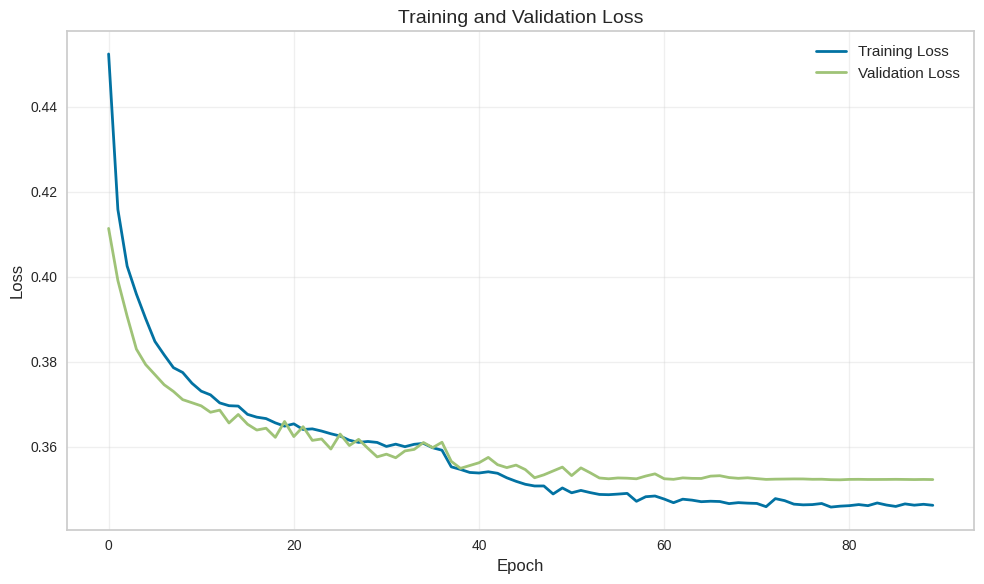

In [86]:
nn.plot_history(train_loss, val_loss)

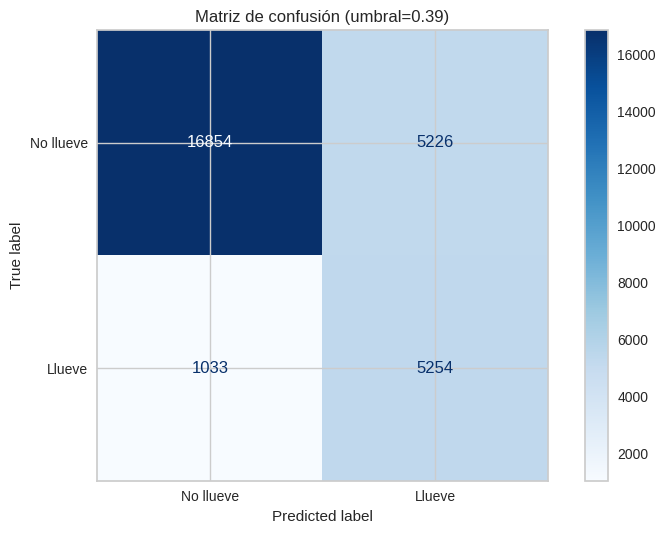

In [87]:
nn.confusion_matrix_plot(x_test,y_test)

In [91]:
def f1_score_nn(y_true, y_pred):
    y_pred = tf.round(y_pred)

    tp = tf.reduce_sum(tf.cast(y_true * y_pred, 'float32'))
    predicted_positives = tf.reduce_sum(tf.cast(y_pred, 'float32'))
    possible_positives = tf.reduce_sum(tf.cast(y_true, 'float32'))

    precision = tp / (predicted_positives + tf.keras.backend.epsilon())
    recall = tp / (possible_positives + tf.keras.backend.epsilon())

    return 2 * ((precision * recall) / (precision + recall + tf.keras.backend.epsilon()))

In [89]:
def objective(trial):

    num_layers = trial.suggest_int('num_layers', 1, 5)
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.6)
    lr = trial.suggest_float('learning_rate', 1e-5, 1e-2)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128, 256])
    neurons_layer1 = trial.suggest_int('neurons_layer1', 16, 128, step=16)
    neurons_layer2 = trial.suggest_int('neurons_layer2', 8, 64, step=8)
    l2_reg = trial.suggest_loguniform('l2_reg', 1e-6, 1e-2)

    model = Sequential()
    model.add(tf.keras.layers.Dense(neurons_layer1, activation='relu',
                                    input_shape=(x_train_save.shape[1],),
                                    kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))

    for _ in range(num_layers - 1):
        model.add(Dense(neurons_layer2, activation='relu',
            kernel_regularizer=tf.keras.regularizers.l2(l2_reg)))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))  # Clasificación binaria

    optimizer = tf.keras.optimizers.Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=[f1_score_nn])

    model.fit(x_train_save, y_train_save, validation_data=(x_valid, y_valid),
                epochs=20, batch_size=batch_size, verbose=0)

    y_pred = (model.predict(x_valid) > 0.5).astype(int)
    return f1_score(y_valid, y_pred)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor f1-score en validación:", study.best_value)

[I 2025-11-29 18:47:44,033] A new study created in memory with name: no-name-9c524174-301c-4df6-add7-01d9b8fc8adf


878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 659us/step


[I 2025-11-29 18:48:02,964] Trial 0 finished with value: 0.8347056919923771 and parameters: {'num_layers': 4, 'dropout_rate': 0.20132464837558559, 'learning_rate': 0.00255331014736038, 'batch_size': 256, 'neurons_layer1': 64, 'neurons_layer2': 8, 'l2_reg': 3.978711733111229e-05}. Best is trial 0 with value: 0.8347056919923771.


878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 660us/step


[I 2025-11-29 18:48:23,826] Trial 1 finished with value: 0.8311944024471714 and parameters: {'num_layers': 5, 'dropout_rate': 0.23642344877022295, 'learning_rate': 0.0009396784403977958, 'batch_size': 256, 'neurons_layer1': 32, 'neurons_layer2': 16, 'l2_reg': 3.001933679130518e-05}. Best is trial 0 with value: 0.8347056919923771.


...

878/878 ━━━━━━━━━━━━━━━━━━━━ 0s 506us/step


[I 2025-11-29 19:18:46,661] Trial 48 finished with value: 0.8551661799471562 and parameters: {'num_layers': 5, 'dropout_rate': 0.24713642813021236, 'learning_rate': 0.0030678005115749975, 'batch_size': 256, 'neurons_layer1': 96, 'neurons_layer2': 40, 'l2_reg': 2.207697667181028e-06}. Best is trial 33 with value: 0.8553150287018466.


878/878 ━━━━━━━━━━━━━━━━━━━━ 1s 523us/step


[I 2025-11-29 19:20:23,614] Trial 49 finished with value: 0.8448366794416511 and parameters: {'num_layers': 5, 'dropout_rate': 0.23337077154554667, 'learning_rate': 0.0031252793782506993, 'batch_size': 32, 'neurons_layer1': 80, 'neurons_layer2': 48, 'l2_reg': 5.1762657701581775e-06}. Best is trial 33 with value: 0.8553150287018466.


Mejores hiperparámetros: {'num_layers': 5, 'dropout_rate': 0.10652918080452209, 'learning_rate': 0.003367990957621296, 'batch_size': 256, 'neurons_layer1': 112, 'neurons_layer2': 32, 'l2_reg': 1.7863345060243164e-06}
Mejor f1-score en validación: 0.8553150287018466


Epoch 1/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - f1_score_nn: 0.8073 - loss: 0.4202 - val_f1_score_nn: 0.8272 - val_loss: 0.3855
Epoch 2/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score_nn: 0.8255 - loss: 0.3827 - val_f1_score_nn: 0.8268 - val_loss: 0.3782
Epoch 3/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score_nn: 0.8330 - loss: 0.3692 - val_f1_score_nn: 0.8349 - val_loss: 0.3671
Epoch 4/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score_nn: 0.8382 - loss: 0.3612 - val_f1_score_nn: 0.8340 - val_loss: 0.3680
Epoch 5/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score_nn: 0.8398 - loss: 0.3555 - val_f1_score_nn: 0.8264 - val_loss: 0.3658
Epoch 6/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score_nn: 0.8439 - loss: 0.3502 - val_f1_score_nn: 0.8439 - val_loss: 0.3533
Epoch 7/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - f1_score_nn: 0.8474 - loss: 0.3449 - val_f1_score_nn: 0.8428 - val_loss: 0.3487
Epoch 8/100
439/439 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - 

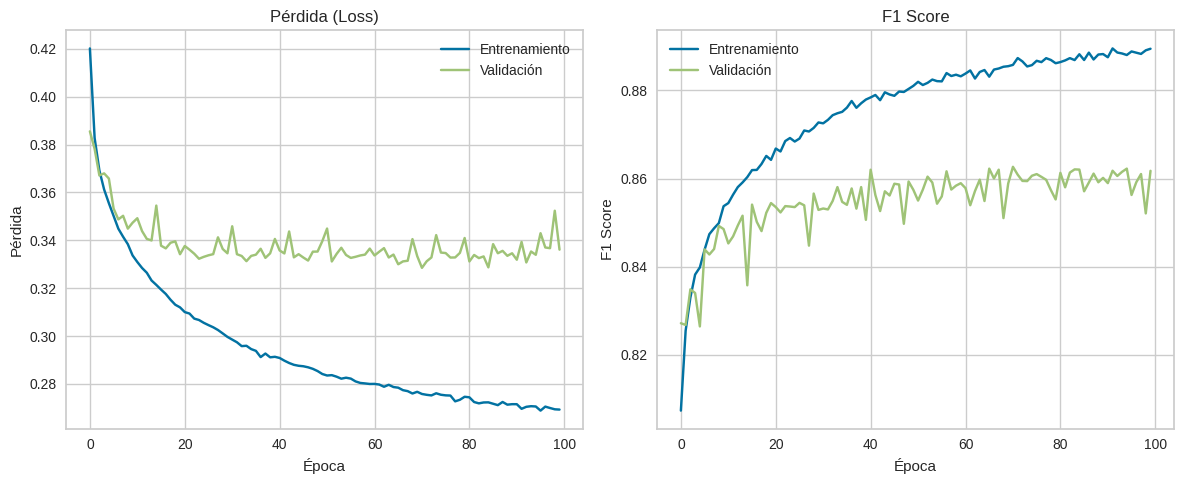

In [90]:
params = study.best_params
model_optuna = Sequential()

model_optuna.add(Dense(
    params['neurons_layer1'],
    activation='relu',
    input_shape=(x_train_save.shape[1],),
    kernel_regularizer=tf.keras.regularizers.l2(params['l2_reg'])
))

for _ in range(params['num_layers'] - 1):
    model_optuna.add(Dense(
        params['neurons_layer2'],
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(params['l2_reg'])
    ))
    if params['dropout_rate'] > 0.0:
        model_optuna.add(tf.keras.layers.Dropout(params['dropout_rate']))

model_optuna.add(Dense(1, activation='sigmoid'))

model_optuna.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=params['learning_rate']),
    loss='binary_crossentropy',
    metrics=[f1_score_nn]
)

history = model_optuna.fit(
    x_train_save, y_train_save,
    validation_data=(x_valid, y_valid),
    epochs=100,
    batch_size=params['batch_size'],
    verbose=1
)

final_f1_score = model_optuna.evaluate(x_test, y_test, verbose=1)[1]
print("\n--- Modelo Final ---")
print(f"Precisión en el conjunto de prueba: {final_f1_score:.4f}")

plt.figure(figsize=(12, 5))

# Gráfico de la pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico del F1 Score
plt.subplot(1, 2, 2)
plt.plot(history.history['f1_score_nn'], label='Entrenamiento')
plt.plot(history.history['val_f1_score_nn'], label='Validación')
plt.title('F1 Score')
plt.xlabel('Época')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [91]:
y_pred_prob = model_optuna.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)

# Usar f1_score de sklearn (no f1_score_nn que es solo para Keras)

f1_best_test = f1_score(y_test, y_pred)
print(f"F1-score en el conjunto de prueba: {f1_best_test:.4f}")

887/887 ━━━━━━━━━━━━━━━━━━━━ 1s 564us/step
F1-score en el conjunto de prueba: 0.6330


En una etapa preliminar trabajamos con un modelo denominado `model_optuna`, donde se observaba cierto sobreajuste: la pérdida de entrenamiento seguía disminuyendo mientras que la de validación mostraba oscilaciones mayores y no mejoraba al mismo ritmo. Siguiendo la recomendación del docente, aumentamos el parámetro dropout rate con el objetivo de reducir este overfitting.

El incremento del dropout ayudó a regularizar la red, logrando que las curvas de pérdida de entrenamiento y validación se acerquen entre sí y mostrando un comportamiento más estable. En consecuencia, el modelo final presenta una mejor capacidad de generalización que el modelo preliminar.

Epoch 1/100
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_score_nn: 0.7907 - loss: 0.4624 - val_f1_score_nn: 0.8128 - val_loss: 0.4012
Epoch 2/100
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_score_nn: 0.8140 - loss: 0.4157 - val_f1_score_nn: 0.8232 - val_loss: 0.3884
Epoch 3/100
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_score_nn: 0.8197 - loss: 0.4042 - val_f1_score_nn: 0.8271 - val_loss: 0.3797
Epoch 4/100
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_score_nn: 0.8244 - loss: 0.3956 - val_f1_score_nn: 0.8286 - val_loss: 0.3745
Epoch 5/100
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - f1_score_nn: 0.8268 - loss: 0.3914 - val_f1_score_nn: 0.8248 - val_loss: 0.3755
Epoch 6/100
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - f1_score_nn: 0.8280 - loss: 0.3884 - val_f1_score_nn: 0.8293 - val_loss: 0.3702
Epoch 7/100
1755/1755 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - f1_score_nn: 0.8313 - loss: 0.3849 - val_f1_score_nn: 0.8281 - val_loss: 0.3745
Epoch 8/100
1755/1755 ━━━━━━━━━━━━━━━━━━━

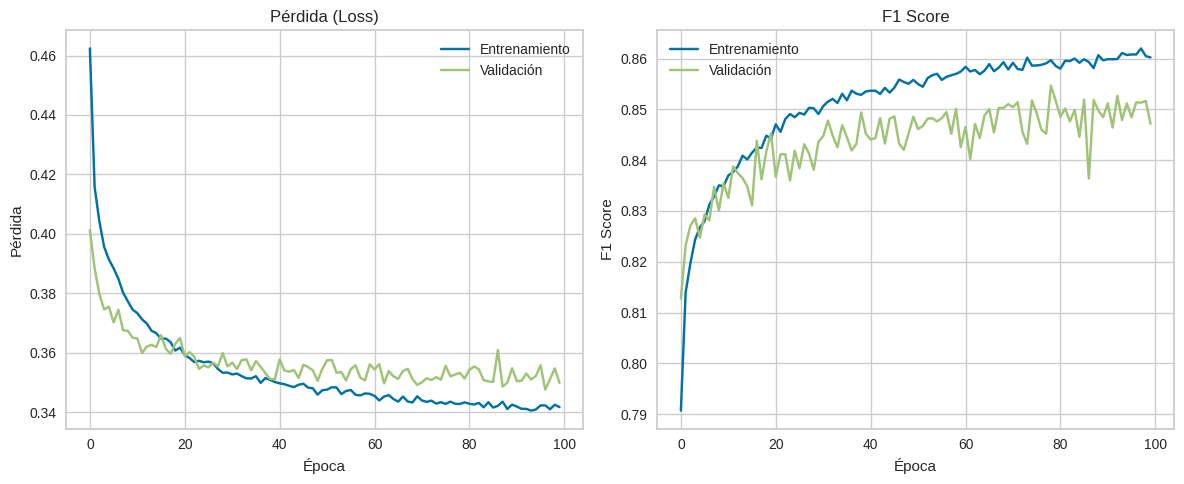

In [94]:
model_to_test = Sequential()

# Mejores hiperparámetros:
# {'num_layers': 4,
# 'dropout_rate': 0.3863189372266675,
# 'learning_rate': 0.0016234063075786787,
# 'batch_size': 64,
# 'neurons_layer1': 96,
# 'neurons_layer2': 64,
# 'l2_reg': 1.5488631311164757e-05}

model_to_test.add(Dense(
    96,
    activation='relu',
    input_shape=(x_train_save.shape[1],),
    kernel_regularizer=tf.keras.regularizers.l2(1.5488631311164757e-05)
))

for _ in range(3):
    model_to_test.add(Dense(
        64,
        activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(1.5488631311164757e-05)
    ))
    model_to_test.add(tf.keras.layers.Dropout(0.6))

model_to_test.add(Dense(1, activation='sigmoid'))

model_to_test.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0016234063075786787),
    loss='binary_crossentropy',
    metrics=[f1_score_nn]
)

history = model_to_test.fit(
    x_train_save, y_train_save,
    validation_data=(x_valid, y_valid),
    epochs=100,
    batch_size=64,
    verbose=1
)

final_f1_score = model_to_test.evaluate(x_test, y_test, verbose=1)[1]
print("\n--- Modelo Final ---")
print(f"Precisión en el conjunto de prueba: {final_f1_score:.4f}")

plt.figure(figsize=(12, 5))

# Gráfico de la pérdida
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida (Loss)')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid(True)

# Gráfico del F1 Score
plt.subplot(1, 2, 2)
plt.plot(history.history['f1_score_nn'], label='Entrenamiento')
plt.plot(history.history['val_f1_score_nn'], label='Validación')
plt.title('F1 Score')
plt.xlabel('Época')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

In [95]:
y_pred_prob = model_to_test.predict(x_test)
y_pred = (y_pred_prob > 0.5).astype(int)

f1_best_test = f1_score(y_test, y_pred)
print(f"F1-score en el conjunto de prueba: {f1_best_test:.4f}")

887/887 ━━━━━━━━━━━━━━━━━━━━ 0s 514us/step
F1-score en el conjunto de prueba: 0.6392


La red neuronal muestra un buen comportamiento durante el entrenamiento: la pérdida disminuye de manera estable y las curvas de F1 para entrenamiento y validación se mantienen muy próximas, lo que indica un ajuste adecuado sin señales fuertes de sobreajuste durante el entrenamiento. Sin embargo, al evaluar en el conjunto de prueba, el rendimiento cae (accuracy ≈ 0.62 y F1 ≈ 0.64), mostrando que la capacidad de generalización es limitada frente a datos completamente nuevos.

El modelo logra un buen recall (≈ 0.74), detectando correctamente muchos días con lluvia, pero a costa de generar un número elevado de falsos positivos, lo que reduce la precision (≈ 0.58). Comparado con la regresión logística, la red neuronal efectivamente captura relaciones más complejas y consigue un fitting ligeramente mejor en validación, pero esta ventaja no se traduce en un mejor desempeño real en el conjunto de prueba.

En resumen, la red neuronal ajusta mejor internamente, pero no generaliza mucho mejor que la regresión logística, y la diferencia final en métricas no es suficientemente significativa para desplazar completamente al modelo lineal.

## Explicabilidad - SHAP

In [144]:
x_train_exp = x_train_save.sample(frac=.1, random_state=123)
x_test_exp = x_test.sample(frac=.1, random_state=123)

# Convertir a arrays NumPy con tipo float32
x_train_array = x_train_exp.values.astype(np.float32)
x_test_array = x_test_exp.values.astype(np.float32)

In [145]:
explainer = shap.DeepExplainer(model_to_test, x_train_array)
shap_values = explainer.shap_values(x_test_array)

In [146]:
# Obtener el base_value correctamente
if isinstance(explainer.expected_value, np.ndarray):
    base_val = explainer.expected_value.flatten()[0]
elif isinstance(explainer.expected_value, list):
    base_val = explainer.expected_value[0]
else:
    base_val = float(explainer.expected_value)

### Explicabilidad local

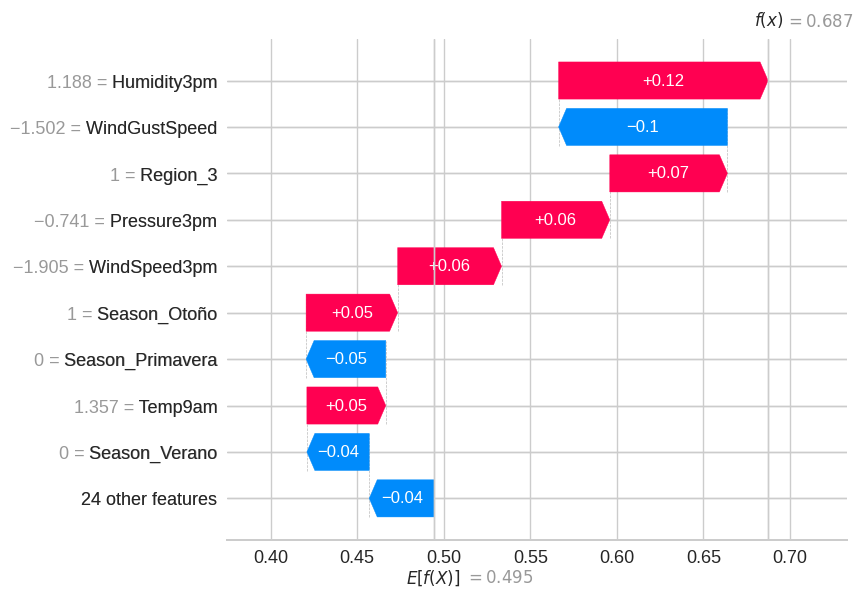

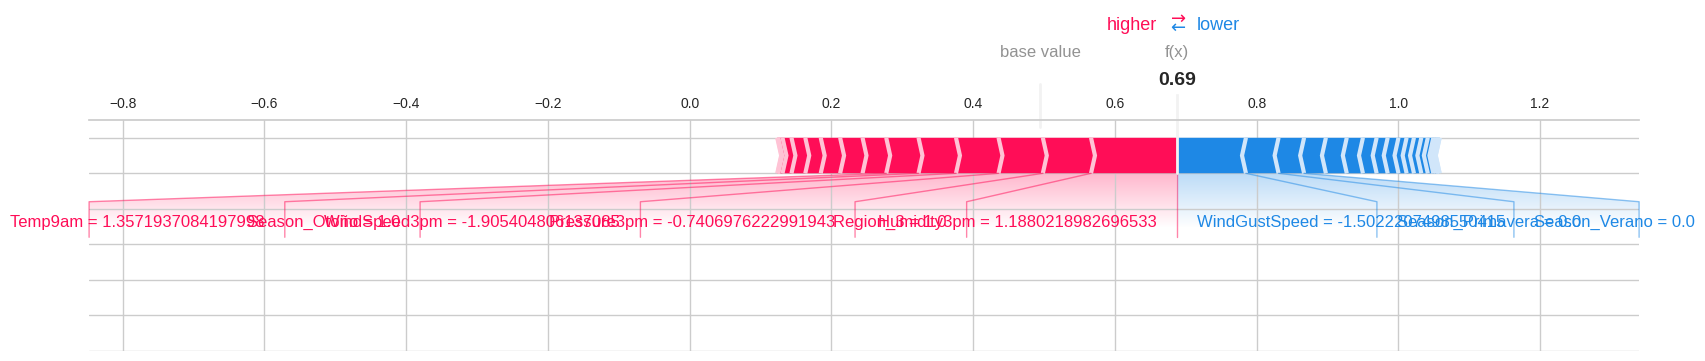

In [149]:
# Waterfall plot - Primera muestra
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0, :, 0],
        base_values=base_val,
        data=x_test_array[0],
        feature_names=x_test_exp.columns.tolist()
    )
)

# Force plot - Primera muestra
shap.plots.force(
    base_val,
    shap_values[0, :, 0],
    x_test_array[0],
    feature_names=x_test_exp.columns.tolist(),
    matplotlib=True
)


Las gráficas indican que las variables que más aumentan la probabilidad de lluvia son la humedad a las 3 pm, la velocidad del viento a las 3 pm, la presión atmosférica y la estación de otoño, todas con un impacto positivo claro sobre la predicción. Por el contrario, las ráfagas de viento fuertes, junto con ciertas estaciones como primavera y verano, reducen la probabilidad de lluvia. En conjunto, los factores de mayor peso empujan la predicción final hacia un valor alto, lo que sugiere condiciones favorables para la lluvia en este caso específico.

### Explicabilidad global

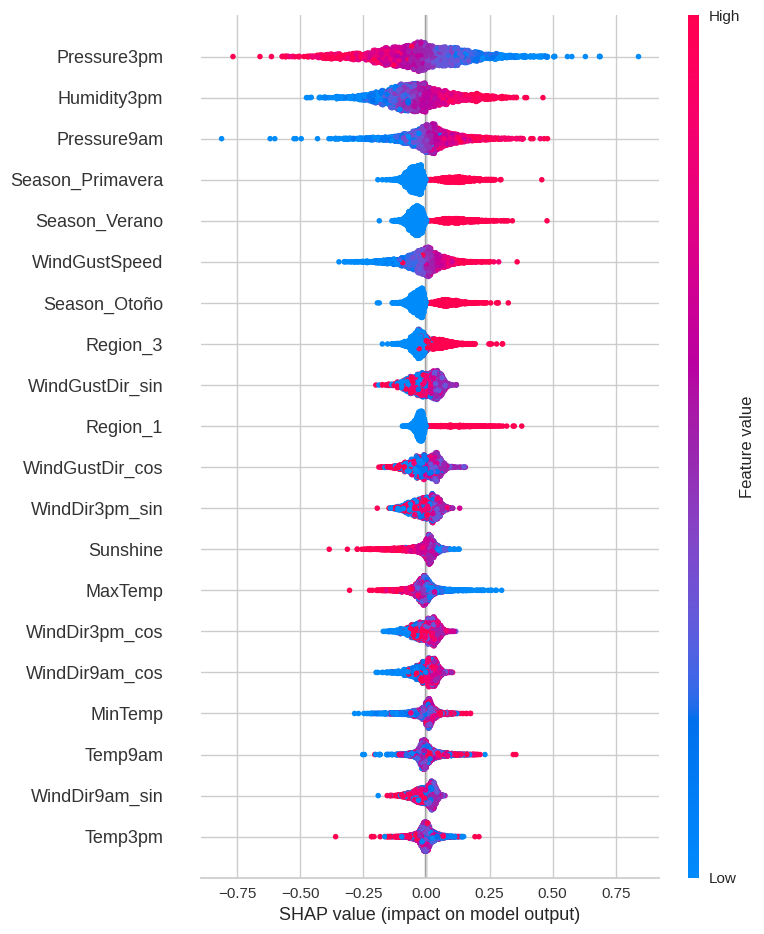

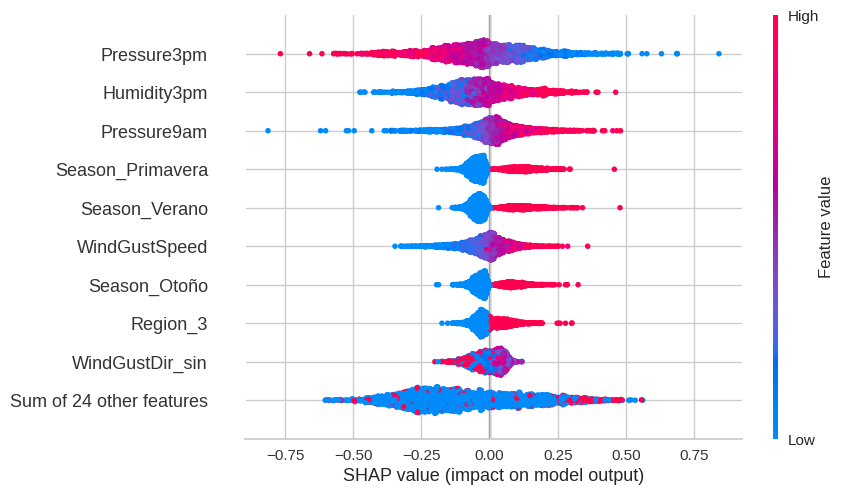

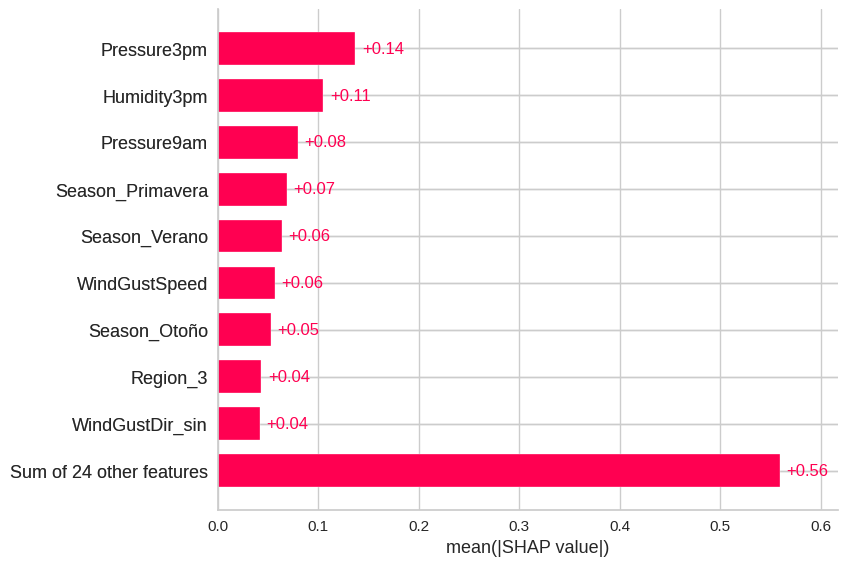

In [148]:
shap.summary_plot(
    shap_values[:, :, 0],
    x_test_array,
    feature_names=x_test_exp.columns.tolist()
)

# Beeswarm plot - Versión moderna del summary plot
shap.plots.beeswarm(
    shap.Explanation(
        values=shap_values[:, :, 0],
        base_values=np.full(shap_values.shape[0], base_val),
        data=x_test_array,
        feature_names=x_test_exp.columns.tolist()
    )
)

# Bar plot - Importancia promedio absoluta
shap.plots.bar(
    shap.Explanation(
        values=shap_values[:, :, 0],
        base_values=np.full(shap_values.shape[0], base_val),
        data=x_test_array,
        feature_names=x_test_exp.columns.tolist()
    )
)

Las gráficas muestran que la presión atmosférica a las 3 pm, la humedad a las 3 pm y la presión a las 9 am son los factores que más influyen en la predicción de lluvia. Valores altos de presión y humedad tienden a aumentar la probabilidad de lluvia en el modelo. También se observan efectos relevantes asociados a las estaciones: primavera y verano suelen reducir la probabilidad, mientras que otoño la incrementa ligeramente. Además, variables relacionadas con el viento (como la velocidad de las ráfagas y la dirección del viento) aportan información útil pero con un efecto moderado.

# 9. Comparacióm completa de modelos y sus resultados

Este notebook exploró múltiples enfoques para clasificación binaria con datos desbalanceados:

---

## RANKING DE MODELOS POR F1-SCORE (Test Set)

| Ranking | Modelo | F1-Score | Accuracy | Precision | Recall | AUC | Dataset |
|---------|--------|----------|----------|-----------|--------|-----|---------|
| 1 | **LightGBM (PyCaret)** | **0.8484** | 0.8572 | 0.8493 | 0.8572 | 0.8877 | SMOTE-Tomek |
| 2 | Random Forest (PyCaret) | 0.8443 | 0.8559 | 0.8484 | 0.8559 | 0.8851 | SMOTE-Tomek |
| 3 | Extra Trees (PyCaret) | 0.8402 | 0.8533 | 0.8457 | 0.8533 | 0.8841 | SMOTE-Tomek |
| 4 | Gradient Boosting (PyCaret) | 0.8380 | 0.8490 | 0.8398 | 0.8490 | 0.8739 | SMOTE-Tomek |
| 5 | Ada Boost (PyCaret) | 0.8319 | 0.8429 | 0.8325 | 0.8429 | 0.8632 | SMOTE-Tomek |
| 6 | Ridge Classifier (PyCaret) | 0.8257 | 0.8414 | 0.8314 | 0.8414 | 0.8645 | SMOTE-Tomek |
| 7 | SVM Linear (PyCaret) | 0.8270 | 0.8379 | 0.8273 | 0.8379 | 0.8543 | SMOTE-Tomek |
| 8 | Dummy (PyCaret) | 0.6780 | 0.7759 | 0.6021 | 0.7759 | 0.5000 | SMOTE-Tomek |
| 9 | Neural Network (Optuna+DR corregido) | 0.6392 | - | - | - | - | SMOTE-Tomek |
| 10 | Neural Network (Optuna) | 0.6353 | - | - | - | - | SMOTE-Tomek |
| 11 | Neural Network (Vanilla) | 0.6446 | 0.8154 | 0.5622 | 0.7552 | 0.8839 | SMOTE-Tomek |
| 12 | Logistic Regression (Threshold Opt) | 0.6182 | 0.8088 | 0.5545 | 0.6984 | 0.8600 | Original |
| 13 | Logistic Regression (SMOTE-Tomek) | 0.6140 | 0.7908 | 0.5195 | 0.7504 | - | SMOTE-Tomek |
| 14 | Logistic Regression (Optuna) | 0.6136 | - | - | - | - | SMOTE-Tomek |
| 15 | Logistic Regression (SMOTE-ENN) | 0.5900 | - | - | - | - | SMOTE-ENN |
| 16 | Logistic Regression (Default) | 0.5800 | - | - | - | - | Original |
| 17 | Dummy Classifier (Baseline) | 0.3000 | 0.4900 | 0.2200 | 0.4900 | 0.4900 | Original |

---

**Dummy Classifier (Baseline):**
- F1-Score: 0.30 (original) / 0.68 (SMOTE-Tomek)
- **Conclusión**: SMOTE-Tomek mejoró incluso el baseline en +127%

**Mejor Modelo (LightGBM):**
- F1-Score: 0.85
- **Mejora sobre baseline**: +183% (original) / +25% (SMOTE baseline)

---

### Impacto del Balanceo de Datos

| Técnica | Mejor F1 | Modelo |
|---------|----------|--------|
| Sin balanceo | 0.6182 | Logistic Regression + Threshold Opt |
| SMOTE-ENN | 0.5900 | Logistic Regression |
| SMOTE-Tomek | **0.8484** | LightGBM (PyCaret) |

**Conclusión**: SMOTE-Tomek fue la técnica más efectiva para este dataset

---

### Logistic Regression - Comparación de Técnicas de Optimización

| Técnica | F1-Score (Test) | Tiempo | Hiperparámetros Explorados |
|---------|-----------------|--------|---------------------------|
| Default (umbral 0.5) | 0.5800 | Rápido | N/A |
| Threshold Optimization | **0.6182** | Rápido | 1 (threshold) |
| Grid Search | 0.6141 | Medio | Grid fijo |
| Random Search | 0.6141 | Medio | Random sampling |
| Optuna | 0.6136 | Medio-Largo | Bayesian optimization |

**Conclusión**:
- La optimización de umbral es la más eficiente (mejor F1 con mínimo costo)
- Grid/Random/Optuna tienen rendimiento similar para este modelo simple
- Optuna es más flexible para espacios de búsqueda complejos

---

### Redes neuronales

| Configuración | Val F1 | Test F1 | Características |
|---------------|--------|---------|-----------------|
| Vanilla (Early Stopping) | 0.8446 | 0.6446 | Threshold: 0.44, Epochs: ~20 |
| Optuna Optimized | **0.8546** | **0.6353** | 5 layers, dropout 0.28, LR 0.0037 |
| Optuna + DR corregido | **---** | **0.6392** | 5 layers, dropout 0.6, LR 0.0037 |

**Mejores Hiperparámetros:**
```
- Layers: 3
- Neurons Layer 1: 96
- Neurons Layer 2: 56
- Dropout: 0.6
- Learning Rate: 0.00375
- Batch Size: 256
- L2 Regularization: 4.19e-06
```

**Conclusión**: Las redes neuronales no superaron a LightGBM en este problema, sin embargo, este método está realizado con árboles y escapa de los temas desarrollados en esta materia. Por eso, el Pipeline lo realizaremos con la mejor red neuronal obtenida.


# 10. Pipeline

In [ ]:
class RegionManagementTransformer(BaseEstimator, TransformerMixin):
    """
    Mergea información de la región desde el dictionario creado a partir de la clusterización
    """

    def __init__(self, region_mapping):
        self.region_mapping = region_mapping.copy()

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X = X.merge(self.region_mapping, on='Location', how='left')

        if 'Location' in X.columns:
            X = X.drop(columns=['Location'])

        return X


class DateManagementTransformer(BaseEstimator, TransformerMixin):
    """
    Convierte la columna Date a datetime y crea la columna Season
    """

    def __init__(self, date_column='Date'):
        self.date_column = date_column

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if self.date_column in X.columns:
            X[self.date_column] = pd.to_datetime(X[self.date_column])

            X['Month'] = X[self.date_column].dt.month

            def get_season(month):
                if month in [12, 1, 2]:
                    return 'Verano'
                elif month in [3, 4, 5]:
                    return 'Otoño'
                elif month in [6, 7, 8]:
                    return 'Invierno'
                else:
                    return 'Primavera'

            X['Season'] = X['Month'].apply(get_season)

            X = X.drop(columns=['Month', self.date_column])

        return X


class NullManagementTransformer(BaseEstimator, TransformerMixin):
    """
    Remueve filas donde tengo columnas nulas mayores al threshold (seteado en 50%)
    """

    def __init__(self, null_threshold=0.5):
        self.null_threshold = null_threshold

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        threshold = X.shape[1] - int(X.shape[1] * self.null_threshold)

        X = X.dropna(thresh=threshold)
        return X


class GroupedImputerTransformer(BaseEstimator, TransformerMixin):
    """
    Imputa valores faltantes usando estadísticos calculados previamente
    """

    def __init__(self, mean_stats=None, median_stats=None, knn_imputers=None, mode_stats=None):
        self.mean_stats = mean_stats or {}
        self.median_stats = median_stats or {}
        self.knn_imputers = knn_imputers or {}
        self.mode_stats = mode_stats or {}

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        X['_group_key'] = list(zip(X['Region'], X['Season']))

        for col, stats_dict in self.mean_stats.items():
            if col in X.columns:
                missing_mask = X[col].isna()
                if missing_mask.any():
                    X.loc[missing_mask, col] = X.loc[missing_mask, '_group_key'].map(stats_dict)

        for col, stats_dict in self.median_stats.items():
            if col in X.columns:
                missing_mask = X[col].isna()
                if missing_mask.any():
                    X.loc[missing_mask, col] = X.loc[missing_mask, '_group_key'].map(stats_dict)

        for col, imputers_dict in self.knn_imputers.items():
            if col in X.columns:
                for (region, season), imputer in imputers_dict.items():
                    group_mask = (X['Region'] == region) & (X['Season'] == season) & X[col].isna()

                    if group_mask.any():
                        group_data = X.loc[group_mask, [col]]
                        imputed_values = imputer.transform(group_data)
                        X.loc[group_mask, col] = imputed_values.ravel()

        for col, stats_dict in self.mode_stats.items():
            if col in X.columns:
                missing_mask = X[col].isna()
                if missing_mask.any():
                    X.loc[missing_mask, col] = X.loc[missing_mask, '_group_key'].map(stats_dict)

        X = X.drop(columns=['_group_key'])

        return X


class EncodingTransformer(BaseEstimator, TransformerMixin):
    """
    Transforma variables categóricas según el caso
    """

    def __init__(self, wind_encoding=None, expected_columns=None):
        self.wind_cols = ['WindGustDir', 'WindDir9am', 'WindDir3pm']
        self.dummy_cols = ['Region', 'Season', 'RainToday']

        if wind_encoding is None:
            directions = ['N', 'NNE', 'NE', 'ENE', 'E', 'ESE', 'SE', 'SSE',
                            'S', 'SSW', 'SW', 'WSW', 'W', 'WNW', 'NW', 'NNW']
            self.wind_encoding = {d: i * 22.5 for i, d in enumerate(directions)}
        else:
            self.wind_encoding = wind_encoding

        self.expected_columns = expected_columns

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        """Aplica codificación"""
        X = X.copy()

        if 'RainTomorrow' in X.columns:
            X = X.drop(columns=['RainTomorrow'])

        for col in self.wind_cols:
            if col in X.columns:
                angles = X[col].map(self.wind_encoding)
                angles_rad = np.radians(angles)

                X[f'{col}_sin'] = np.sin(angles_rad)
                X[f'{col}_cos'] = np.cos(angles_rad)

                X = X.drop(columns=[col])

        X = pd.get_dummies(X, columns=self.dummy_cols, drop_first=True)

        """
        Agrega las columnas que el modelo espera
        (esto es para que sea coherente con la función de dummies)
        """
        if self.expected_columns is not None:
            for col in self.expected_columns:
                if col not in X.columns:
                    X[col] = 0

            X = X[self.expected_columns]

        return X


class NumericalScalerTransformer(BaseEstimator, TransformerMixin):
    """
    Escala columnas numéricas utilizando un StandardScaler pre-ajustado.
    """

    def __init__(self, scaler, cols_to_scale):
        self.scaler = scaler
        self.cols_to_scale = cols_to_scale

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()

        if self.cols_to_scale:
            existing_cols = [col for col in self.cols_to_scale if col in X.columns]
            if existing_cols:
                X[existing_cols] = self.scaler.transform(X[existing_cols])

        return X

class KerasClassifierWrapper(BaseEstimator):
    """
    Wrapper para modelos de Keras que los hace compatibles con sklearn Pipeline.
    Agrega los métodos predict_proba y predict que sklearn espera.

    Parameters
    ----------
    model : keras.Sequential
        Modelo de Keras ya entrenado
    """

    def __init__(self, model):
        self.model = model

    def fit(self, X, y=None):
        return self

    def predict(self, X):
        """
        Devuelve predicciones de clase (0 o 1).
        """
        y_pred_prob = self.model.predict(X, verbose=0)
        return (y_pred_prob > 0.5).astype(int).ravel()

    def predict_proba(self, X):
        """
        Devuelve probabilidades para ambas clases.
        Sklearn espera una matriz de forma (n_samples, n_classes).
        """
        y_pred_prob = self.model.predict(X, verbose=0).ravel()
        # Retornar [prob_clase_0, prob_clase_1] para cada muestra
        return np.column_stack([1 - y_pred_prob, y_pred_prob])

In [ ]:
# Crear pipeline de preprocessing con componentes ya entrenados del notebook

region_mapping = df_coords_by_k[8][['Location', 'Region']]
keras_wrapper = KerasClassifierWrapper(model_to_test)

expected_features = x_train.columns.tolist()

pipe = Pipeline(steps=[
    ('region_management', RegionManagementTransformer(region_mapping=region_mapping)),
    ('date_management', DateManagementTransformer()),
    ('null_management', NullManagementTransformer()),
    ('imputation', GroupedImputerTransformer(
        mean_stats=medias_dict,
        median_stats=medianas_dict,
        knn_imputers=knn_imputers,
        mode_stats=modas_dict,
    )),
    ('encoding', EncodingTransformer(expected_columns=expected_features)),
    ('scaling', NumericalScalerTransformer(scaler=scaler, cols_to_scale=cols_a_estandarizar)),
    ('model', keras_wrapper)
])



[0 0 0 0 0 0 0 0 0]


In [ ]:
df_new = pd.read_csv('test_pipe.csv')
df_new.drop(columns=['RainTomorrow'], inplace=True)
joblib.dump(pipe, 'complete_pipeline.pkl')
y_pred = pipe.predict(df_new)
y_pred_proba = pipe.predict_proba(df_new)
print(y_pred)
print(y_pred_proba)

for i in y_pred:
    if i==0:
        print("Andate al río")
    else: print("Lleva paraguas si salís")

[0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
[[9.98920560e-01 1.07944792e-03]
 [9.99868155e-01 1.31864697e-04]
 [9.99994874e-01 5.14580233e-06]
 [9.99596179e-01 4.03832266e-04]
 [9.82934952e-01 1.70650464e-02]
 [9.97469723e-01 2.53027258e-03]
 [9.99998748e-01 1.22404788e-06]
 [9.99988198e-01 1.18049584e-05]
 [6.89041018e-01 3.10958952e-01]
 [9.99834478e-01 1.65505800e-04]
 [9.97782052e-01 2.21796869e-03]
 [8.53893161e-02 9.14610684e-01]
 [5.54453731e-02 9.44554627e-01]
 [8.13841581e-01 1.86158419e-01]
 [9.98890042e-01 1.10996875e-03]
 [9.99611437e-01 3.88538436e-04]
 [8.98015261e-01 1.01984724e-01]
 [5.80089092e-01 4.19910938e-01]
 [9.99972045e-01 2.79823216e-05]
 [9.99983311e-01 1.66852460e-05]
 [9.99995291e-01 4.73488808e-06]
 [8.45940948e-01 1.54059038e-01]
 [9.99922812e-01 7.71689956e-05]
 [9.94277298e-01 5.72271040e-03]
 [9.99989510e-01 1.04694354e-05]
 [9.99997616e-01 2.36637425e-06]
 [9.99857366e-01 1.42647128e-04]
 [9.99958396e-01 4.15988470e-05]
 [9.

# 11. Conclusión

A lo largo del trabajo se evaluaron diversos enfoques para resolver el problema de clasificación binaria, con un marcado desbalance en el conjunto de datos. Los resultados muestran de manera consistente que la técnica de balanceo SMOTE-Tomek fue la más efectiva, permitiendo mejorar significativamente el desempeño de casi todos los modelos. Esto se evidencia incluso en el modelo base: el Dummy Classifier pasó de un F1-Score de 0.30 (dataset original) a 0.68 con SMOTE-Tomek.

En cuanto a la regresión logística, se compararon distintas estrategias de optimización de hiperparámetros. Se observó que la optimización de umbral fue la técnica más eficiente, alcanzando el mejor F1-Score para este modelo con un costo computacional mínimo. Métodos como Grid Search, Random Search u Optuna no ofrecieron mejoras significativas en el desempeño, aunque Optuna mostró mayor flexibilidad para búsquedas complejas.

El mejor rendimiento se obtuvo con LightGBM. Estos modelos basados en árboles demostraron ser especialmente robustos para capturar relaciones no lineales del dataset, superando ampliamente a alternativas lineales y a las redes neuronales evaluadas.

Respecto a las redes neuronales, tanto la versión básica con early stopping como el modelo optimizado con Optuna lograron buenos resultados en validación, pero no lograron sostener ese desempeño en el set de test ($F1 \approx 0.63–0.64$). A pesar de las mejoras introducidas mediante capas adicionales, dropout y ajuste de tasa de aprendizaje, las redes no superaron a los modelos basados en árboles en este problema. Sin embargo, dado que estos algoritmos quedan fuera del alcance de la materia, se selecciona la mejor red neuronal optimizada como modelo final para el pipeline.

El tiempo empleado en la pipeline con el modelo ya entrenado es casi despreciable. Demostrando la utilidad de esta herramienta.